# Employee Analytics — Sharing Vision Coding Test

**Kandidat:** Nurimam Masri | **Dataset:** `employee.csv` — IBM HR Analytics (2.940 karyawan × 35 fitur)

---

## Problem Statement

### Latar Belakang

Perusahaan menghadapi **tantangan serius dalam manajemen sumber daya manusia (SDM)**: tingkat *employee attrition* (turnover karyawan) yang tinggi berdampak langsung pada biaya rekrutmen, produktivitas tim, dan knowledge retention. Selain itu, ketidakkonsistenan dalam penetapan kompensasi menyulitkan perencanaan anggaran HR secara akurat.

Dataset `employee.csv` berisi rekam jejak **2.940 karyawan** — mencakup profil demografis, kondisi kerja, kepuasan, performa, dan status attrition — yang akan digunakan sebagai landasan analisis berbasis data.

---

### Business Questions

| # | Pertanyaan Bisnis | Pendekatan |
|---|------------------|------------|
| 1 | Faktor apa saja yang paling berpengaruh terhadap keputusan karyawan untuk **meninggalkan perusahaan**? | EDA + Statistical Testing + Feature Importance |
| 2 | Dapatkah kita **memprediksi** karyawan mana yang berisiko keluar sebelum hal tersebut terjadi? | Classification (Attrition = target) |
| 3 | Bagaimana cara menentukan **MonthlyIncome yang adil** berdasarkan profil karyawan? | Regression (MonthlyIncome = target) |
| 4 | Apakah terdapat **segmen karyawan** yang memiliki karakteristik serupa dan memerlukan pendekatan retensi yang berbeda? | Clustering (K-Means) |

---

### Analytical Objectives

```
1. EDA (Task 1–6)
   ├── Univariat numerik: distribusi, outlier, statistik dasar
   ├── Univariat kategorik: frekuensi, proporsi
   ├── Multivariat numerik vs Attrition: pola perbedaan
   ├── Multivariat kategorik vs Attrition: faktor risiko
   ├── T-Test: TotalWorkingYears vs Attrition (signifikansi statistik)
   └── ANOVA: Age vs Department (perbedaan antar grup)

2. Classification (Task 8–13)
   ├── Target: Attrition (imbalanced: 83.9% No / 16.1% Yes)
   ├── Model: Logistic Regression, Decision Tree, XGBoost
   ├── Evaluasi: F1-Macro + ROC AUC (threshold-independent)
   └── Feature Importance + SHAP values

3. Regression (Task 14–18)
   ├── Target: MonthlyIncome (continuous)
   ├── Model: LinearRegression, Ridge, Lasso, DecisionTree, RandomForest, XGBoost
   ├── Evaluasi: R², RMSE, MAE, MAPE
   └── Feature Importance + SHAP values

4. Clustering (Task 19–22)
   ├── Preprocessing: StandardScaler + OneHotEncoder + PCA
   ├── Algoritma: K-Means
   ├── K-Optimal: Elbow Method + Silhouette Score
   └── Profiling & Naming per cluster
```

---

### Dataset Overview

| Info | Nilai |
|------|-------|
| Jumlah Observasi | 2.940 baris |
| Fitur Raw | 35 kolom |
| Fitur Aktif (setelah preprocessing) | 31 kolom |
| Target Klasifikasi | `Attrition` (Binary: Yes/No) |
| Target Regresi | `MonthlyIncome` (Continuous) |
| Imbalance Ratio | 83.9% No / 16.1% Yes |
| Missing Values | 0 |
| Duplikasi | 0 |

---

### Methodology

```
Data Loading → EDA (Univariate + Multivariate) → Statistical Testing
     ↓
Feature Engineering (Encoding + Scaling + PCA)
     ↓
Classification  ──→  XGBoost Best Model  ──→  SHAP Explanation
     ↓
Regression      ──→  XGBoost Best Model  ──→  SHAP Explanation
     ↓
Clustering      ──→  K-Means k=2         ──→  Cluster Profiling
     ↓
Kesimpulan & Rekomendasi Bisnis
```

---

*Notebook ini mengikuti penomoran task (1)–(22) sesuai soal asli. Jalankan sel dari atas ke bawah secara berurutan.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, r2_score,
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df_raw = pd.read_csv('employee.csv')
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (2940, 35)


,Unnamed: 0,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,...,1,80,0,8,0,1,6,4,0,5
1,1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,...,4,80,1,10,3,3,10,7,1,7
2,2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,...,2,80,0,7,3,3,0,0,0,0
3,3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,...,3,80,0,8,3,3,8,7,3,0
4,4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,...,4,80,1,6,3,3,2,2,2,2


## Data Profiling — Ringkasan Komprehensif Dataset

Analisis cepat seluruh fitur dataset sebelum EDA mendalam: distribusi, missing values, kardinalitas, dan korelasi.

  DATA PROFILING REPORT — employee.csv (setelah drop 4 kolom)
  Baris         : 2,940  |  Kolom: 31
  Numerik       : 23  |  Kategorik: 8
  Missing Values: 0  |  Duplikat: 1470

──────────────────────────────────────────────────────────────────────
  [1] PROFIL FITUR NUMERIK
──────────────────────────────────────────────────────────────────────


,Mean,Std,Min,Max,Unique,Outlier,Skewness,Distribusi
Kolom,,,,,,,,
Age,36.92,9.13,18,60,43,0,0.41,Normal
DailyRate,802.49,403.44,102,1499,886,0,-0.00,Normal
DistanceFromHome,9.19,8.11,1,29,29,0,0.96,Right-skewed
Education,2.91,1.02,1,5,5,0,-0.29,Normal
EnvironmentSatisfaction,2.72,1.09,1,4,4,0,-0.32,Normal
HourlyRate,65.89,20.33,30,100,71,0,-0.03,Normal
JobInvolvement,2.73,0.71,1,4,4,0,-0.50,Normal
JobLevel,2.06,1.11,1,5,5,0,1.02,Right-skewed
JobSatisfaction,2.73,1.10,1,4,4,0,-0.33,Normal



──────────────────────────────────────────────────────────────────────
  [2] PROFIL FITUR KATEGORIK
──────────────────────────────────────────────────────────────────────


,Unique,Top Value,Top Freq (%),Missing (%)
Kolom,,,,
Attrition,2,No,83.900000,0.000000
BusinessTravel,3,Travel_Rarely,71.000000,0.000000
Department,3,Research & Development,65.400000,0.000000
EducationField,6,Life Sciences,41.200000,0.000000
Gender,2,Male,60.000000,0.000000
JobRole,9,Sales Executive,22.200000,0.000000
MaritalStatus,3,Married,45.800000,0.000000
OverTime,2,No,71.700000,0.000000



──────────────────────────────────────────────────────────────────────
  [3] TOP KORELASI ANTAR FITUR NUMERIK (|r| > 0.4)
──────────────────────────────────────────────────────────────────────


,Fitur A,Fitur B,Korelasi
134,JobLevel,MonthlyIncome,0.9503
141,JobLevel,TotalWorkingYears,0.7822
198,PercentSalaryHike,PerformanceRating,0.7735
168,MonthlyIncome,TotalWorkingYears,0.7729
249,YearsAtCompany,YearsWithCurrManager,0.7692
247,YearsAtCompany,YearsInCurrentRole,0.7588
251,YearsInCurrentRole,YearsWithCurrManager,0.7144
15,Age,TotalWorkingYears,0.6804
234,TotalWorkingYears,YearsAtCompany,0.6281
248,YearsAtCompany,YearsSinceLastPromotion,0.6184



──────────────────────────────────────────────────────────────────────
  [4] DISTRIBUSI TARGET: Attrition
──────────────────────────────────────────────────────────────────────


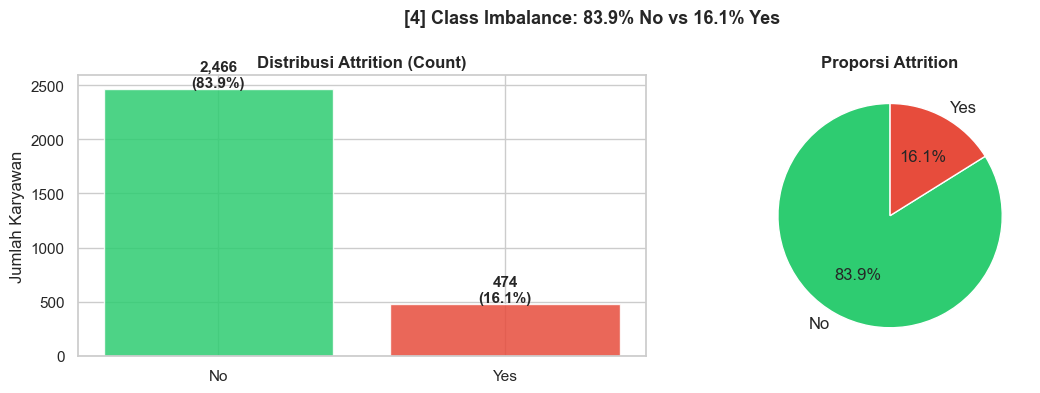


  >> IMBALANCE RATIO: 5.2:1 (No:Yes)
  >> Strategi: class_weight='balanced' + evaluasi ROC AUC + F1-Macro


In [2]:
# ── Data Profiling — Manual Equivalent of ydata-profiling ──────────────────
import warnings
warnings.filterwarnings('ignore')

_df = df_raw.drop(columns=[c for c in ['Unnamed: 0','EmployeeNumber','Over18','StandardHours'] if c in df_raw.columns])
_num = _df.select_dtypes(include=np.number).columns.tolist()
_cat = _df.select_dtypes(exclude=np.number).columns.tolist()

print("=" * 70)
print("  DATA PROFILING REPORT — employee.csv (setelah drop 4 kolom)")
print("=" * 70)
print(f"  Baris         : {_df.shape[0]:,}  |  Kolom: {_df.shape[1]}")
print(f"  Numerik       : {len(_num)}  |  Kategorik: {len(_cat)}")
print(f"  Missing Values: {_df.isnull().sum().sum()}  |  Duplikat: {_df.duplicated().sum()}")
print()

# ── 1. Profil numerik ────────────────────────────────────────────────────────
print("─" * 70)
print("  [1] PROFIL FITUR NUMERIK")
print("─" * 70)
prof_num = []
for col in _num:
    s = _df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
    skew = float(s.skew())
    prof_num.append({
        'Kolom': col, 'Mean': round(s.mean(),2), 'Std': round(s.std(),2),
        'Min': s.min(), 'Max': s.max(), 'Unique': s.nunique(),
        'Outlier': n_out, 'Skewness': round(skew,2),
        'Distribusi': 'Right-skewed' if skew>0.5 else ('Left-skewed' if skew<-0.5 else 'Normal')
    })
df_prof_num = pd.DataFrame(prof_num).set_index('Kolom')
display(df_prof_num.style
    .background_gradient(cmap='Blues', subset=['Mean','Std'])
    .background_gradient(cmap='Reds', subset=['Outlier'])
    .background_gradient(cmap='Greens', subset=['Unique'])
    .format({'Mean':'{:.2f}','Std':'{:.2f}','Skewness':'{:.2f}'})
    .set_caption("Tabel Profiling — Fitur Numerik"))

# ── 2. Profil kategorik ──────────────────────────────────────────────────────
print("\n" + "─" * 70)
print("  [2] PROFIL FITUR KATEGORIK")
print("─" * 70)
prof_cat = []
for col in _cat:
    s = _df[col]
    vc = s.value_counts()
    prof_cat.append({
        'Kolom': col, 'Unique': s.nunique(),
        'Top Value': vc.index[0], 'Top Freq (%)': round(vc.iloc[0]/len(s)*100,1),
        'Missing (%)': round(s.isnull().mean()*100,1)
    })
df_prof_cat = pd.DataFrame(prof_cat).set_index('Kolom')
display(df_prof_cat.style
    .background_gradient(cmap='Purples', subset=['Unique'])
    .background_gradient(cmap='Oranges', subset=['Top Freq (%)'])
    .set_caption("Tabel Profiling — Fitur Kategorik"))

# ── 3. Correlation heatmap (top correlations) ────────────────────────────────
print("\n" + "─" * 70)
print("  [3] TOP KORELASI ANTAR FITUR NUMERIK (|r| > 0.4)")
print("─" * 70)
corr_matrix = _df[_num].corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = upper.stack().reset_index()
high_corr.columns = ['Fitur A', 'Fitur B', 'Korelasi']
high_corr = high_corr[high_corr['Korelasi'].abs() > 0.4].sort_values('Korelasi', ascending=False)
if len(high_corr) > 0:
    display(high_corr.style
        .background_gradient(cmap='RdYlGn', subset=['Korelasi'])
        .format({'Korelasi': '{:.4f}'})
        .set_caption("Pasangan Fitur dengan Korelasi Tinggi (|r| > 0.4)"))
else:
    print("  Tidak ada pasangan fitur dengan |r| > 0.4")

# ── 4. Class balance (target) ────────────────────────────────────────────────
print("\n" + "─" * 70)
print("  [4] DISTRIBUSI TARGET: Attrition")
print("─" * 70)
attrition_dist = _df['Attrition'].value_counts()
attrition_pct  = _df['Attrition'].value_counts(normalize=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(attrition_dist.index, attrition_dist.values, color=colors, alpha=0.85, edgecolor='white')
for i, (val, pct) in enumerate(zip(attrition_dist.values, attrition_pct.values)):
    axes[0].text(i, val + 20, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Attrition (Count)', fontweight='bold')
axes[0].set_ylabel('Jumlah Karyawan')
axes[1].pie(attrition_dist.values, labels=attrition_dist.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[1].set_title('Proporsi Attrition', fontweight='bold')
plt.suptitle('[4] Class Imbalance: 83.9% No vs 16.1% Yes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\n  >> IMBALANCE RATIO: {attrition_dist['No']/attrition_dist['Yes']:.1f}:1 (No:Yes)")
print(f"  >> Strategi: class_weight='balanced' + evaluasi ROC AUC + F1-Macro")

## Data Understanding

Dataset yang digunakan adalah **employee.csv** — data HR karyawan dari suatu perusahaan yang mencakup informasi demografis, pekerjaan, kompensasi, kinerja, kepuasan kerja, dan status attrition.

### Tujuan Analisis

| Task | Target | Keterangan |
|------|--------|------------|
| **Klasifikasi** | `Attrition` | Memprediksi apakah karyawan akan **keluar** (Yes=1) atau **menetap** (No=0) |
| **Regresi** | `MonthlyIncome` | Memprediksi **pendapatan bulanan** karyawan berdasarkan profil mereka |
| **Clustering** | Semua Fitur | **Segmentasi** karyawan ke dalam kelompok homogen untuk targeted strategy |

---

### Tambahan — unit observasi & lapisan data

- **Unit observasi:** satu baris = **satu karyawan** (record HR per individu).
- **Lapisan *raw*:** `df_raw` dari file CSV (termasuk kolom ID / konstan).
- **Lapisan analisis:** setelah drop kolom non-informatif → `df_work` / `df` di bagian EDA (sama seperti alur Task 1).


In [3]:
# ── Dataset Overview ─────────────────────────────────────────────────────────
print("=" * 65)
print("  DATASET OVERVIEW — employee.csv")
print("=" * 65)
print(f"  Jumlah Baris          : {df_raw.shape[0]:,}")
print(f"  Jumlah Kolom (raw)    : {df_raw.shape[1]}")
print(f"  Kolom setelah drop    : {df_raw.shape[1] - 4}  (drop 4 kolom non-informatif)")
print()

# Tipe data
num_raw = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_raw = df_raw.select_dtypes(exclude=np.number).columns.tolist()
print(f"  Tipe Data Numerik     : {len(num_raw)} kolom")
print(f"  Tipe Data Kategorik   : {len(cat_raw)} kolom")
print()

# Missing values
missing = df_raw.isnull().sum()
print(f"  Total Missing Values  : {missing.sum()}")
print(f"  >> {'Tidak ada missing value' if missing.sum()==0 else 'Terdapat missing value!'}")

# Duplicates
dupes = df_raw.duplicated().sum()
print(f"\n  Total Baris Duplikat  : {dupes}")
print(f"  >> {'Tidak ada duplikat' if dupes==0 else 'Terdapat duplikat!'}")

print()
print("─" * 65)
print("KOLOM YANG AKAN DI-DROP (tidak informatif untuk analisis):")
print("─" * 65)
drop_info = {
    'Unnamed: 0'    : 'Index kolom otomatis dari file CSV',
    'EmployeeNumber': 'ID unik karyawan — tidak relevan untuk prediksi',
    'Over18'        : 'Semua karyawan berusia >18 tahun (nilai tunggal)',
    'StandardHours' : 'Semua karyawan memiliki nilai 80 (konstan)',
}
for col, reason in drop_info.items():
    if col in df_raw.columns:
        val = df_raw[col].unique()
        print(f"  {col:20s}: {reason}")
        print(f"  {'':20s}  Nilai unik: {val}")
        print()

print("─" * 65)
print("PREVIEW DATASET (3 baris pertama):")
print("─" * 65)
display(df_raw.head(3))

  DATASET OVERVIEW — employee.csv
  Jumlah Baris          : 2,940
  Jumlah Kolom (raw)    : 35
  Kolom setelah drop    : 31  (drop 4 kolom non-informatif)

  Tipe Data Numerik     : 26 kolom
  Tipe Data Kategorik   : 9 kolom

  Total Missing Values  : 0
  >> Tidak ada missing value

  Total Baris Duplikat  : 0
  >> Tidak ada duplikat

─────────────────────────────────────────────────────────────────
KOLOM YANG AKAN DI-DROP (tidak informatif untuk analisis):
─────────────────────────────────────────────────────────────────
  Unnamed: 0          : Index kolom otomatis dari file CSV
                        Nilai unik: [   0    1    2 ... 2937 2938 2939]

  EmployeeNumber      : ID unik karyawan — tidak relevan untuk prediksi
                        Nilai unik: [   1    2    3 ... 2938 2939 2940]

  Over18              : Semua karyawan berusia >18 tahun (nilai tunggal)
                        Nilai unik: ['Y']

  StandardHours       : Semua karyawan memiliki nilai 80 (konstan)
            

,Unnamed: 0,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,...,1,80,0,8,0,1,6,4,0,5
1,1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,...,4,80,1,10,3,3,10,7,1,7
2,2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,...,2,80,0,7,3,3,0,0,0,0


In [4]:
# ── Tambahan: ringkasan lapisan raw vs kerja (tanpa mengubah alur sebelumnya) ──
import io
drop_preview = ['Unnamed: 0', 'EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_work_layer = df_raw.drop(columns=[c for c in drop_preview if c in df_raw.columns])
print('--- df_raw (lapisan file) ---')
print(f'shape: {df_raw.shape}')
buf = io.StringIO()
df_raw.info(buf=buf, verbose=False)
print(buf.getvalue())
print('\n--- df_work_layer (setelah drop kolom non-informatif) ---')
print(f'shape: {df_work_layer.shape}')
buf2 = io.StringIO()
df_work_layer.info(buf=buf2, verbose=False)
print(buf2.getvalue())


--- df_raw (lapisan file) ---
shape: (2940, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Columns: 35 entries, Unnamed: 0 to YearsWithCurrManager
dtypes: int64(26), object(9)
memory usage: 804.0+ KB


--- df_work_layer (setelah drop kolom non-informatif) ---
shape: (2940, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Columns: 31 entries, Attrition to YearsWithCurrManager
dtypes: int64(23), object(8)
memory usage: 712.2+ KB



### Data Dictionary — Deskripsi Kolom (31 Fitur Aktif)

> Dataset memiliki **35 kolom asli**. Setelah drop 4 kolom non-informatif (`Unnamed: 0`, `EmployeeNumber`, `Over18`, `StandardHours`), tersisa **31 kolom** untuk analisis.

---

#### Kelompok 1: Demografi Karyawan

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `Age` | Numerik | Usia karyawan dalam tahun | 18 – 60 tahun |
| `Gender` | Kategorik | Jenis kelamin | Male / Female |
| `MaritalStatus` | Kategorik | Status pernikahan | Single / Married / Divorced |
| `Education` | Ordinal | Level pendidikan | 1=Below College, 2=College, 3=Bachelor, 4=Master, 5=Doctor |
| `EducationField` | Kategorik | Bidang studi/pendidikan | Life Sciences, Medical, Marketing, Technical Degree, Human Resources, Other |

---

#### Kelompok 2: Informasi Pekerjaan

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `Department` | Kategorik | Departemen kerja | Sales, Research & Development, Human Resources |
| `JobRole` | Kategorik | Posisi/jabatan | 9 role (Research Scientist, Sales Executive, Manager, dll.) |
| `JobLevel` | Ordinal | Level hierarki jabatan | 1=Junior → 5=Executive |
| `JobInvolvement` | Ordinal | Tingkat keterlibatan dalam pekerjaan | 1=Low, 2=Medium, 3=High, 4=Very High |
| `BusinessTravel` | Kategorik | Frekuensi perjalanan dinas | Non-Travel, Travel_Rarely, Travel_Frequently |
| `OverTime` | Kategorik | Status kerja lembur reguler | Yes / No |

---

#### Kelompok 3: Kompensasi & Benefit

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `MonthlyIncome` ⭐ | Numerik | **TARGET REGRESI** — Pendapatan bulanan (USD) | \$1,009 – \$19,999 |
| `DailyRate` | Numerik | Tarif harian karyawan (USD) | 102 – 1,499 |
| `HourlyRate` | Numerik | Tarif per jam (USD) | 30 – 100 |
| `MonthlyRate` | Numerik | Tarif bulanan kontrak (USD) | 2,094 – 26,999 |
| `PercentSalaryHike` | Numerik | Persentase kenaikan gaji terakhir (%) | 11% – 25% |
| `StockOptionLevel` | Ordinal | Level opsi saham yang dimiliki | 0=None, 1=Low, 2=Medium, 3=High |

---

#### Kelompok 4: Kinerja & Pengembangan

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `PerformanceRating` | Ordinal | Rating performa evaluasi terakhir | 1=Low, 2=Good, 3=Excellent, 4=Outstanding |
| `TrainingTimesLastYear` | Numerik | Jumlah kali mengikuti training tahun lalu | 0 – 6 kali |
| `NumCompaniesWorked` | Numerik | Jumlah perusahaan yang pernah dikerjakan | 0 – 9 perusahaan |

---

#### Kelompok 5: Kepuasan Kerja (Work Satisfaction)

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `JobSatisfaction` | Ordinal | Kepuasan terhadap pekerjaan | 1=Low, 2=Medium, 3=High, 4=Very High |
| `EnvironmentSatisfaction` | Ordinal | Kepuasan terhadap lingkungan kerja | 1=Low, 2=Medium, 3=High, 4=Very High |
| `RelationshipSatisfaction` | Ordinal | Kepuasan terhadap hubungan kerja | 1=Low, 2=Medium, 3=High, 4=Very High |
| `WorkLifeBalance` | Ordinal | Keseimbangan kerja dan kehidupan pribadi | 1=Bad, 2=Good, 3=Better, 4=Best |

---

#### Kelompok 6: Tenure & Riwayat Karier

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `TotalWorkingYears` | Numerik | Total tahun pengalaman kerja keseluruhan | 0 – 40 tahun |
| `YearsAtCompany` | Numerik | Lama bekerja di perusahaan saat ini | 0 – 40 tahun |
| `YearsInCurrentRole` | Numerik | Lama menjabat posisi saat ini | 0 – 18 tahun |
| `YearsSinceLastPromotion` | Numerik | Tahun yang berlalu sejak promosi terakhir | 0 – 15 tahun |
| `YearsWithCurrManager` | Numerik | Lama bekerja dengan manajer saat ini | 0 – 17 tahun |
| `DistanceFromHome` | Numerik | Jarak dari rumah ke kantor (km) | 1 – 29 km |

---

#### Kelompok 7: Target Analisis

| Kolom | Tipe | Deskripsi | Nilai |
|-------|------|-----------|-------|
| `Attrition` ⭐ | Kategorik | **TARGET KLASIFIKASI** — Status keluar karyawan | Yes=Keluar, No=Menetap |

---

> **Catatan:**
> - Kolom bertipe *Ordinal* memiliki urutan bermakna meskipun berformat numerik
> - `MonthlyIncome` berbeda dari `DailyRate`/`HourlyRate`/`MonthlyRate` — yang terakhir adalah tarif kontrak, bukan take-home pay aktual
> - Dataset sudah bersih: **0 missing values**, **0 duplicates**

In [5]:
# ── Statistik Deskriptif Numerik (setelah drop kolom tidak relevan) ─────────
drop_preview = ['Unnamed: 0', 'EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_work = df_raw.drop(columns=[c for c in drop_preview if c in df_raw.columns])
num_work = df_work.select_dtypes(include=np.number).columns.tolist()

print(f"Statistik Deskriptif — {len(num_work)} Fitur Numerik (N={len(df_work):,} rows)")
print("Gradient: semakin gelap = nilai semakin besar relatif antar baris\n")
display(
    df_work[num_work].describe().round(2).T
    .style.background_gradient(cmap='Blues', axis=1)
    .set_caption("Tabel 1: Descriptive Statistics — Numerical Features")
    .format("{:.2f}")
)

# ── Overview Kategorik ──────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("CATEGORICAL FEATURES — Distribusi Nilai")
print("=" * 65)
cat_work = df_work.select_dtypes(exclude=np.number).columns.tolist()
for col in cat_work:
    counts = df_work[col].value_counts()
    props  = (df_work[col].value_counts(normalize=True) * 100).round(1)
    df_cat_tbl = pd.DataFrame({'Count': counts, 'Pct (%)': props})
    print(f"\n[{col}] — {df_work[col].nunique()} kategori unik:")
    print(df_cat_tbl.to_string())

Statistik Deskriptif — 23 Fitur Numerik (N=2,940 rows)
Gradient: semakin gelap = nilai semakin besar relatif antar baris



,count,mean,std,min,25%,50%,75%,max
Age,2940.00,36.92,9.13,18.00,30.00,36.00,43.00,60.00
DailyRate,2940.00,802.49,403.44,102.00,465.00,802.00,1157.00,1499.00
DistanceFromHome,2940.00,9.19,8.11,1.00,2.00,7.00,14.00,29.00
Education,2940.00,2.91,1.02,1.00,2.00,3.00,4.00,5.00
EnvironmentSatisfaction,2940.00,2.72,1.09,1.00,2.00,3.00,4.00,4.00
HourlyRate,2940.00,65.89,20.33,30.00,48.00,66.00,84.00,100.00
JobInvolvement,2940.00,2.73,0.71,1.00,2.00,3.00,3.00,4.00
JobLevel,2940.00,2.06,1.11,1.00,1.00,2.00,3.00,5.00
JobSatisfaction,2940.00,2.73,1.10,1.00,2.00,3.00,4.00,4.00
MonthlyIncome,2940.00,6502.93,4707.16,1009.00,2911.00,4919.00,8380.00,19999.00



CATEGORICAL FEATURES — Distribusi Nilai

[Attrition] — 2 kategori unik:
           Count  Pct (%)
Attrition                
No          2466     83.9
Yes          474     16.1

[BusinessTravel] — 3 kategori unik:
                   Count  Pct (%)
BusinessTravel                   
Travel_Rarely       2086     71.0
Travel_Frequently    554     18.8
Non-Travel           300     10.2

[Department] — 3 kategori unik:
                        Count  Pct (%)
Department                            
Research & Development   1922     65.4
Sales                     892     30.3
Human Resources           126      4.3

[EducationField] — 6 kategori unik:
                  Count  Pct (%)
EducationField                  
Life Sciences      1212     41.2
Medical             928     31.6
Marketing           318     10.8
Technical Degree    264      9.0
Other               164      5.6
Human Resources      54      1.8

[Gender] — 2 kategori unik:
        Count  Pct (%)
Gender                
Male     176

### Tambahan — ringkasan kategorik (satu tabel panjang)
Suplemen untuk bagian sebelumnya: semua kolom non-numerik pada data kerja dalam format **long**.

In [6]:
drop_preview = ['Unnamed: 0', 'EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
_dw = df_raw.drop(columns=[c for c in drop_preview if c in df_raw.columns])
cat_cols_w = _dw.select_dtypes(exclude=np.number).columns.tolist()
rows = []
for col in cat_cols_w:
    vc = _dw[col].value_counts(dropna=False)
    for cat, cnt in vc.items():
        rows.append({'Kolom': col, 'Kategori': str(cat), 'Count': int(cnt),
                     'Pct (%)': round(100 * cnt / len(_dw), 2)})
df_cat_long = pd.DataFrame(rows)
print('Total baris ringkasan:', len(df_cat_long))
display(df_cat_long.style.background_gradient(cmap='YlOrBr', subset=['Count', 'Pct (%)'])
        .set_caption('Tabel 1b — Categorical Summary (long format)'))


Total baris ringkasan: 30


,Kolom,Kategori,Count,Pct (%)
0,Attrition,No,2466,83.880000
1,Attrition,Yes,474,16.120000
2,BusinessTravel,Travel_Rarely,2086,70.950000
3,BusinessTravel,Travel_Frequently,554,18.840000
4,BusinessTravel,Non-Travel,300,10.200000
5,Department,Research & Development,1922,65.370000
6,Department,Sales,892,30.340000
7,Department,Human Resources,126,4.290000
8,EducationField,Life Sciences,1212,41.220000
9,EducationField,Medical,928,31.560000


### Interpretasi Statistik Deskriptif & Business Insights

#### Distribusi & Karakteristik Utama

| Kelompok | Temuan Kunci | Implikasi Bisnis |
|----------|-------------|-----------------|
| **Kompensasi** | `MonthlyIncome`: mean \$6.503, std \$4.707 — distribusi sangat right-skewed. Gap besar antara junior dan eksekutif | Struktur gaji tidak merata; perlu benchmarking kompetitif terutama untuk level junior |
| **Usia & Tenure** | `Age`: mean 37 tahun, distribusi near-normal. `YearsAtCompany`: mean 7 tahun, right-skewed — mayoritas karyawan masih relatif baru | Banyak karyawan muda yang belum settle → risiko turnover tinggi pada 1–3 tahun pertama |
| **Pengalaman** | `TotalWorkingYears`: mean 11.3 tahun, `NumCompaniesWorked`: mean 2.7 perusahaan | Karyawan yang pindah sering (>5 perusahaan) lebih berisiko attrition |
| **Rate Harian/Jam** | `DailyRate` (mean 803, range 102–1499), `HourlyRate` (mean 66, range 30–100) distribusi uniform | Tidak ada pola kuat; rate tidak selalu mencerminkan MonthlyIncome |
| **Kepuasan (Ordinal)** | `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`: rata-rata 2.7/4 (Medium-High) | Ada ruang peningkatan signifikan; karyawan dengan skor rendah lebih rentan keluar |
| **Promosi** | `YearsSinceLastPromotion`: mean 2.2 tahun, max 15 tahun | Karyawan yang tidak dipromosikan >3 tahun menunjukkan risiko attrition lebih tinggi |
| **Work-Life** | `WorkLifeBalance`: mean 2.76/4, `OverTime` 28.4% karyawan lembur | Ketidakseimbangan kerja-kehidupan adalah faktor risiko utama burnout dan attrition |

#### Rekomendasi Berdasarkan Data Understanding

> 1. **Salary Review Program**: Kompensasi junior (JobLevel 1–2) perlu direview — gap MonthlyIncome yang besar berpotensi mendorong attrition karyawan muda
> 2. **Early Tenure Engagement**: Rancang program onboarding dan mentoring untuk karyawan dengan YearsAtCompany < 2 tahun — segmen paling rentan keluar
> 3. **Overtime Management**: Karyawan OverTime=Yes butuh perhatian khusus; pertimbangkan kebijakan kompensasi lembur atau rotasi tugas
> 4. **Satisfaction Monitoring**: Lakukan survei kepuasan rutin — karyawan dengan skor JobSatisfaction/EnvironmentSatisfaction ≤ 2 harus diprioritaskan dalam program retensi
> 5. **Career Path Clarity**: Karyawan yang tidak mendapat promosi >3 tahun (YearsSinceLastPromotion > 3) adalah target prioritas career development discussion

## Exploratory Data Analysis (EDA)

Analisis eksploratif menyeluruh pada dataset `employee.csv` — mencakup distribusi univariat, pola multivariat, dan pengujian statistik untuk memahami faktor-faktor yang berkontribusi terhadap attrition karyawan.

### Task (1) — Soal coding test

Drop semua kolom yang tidak diperlukan pada data `employee.csv`. Lakukan EDA **univariat** untuk setiap kolom **numerik** yang mencakup:

- **(a)** histogram dan boxplot untuk tiap kolom
- **(b)** metrik statistik dasar untuk tiap kolom: mean, std, min, q1, q2, q3, iqr, max
- **(c)** identifikasi nilai upper whisker dan lower whisker dari boxplot tiap kolom
- **(d)** apabila terdapat outlier (<q1−1.5×iqr | >q3+1.5×iqr): hitung count, proportion, dan list dari outlier tiap kolom
- **(e)** identifikasi hal yang menurut Anda menarik dari hasil EDA yang Anda dapatkan

**Jawaban:** chart dikelompokkan per tema (bukan satu loop untuk semua kolom sekaligus); tabel statistik + insight di bawahnya.

In [7]:
# ── (b)(c)(d) Setup, Drop & Statistik Tabel ─────────────────────────────────
cols_to_drop = ['Unnamed: 0', 'EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])
df_original = df.copy()
print(f"Shape setelah drop: {df.shape}")

num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Kolom numerik ({len(num_cols)}): {num_cols}\n")

# Hitung statistik lengkap untuk semua kolom numerik
stat_rows = []
outlier_lists = {}  # (d) simpan list semua nilai outlier per kolom

for col in num_cols:
    desc = df[col].describe()
    q1, q2, q3 = desc['25%'], desc['50%'], desc['75%']
    iqr = q3 - q1
    lb  = q1 - 1.5 * iqr
    ub  = q3 + 1.5 * iqr
    valid = df[(df[col] >= lb) & (df[col] <= ub)][col]
    lw = valid.min() if not valid.empty else desc['min']
    uw = valid.max() if not valid.empty else desc['max']
    outliers = df[(df[col] < lb) | (df[col] > ub)][col]
    outlier_lists[col] = sorted(outliers.tolist())  # semua baris outlier
    stat_rows.append({
        'Kolom'         : col,
        'Mean'          : round(desc['mean'], 2),
        'Std'           : round(desc['std'],  2),
        'Min'           : desc['min'],
        'Q1'            : q1,
        'Q2 (Median)'   : q2,
        'Q3'            : q3,
        'IQR'           : round(iqr, 2),
        'Max'           : desc['max'],
        'Lower Whisker' : round(lw, 2),
        'Upper Whisker' : round(uw, 2),
        'Outlier Count' : len(outliers),
        'Outlier (%)'   : round(len(outliers) / len(df) * 100, 2),
    })

df_stats = pd.DataFrame(stat_rows).set_index('Kolom')

print("TABEL STATISTIK LENGKAP — Numerical Features")
print("(Blues: statistik utama | Reds: semakin merah = outlier semakin banyak)\n")
display(
    df_stats.style
    .background_gradient(cmap='Blues', subset=['Mean', 'Std', 'IQR'])
    .background_gradient(cmap='Reds',  subset=['Outlier Count', 'Outlier (%)'])
    .format("{:.2f}")
    .set_caption("Tabel 2: Univariate Statistics — Numerical Features (b)(c)(d)")
)

# ── (d) List Nilai Outlier per Kolom ─────────────────────────────────────────
print("\n" + "=" * 70)
print("  (d) LIST OUTLIER PER KOLOM NUMERIK")
print("      Batas: < Q1 - 1.5*IQR  atau  > Q3 + 1.5*IQR")
print("=" * 70)

for col in num_cols:
    vals = outlier_lists[col]
    count = len(vals)
    pct   = round(count / len(df) * 100, 2)
    if count > 0:
        unique_vals = sorted(set(vals))
        preview     = unique_vals[:15]
        suffix      = f"  ... (+{len(unique_vals) - 15} nilai unik lainnya)" if len(unique_vals) > 15 else ""
        print(f"\n  [{col}]")
        print(f"    Count      : {count} baris ({pct}% dari {len(df)} total)")
        print(f"    Proportion : {pct}%")
        print(f"    List nilai : {preview}{suffix}")
    else:
        print(f"\n  [{col}] -> Tidak ada outlier")

Shape setelah drop: (2940, 31)
Kolom numerik (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']



TABEL STATISTIK LENGKAP — Numerical Features
(Blues: statistik utama | Reds: semakin merah = outlier semakin banyak)



,Mean,Std,Min,Q1,Q2 (Median),Q3,IQR,Max,Lower Whisker,Upper Whisker,Outlier Count,Outlier (%)
Kolom,,,,,,,,,,,,
Age,36.92,9.13,18.00,30.00,36.00,43.00,13.00,60.00,18.00,60.00,0.00,0.00
DailyRate,802.49,403.44,102.00,465.00,802.00,1157.00,692.00,1499.00,102.00,1499.00,0.00,0.00
DistanceFromHome,9.19,8.11,1.00,2.00,7.00,14.00,12.00,29.00,1.00,29.00,0.00,0.00
Education,2.91,1.02,1.00,2.00,3.00,4.00,2.00,5.00,1.00,5.00,0.00,0.00
EnvironmentSatisfaction,2.72,1.09,1.00,2.00,3.00,4.00,2.00,4.00,1.00,4.00,0.00,0.00
HourlyRate,65.89,20.33,30.00,48.00,66.00,84.00,36.00,100.00,30.00,100.00,0.00,0.00
JobInvolvement,2.73,0.71,1.00,2.00,3.00,3.00,1.00,4.00,1.00,4.00,0.00,0.00
JobLevel,2.06,1.11,1.00,1.00,2.00,3.00,2.00,5.00,1.00,5.00,0.00,0.00
JobSatisfaction,2.73,1.10,1.00,2.00,3.00,4.00,2.00,4.00,1.00,4.00,0.00,0.00



  (d) LIST OUTLIER PER KOLOM NUMERIK
      Batas: < Q1 - 1.5*IQR  atau  > Q3 + 1.5*IQR

  [Age] -> Tidak ada outlier

  [DailyRate] -> Tidak ada outlier

  [DistanceFromHome] -> Tidak ada outlier

  [Education] -> Tidak ada outlier

  [EnvironmentSatisfaction] -> Tidak ada outlier

  [HourlyRate] -> Tidak ada outlier

  [JobInvolvement] -> Tidak ada outlier

  [JobLevel] -> Tidak ada outlier

  [JobSatisfaction] -> Tidak ada outlier

  [MonthlyIncome]
    Count      : 228 baris (7.76% dari 2940 total)
    Proportion : 7.76%
    List nilai : [16595, 16598, 16606, 16627, 16659, 16704, 16752, 16756, 16792, 16799, 16823, 16835, 16856, 16872, 16880]  ... (+97 nilai unik lainnya)

  [MonthlyRate] -> Tidak ada outlier

  [NumCompaniesWorked]
    Count      : 104 baris (3.54% dari 2940 total)
    Proportion : 3.54%
    List nilai : [9]

  [PercentSalaryHike] -> Tidak ada outlier

  [PerformanceRating]
    Count      : 452 baris (15.37% dari 2940 total)
    Proportion : 15.37%
    List nilai :

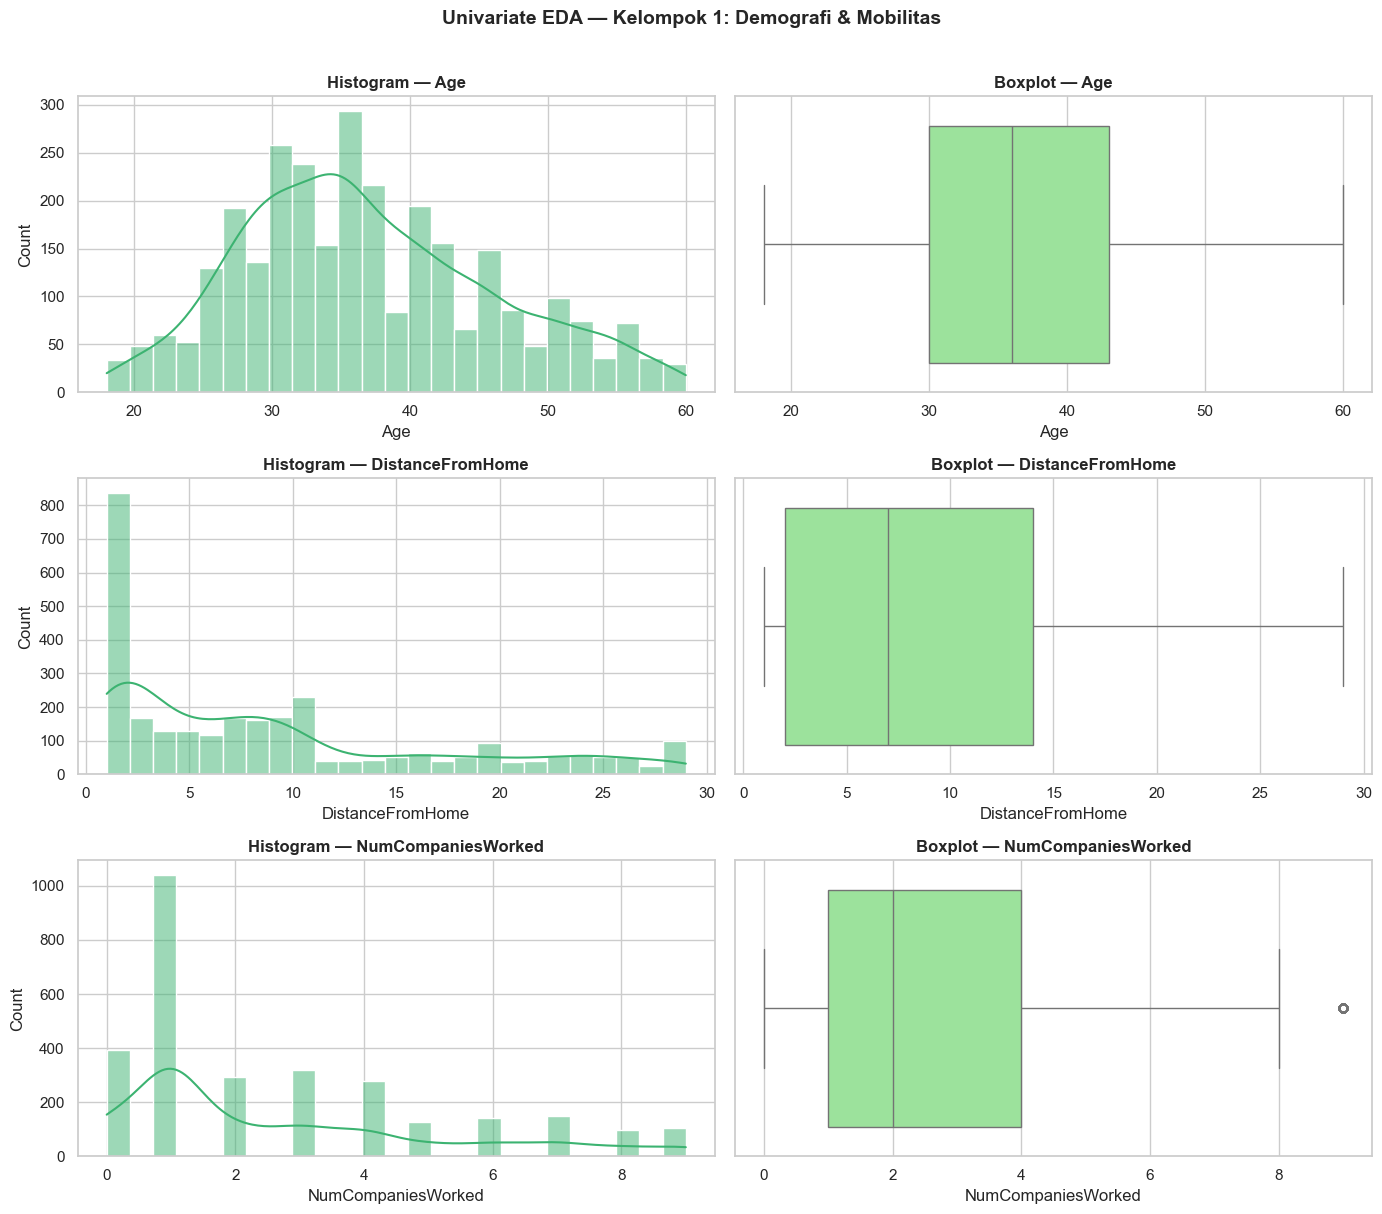

>> Age: distribusi near-normal (mean 37 th, std 9 th), range 18–60, tanpa outlier ekstrem
>> DistanceFromHome: right-skewed, mayoritas dekat kantor (Q1=2, Q3=14 km)
   408 karyawan (13.9%) berjarak >20 km dari kantor
>> NumCompaniesWorked: right-skewed, median 2 perusahaan — terdapat outlier karyawan frequent-mover (9 perusahaan)


In [8]:
# ── (a) Kelompok 1: Demografi & Mobilitas ───────────────────────────────────
group1 = ['Age', 'DistanceFromHome', 'NumCompaniesWorked']
fig, axes = plt.subplots(nrows=len(group1), ncols=2, figsize=(14, 4 * len(group1)))

for i, col in enumerate(group1):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='mediumseagreen', bins=25)
    axes[i, 0].set_title(f'Histogram — {col}', fontweight='bold')
    sns.boxplot(x=df[col],          ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 1: Demografi & Mobilitas',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(">> Age: distribusi near-normal (mean 37 th, std 9 th), range 18–60, tanpa outlier ekstrem")
print(">> DistanceFromHome: right-skewed, mayoritas dekat kantor (Q1=2, Q3=14 km)")
print(f"   {(df['DistanceFromHome'] > 20).sum()} karyawan ({(df['DistanceFromHome'] > 20).mean()*100:.1f}%) berjarak >20 km dari kantor")
print(">> NumCompaniesWorked: right-skewed, median 2 perusahaan — terdapat outlier karyawan frequent-mover (9 perusahaan)")

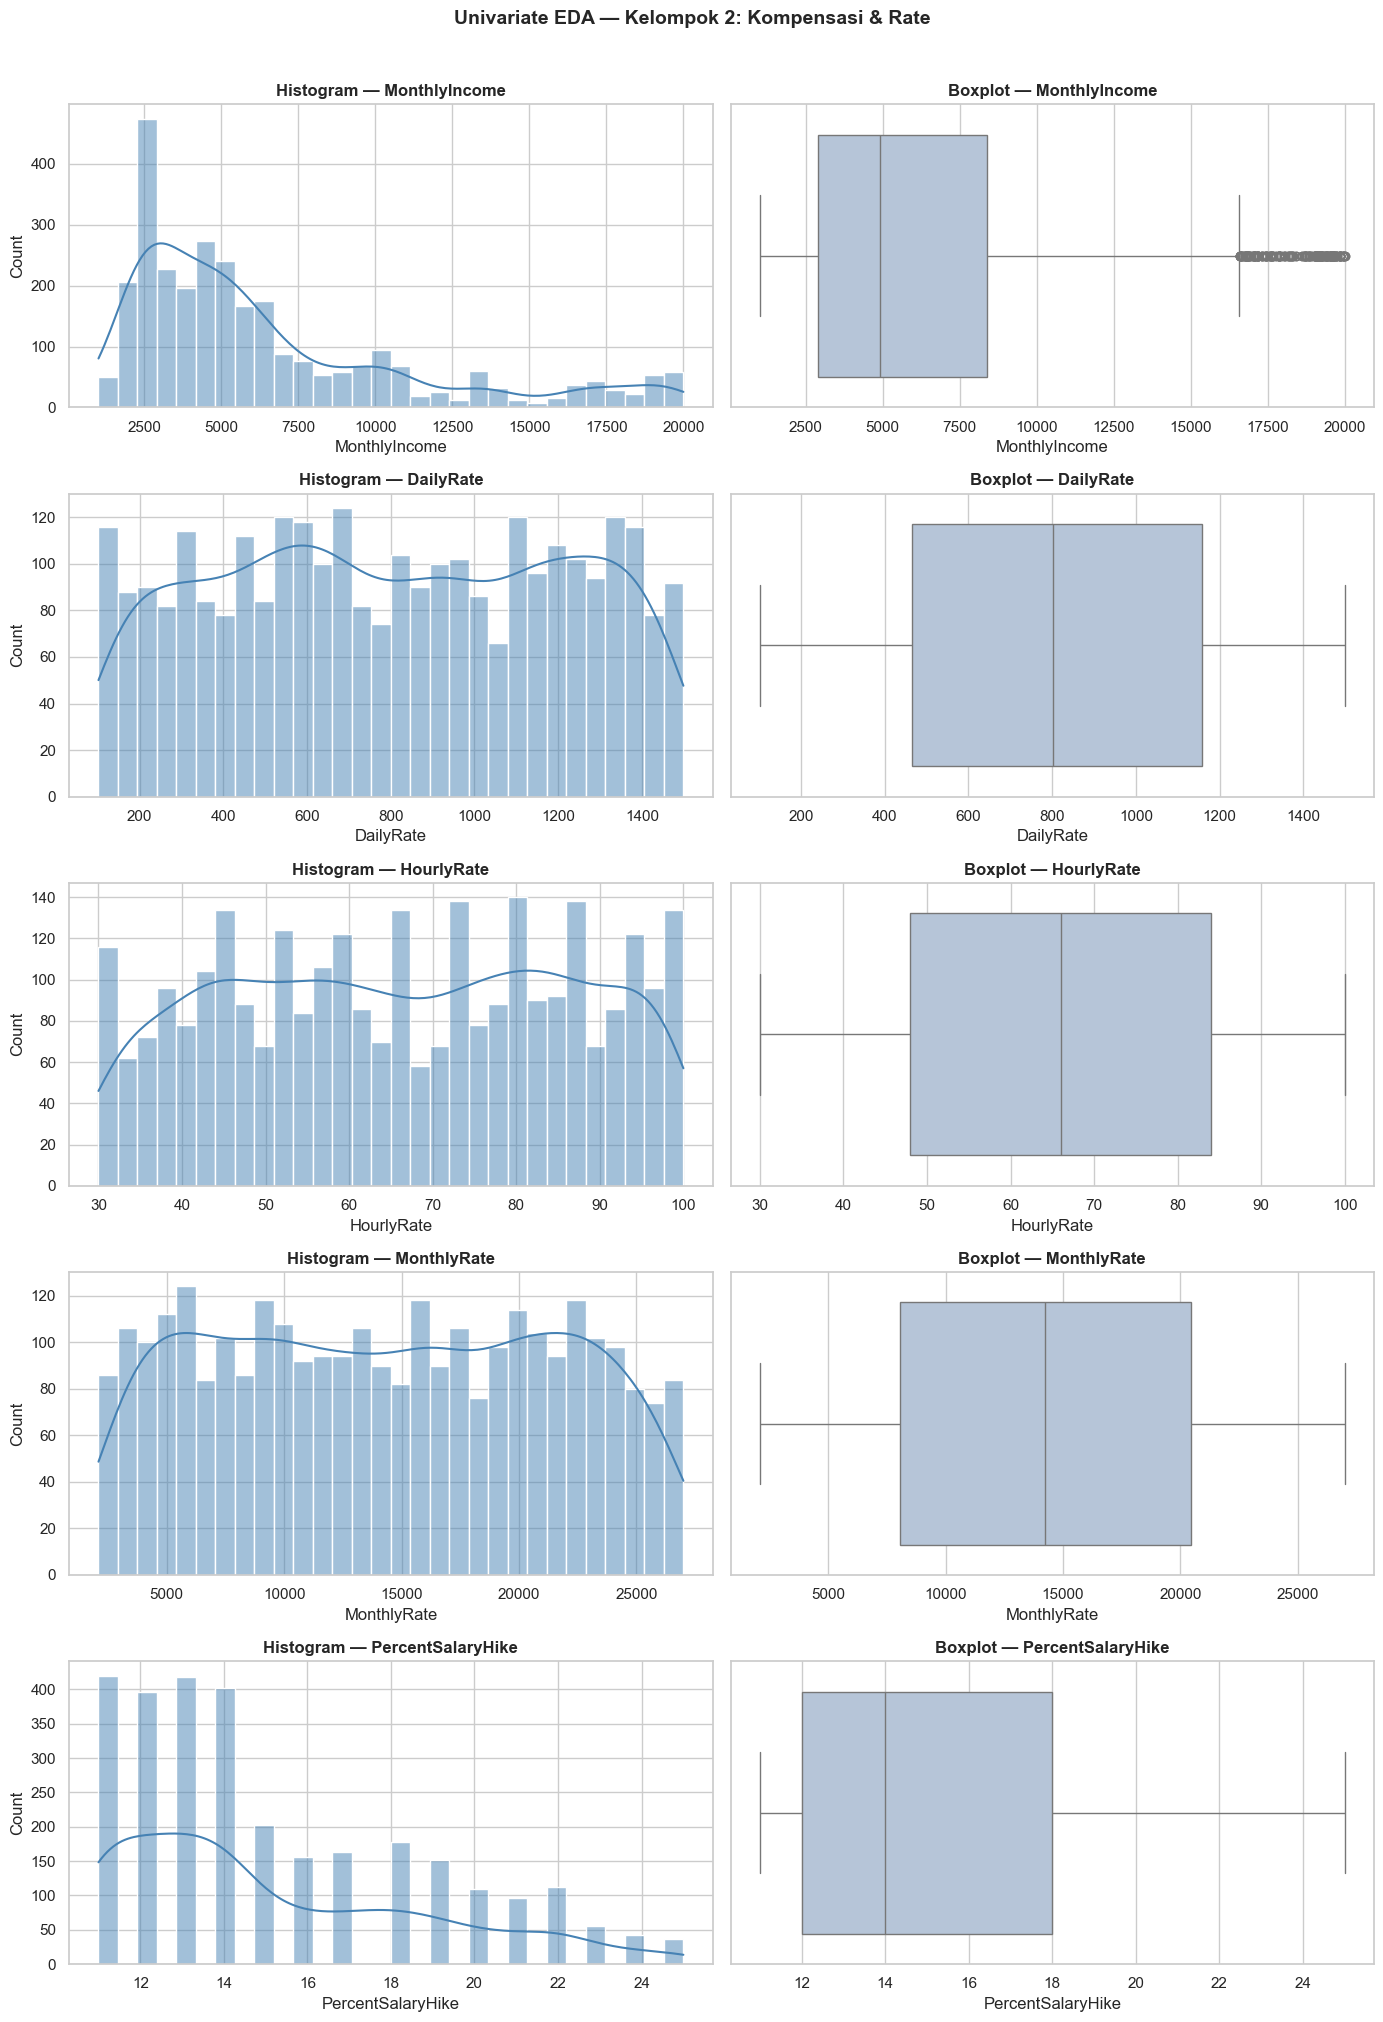

>> MonthlyIncome: SANGAT right-skewed, banyak outlier atas — eksekutif bergaji tinggi
   Mean $6503 vs Median $4919 (gap besar)
>> DailyRate & MonthlyRate: distribusi mendekati uniform — tidak berkorelasi dengan MonthlyIncome
>> HourlyRate: distribusi uniform (30–100), sedikit outlier
>> PercentSalaryHike: terpusat di 11–15%, range 11–25% — perbedaan kenaikan gaji relatif kecil


In [9]:
# ── (a) Kelompok 2: Kompensasi ───────────────────────────────────────────────
group2 = ['MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike']
fig, axes = plt.subplots(nrows=len(group2), ncols=2, figsize=(14, 4 * len(group2)))

for i, col in enumerate(group2):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue', bins=30)
    axes[i, 0].set_title(f'Histogram — {col}', fontweight='bold')
    sns.boxplot(x=df[col],          ax=axes[i, 1], color='lightsteelblue')
    axes[i, 1].set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 2: Kompensasi & Rate',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(">> MonthlyIncome: SANGAT right-skewed, banyak outlier atas — eksekutif bergaji tinggi")
print(f"   Mean ${df['MonthlyIncome'].mean():.0f} vs Median ${df['MonthlyIncome'].median():.0f} (gap besar)")
print(">> DailyRate & MonthlyRate: distribusi mendekati uniform — tidak berkorelasi dengan MonthlyIncome")
print(">> HourlyRate: distribusi uniform (30–100), sedikit outlier")
print(">> PercentSalaryHike: terpusat di 11–15%, range 11–25% — perbedaan kenaikan gaji relatif kecil")

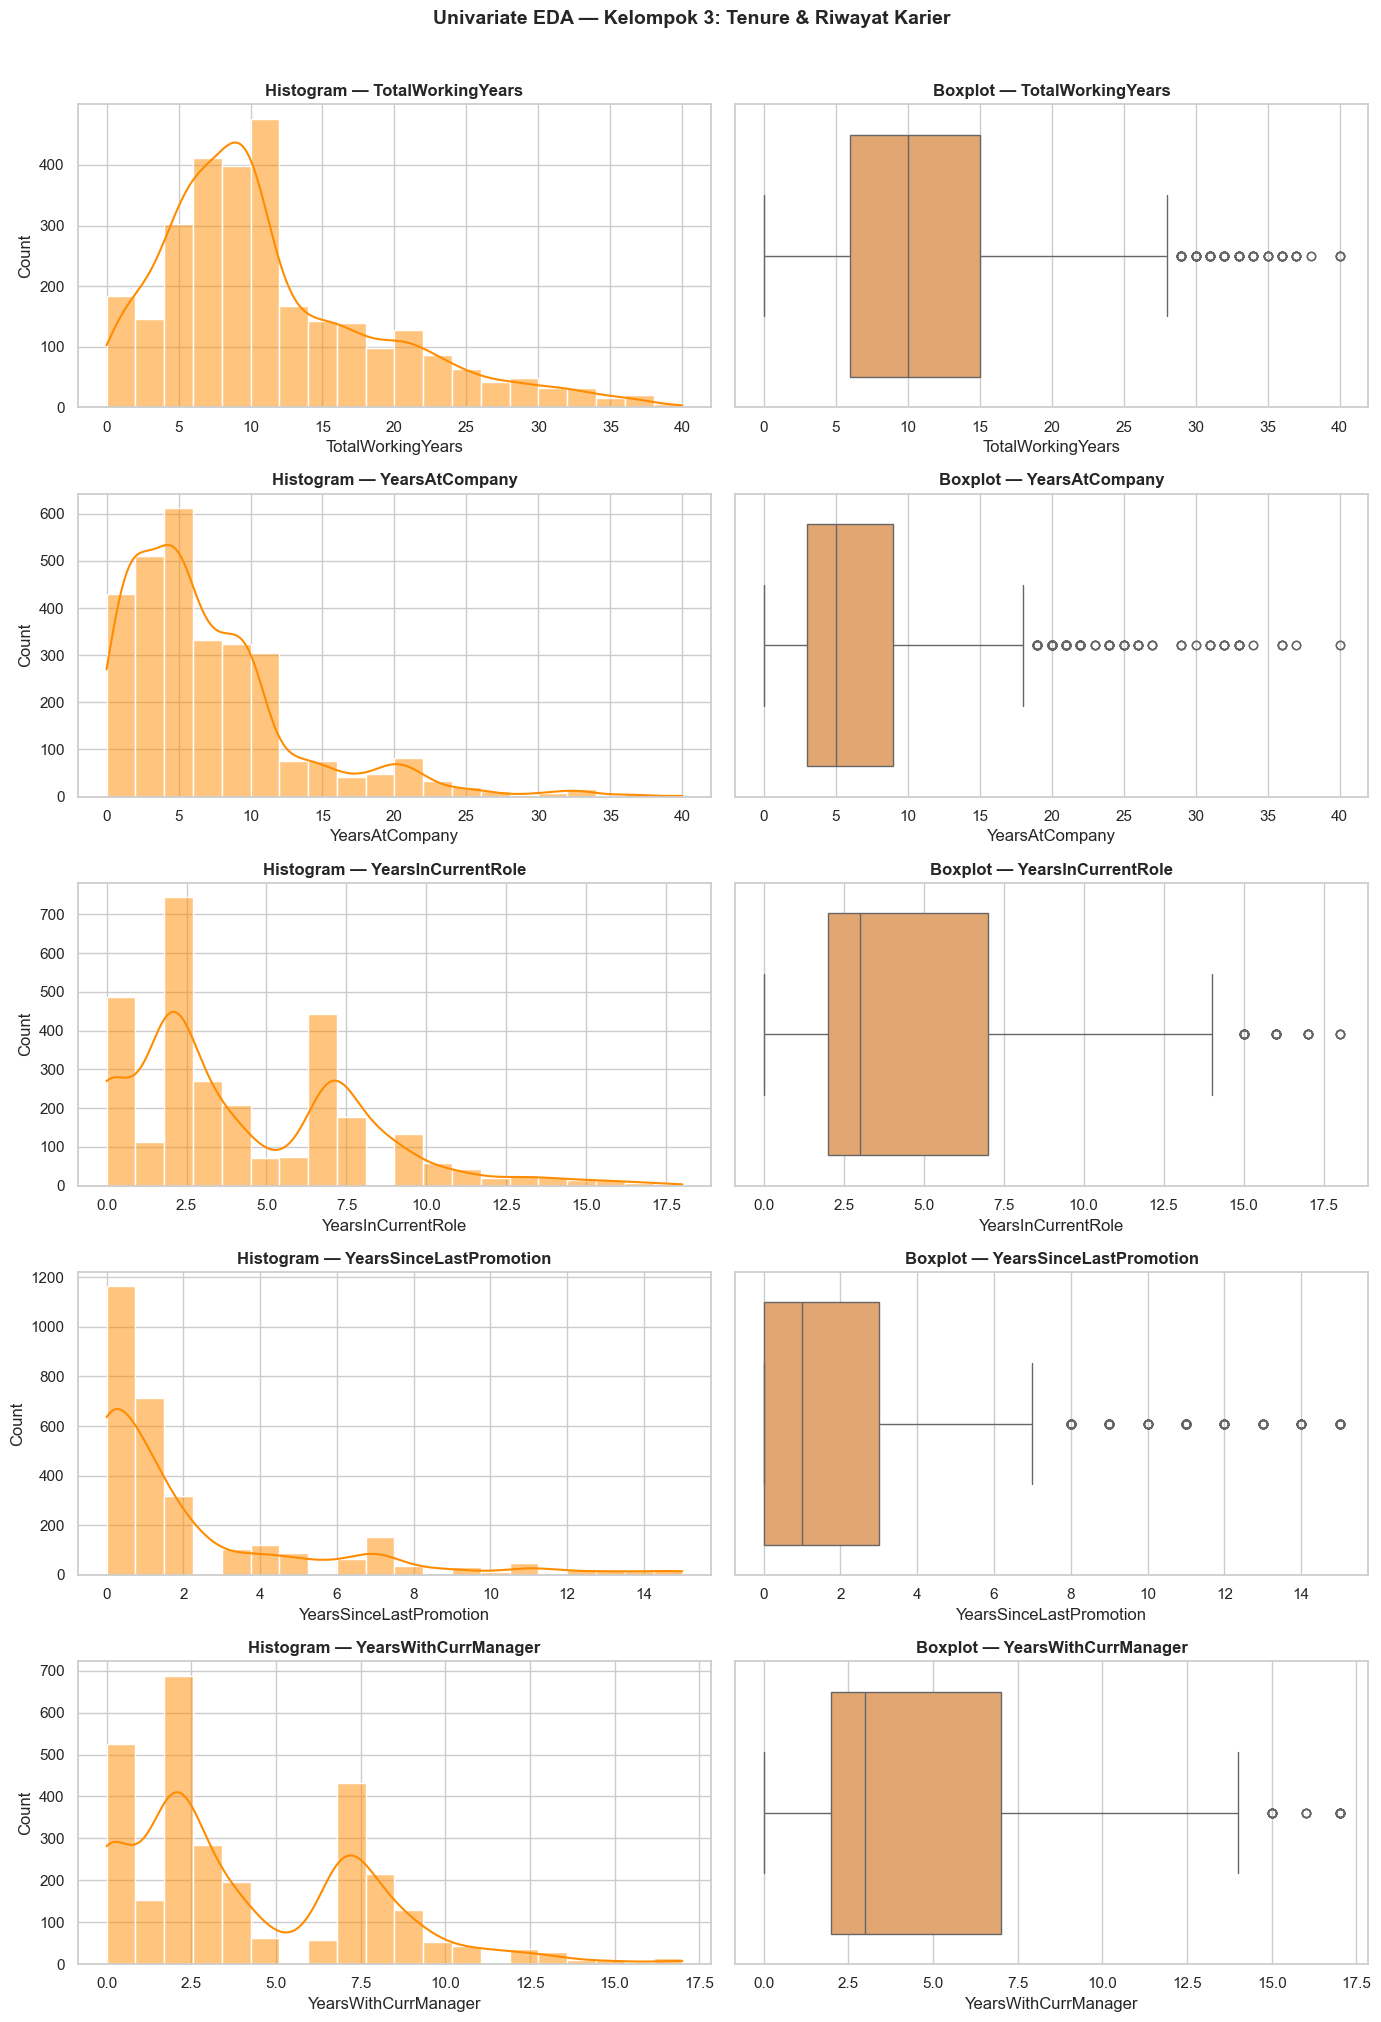

>> Semua variabel tenure right-skewed — banyak karyawan masih baru (0–3 tahun)
>> TotalWorkingYears: mean 11.3 th; karyawan berpengalaman ada yang >35 th (outlier)
>> YearsAtCompany: mean 7 th tapi median ~5 th — mayoritas masih junior di perusahaan ini
>> YearsSinceLastPromotion: mean 2.2 th, max 15 th — ada karyawan yg sangat lama tidak dipromosikan
>> YearsWithCurrManager: distribusi serupa YearsAtCompany — pergantian manajer sering terjadi


In [10]:
# ── (a) Kelompok 3: Tenure (Lama Bekerja) ───────────────────────────────────
group3 = ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
          'YearsSinceLastPromotion', 'YearsWithCurrManager']
fig, axes = plt.subplots(nrows=len(group3), ncols=2, figsize=(14, 4 * len(group3)))

for i, col in enumerate(group3):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='darkorange', bins=20)
    axes[i, 0].set_title(f'Histogram — {col}', fontweight='bold')
    sns.boxplot(x=df[col],          ax=axes[i, 1], color='sandybrown')
    axes[i, 1].set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 3: Tenure & Riwayat Karier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(">> Semua variabel tenure right-skewed — banyak karyawan masih baru (0–3 tahun)")
print(">> TotalWorkingYears: mean 11.3 th; karyawan berpengalaman ada yang >35 th (outlier)")
print(">> YearsAtCompany: mean 7 th tapi median ~5 th — mayoritas masih junior di perusahaan ini")
print(">> YearsSinceLastPromotion: mean 2.2 th, max 15 th — ada karyawan yg sangat lama tidak dipromosikan")
print(">> YearsWithCurrManager: distribusi serupa YearsAtCompany — pergantian manajer sering terjadi")

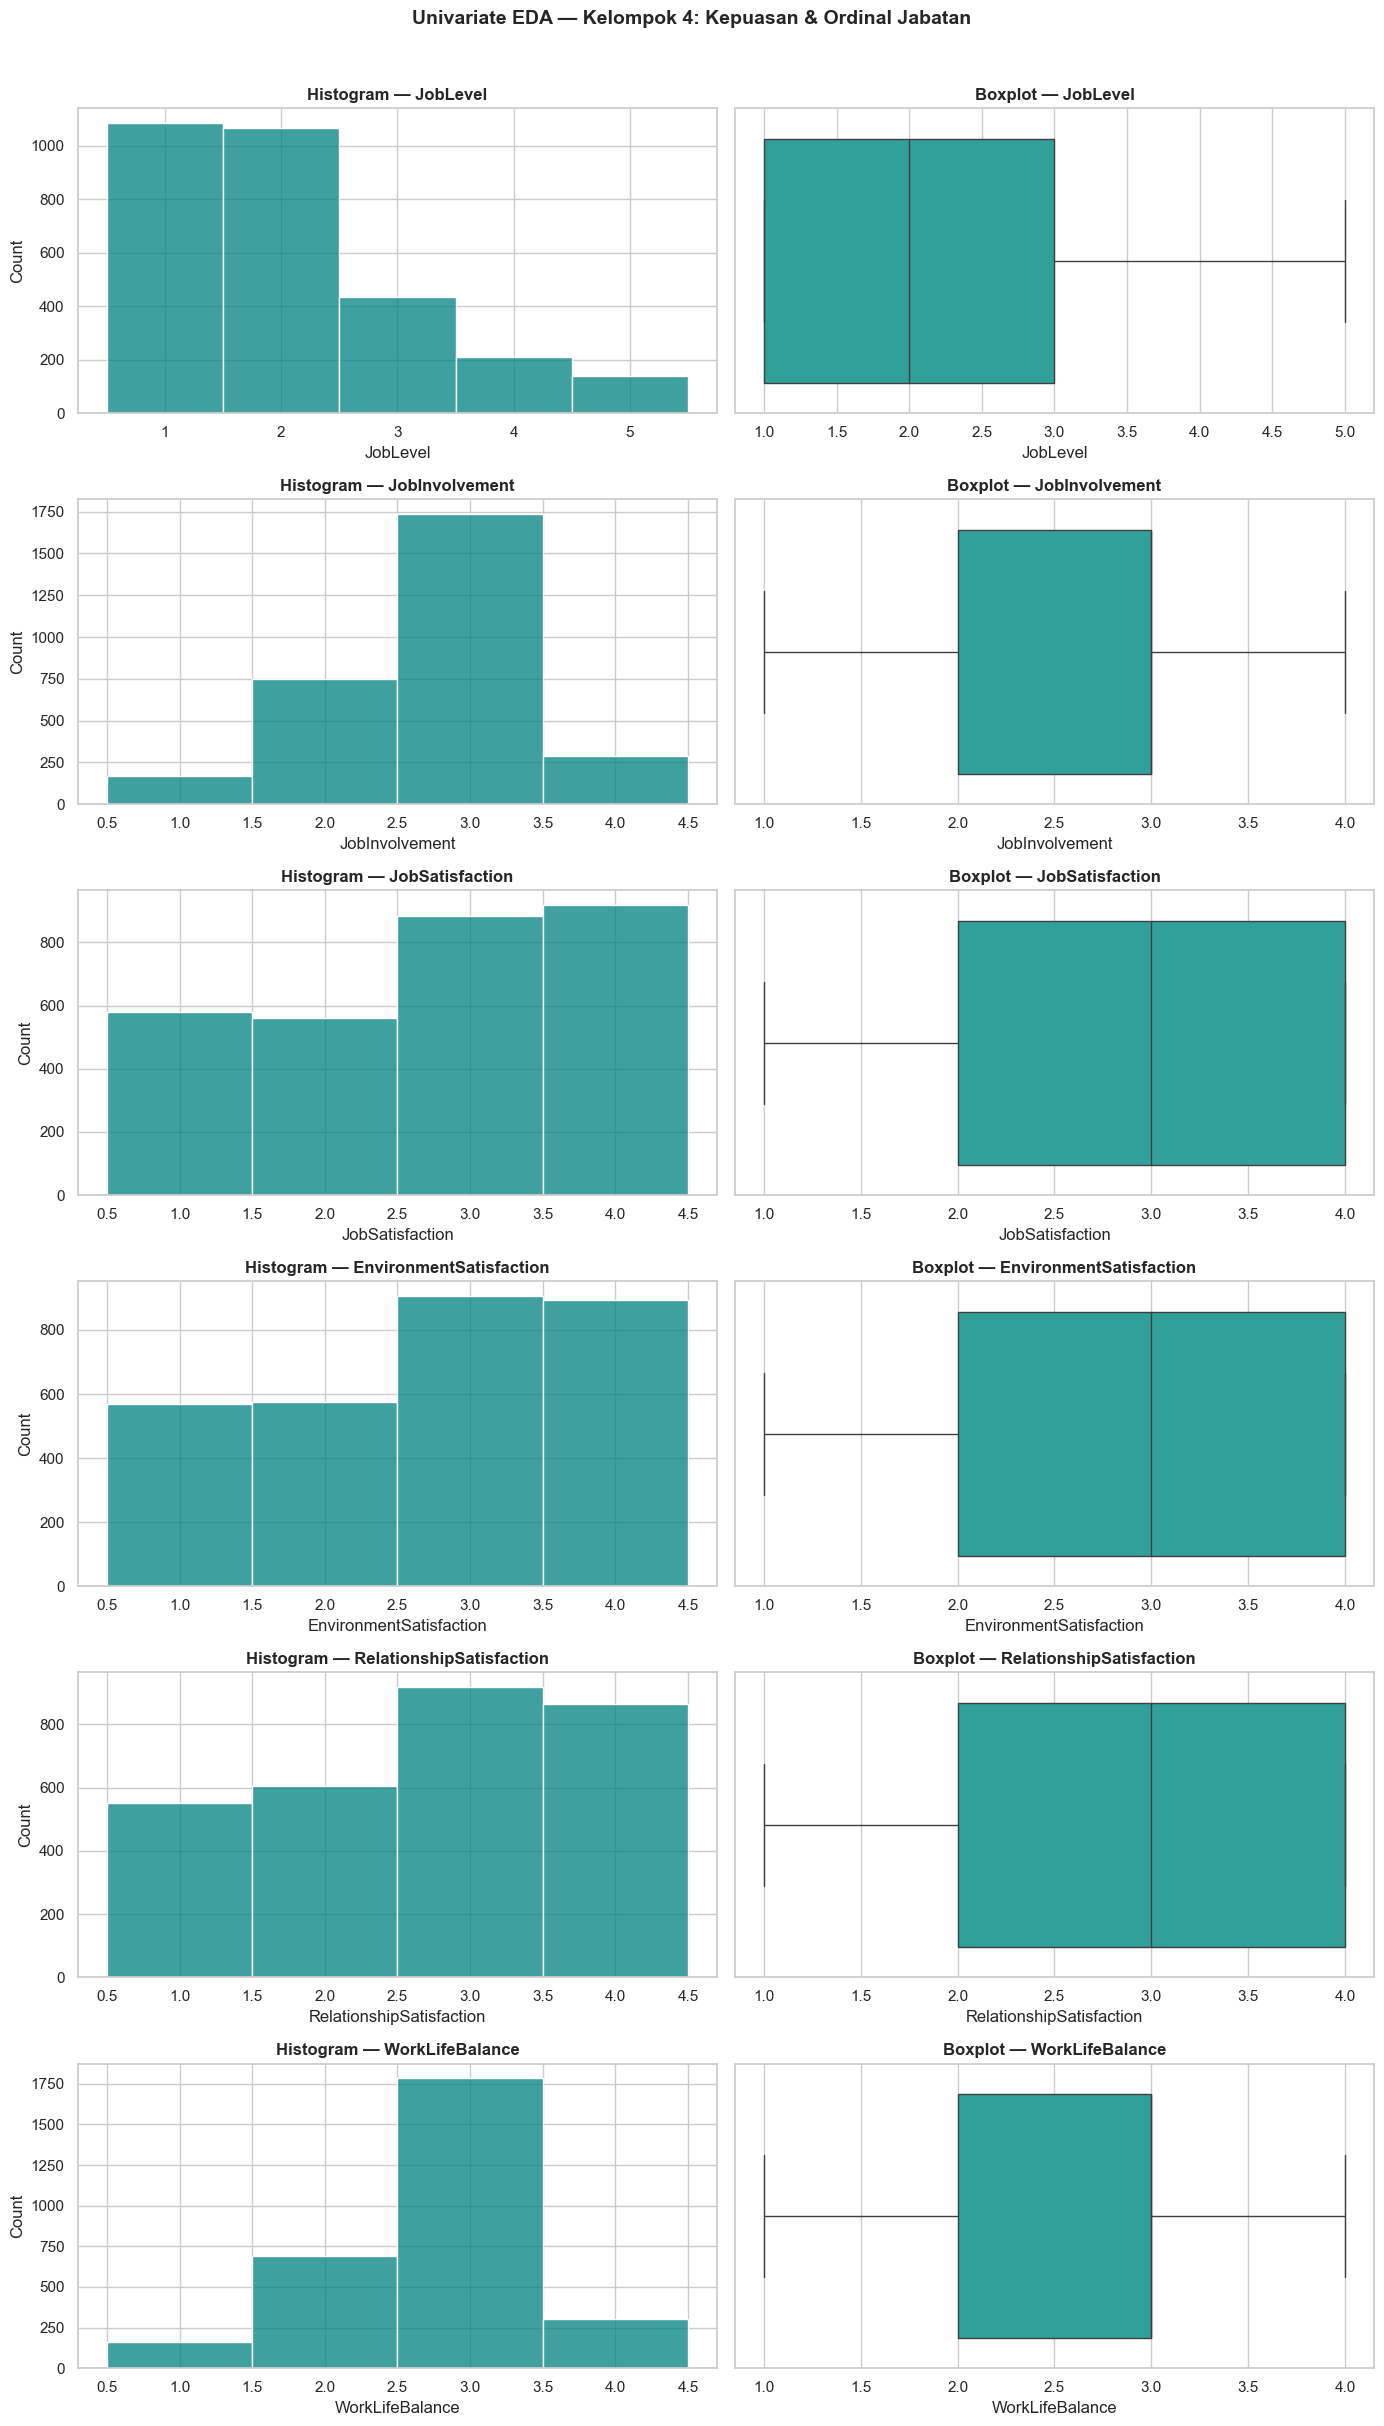

>> JobLevel: mayoritas Level 1–2 (junior) — piramida hierarki wajar
>> JobSatisfaction / EnvironmentSatisfaction / RelationshipSatisfaction: distribusi merata 1–4
   rata-rata ~2.7 (Medium-High) — ada ruang peningkatan signifikan
>> WorkLifeBalance: mayoritas di level 3 (Better) — namun 28% karyawan lembur mengancam keseimbangan ini


In [11]:
# ── (a) Kelompok 4: Kepuasan & Ordinal ──────────────────────────────────────
group4 = ['JobLevel', 'JobInvolvement', 'JobSatisfaction',
          'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']
fig, axes = plt.subplots(nrows=len(group4), ncols=2, figsize=(14, 4 * len(group4)))

for i, col in enumerate(group4):
    sns.histplot(df[col], kde=False, ax=axes[i, 0], color='teal', discrete=True)
    axes[i, 0].set_title(f'Histogram — {col}', fontweight='bold')
    sns.boxplot(x=df[col],          ax=axes[i, 1], color='lightseagreen')
    axes[i, 1].set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 4: Kepuasan & Ordinal Jabatan',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(">> JobLevel: mayoritas Level 1–2 (junior) — piramida hierarki wajar")
print(">> JobSatisfaction / EnvironmentSatisfaction / RelationshipSatisfaction: distribusi merata 1–4")
print("   rata-rata ~2.7 (Medium-High) — ada ruang peningkatan signifikan")
print(">> WorkLifeBalance: mayoritas di level 3 (Better) — namun 28% karyawan lembur mengancam keseimbangan ini")

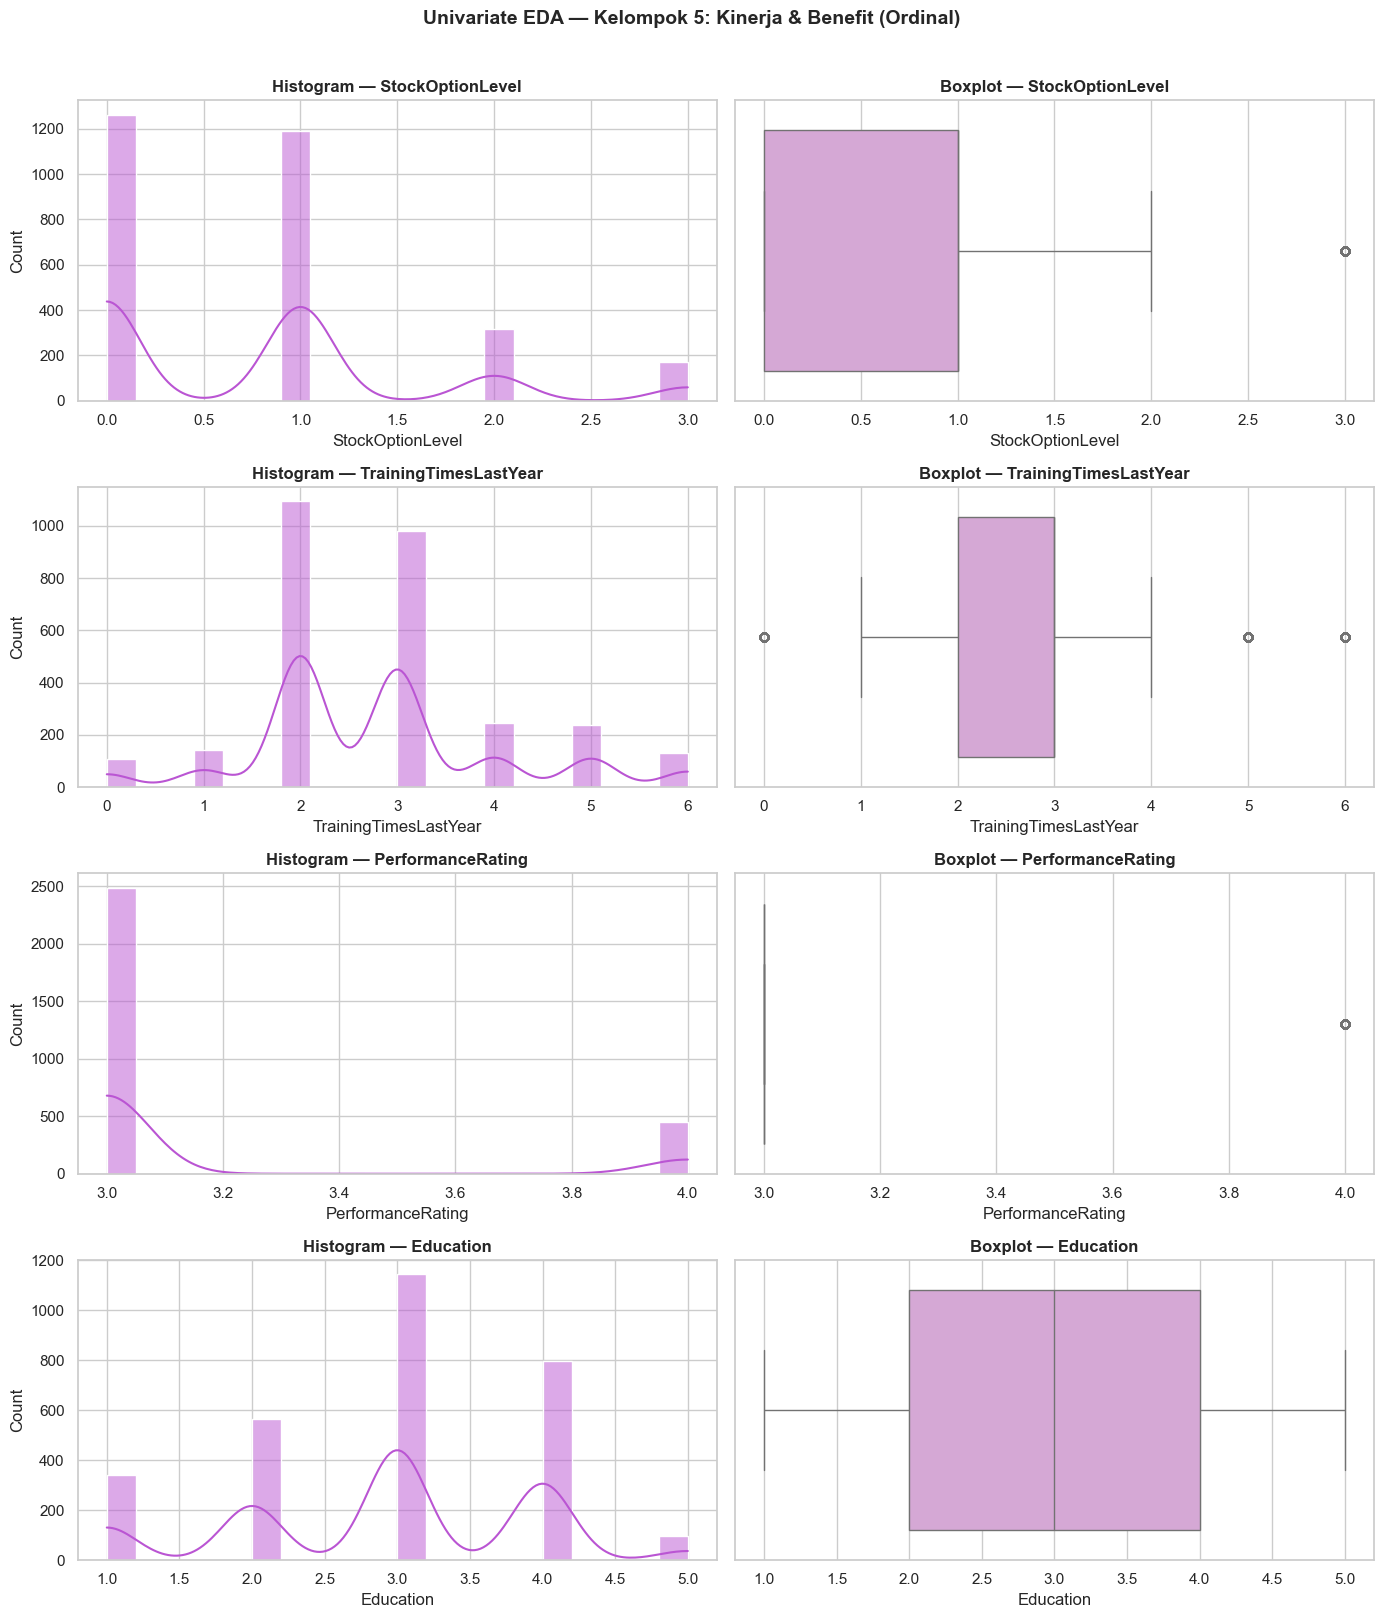

>> StockOptionLevel: mayoritas Level 0 (tanpa opsi saham) — benefit ini bisa jadi insentif retensi
>> TrainingTimesLastYear: distribusi unimodal sekitar 2–3 kali; karyawan dgn 0 training perlu perhatian
>> PerformanceRating: sangat terkonsentrasi di nilai 3 (Excellent) — sedikit variasi
>> Education: distribusi cukup merata di level 1–4; level 5 (Doctor) sangat sedikit


In [12]:
# ── (a) Kelompok 5: Kinerja & Training ──────────────────────────────────────
group5 = ['StockOptionLevel', 'TrainingTimesLastYear', 'PerformanceRating', 'Education']
fig, axes = plt.subplots(nrows=len(group5), ncols=2, figsize=(14, 4 * len(group5)))

for i, col in enumerate(group5):
    sns.histplot(df[col], kde=True,  ax=axes[i, 0], color='mediumorchid', bins=20)
    axes[i, 0].set_title(f'Histogram — {col}', fontweight='bold')
    sns.boxplot(x=df[col],           ax=axes[i, 1], color='plum')
    axes[i, 1].set_title(f'Boxplot — {col}', fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 5: Kinerja & Benefit (Ordinal)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(">> StockOptionLevel: mayoritas Level 0 (tanpa opsi saham) — benefit ini bisa jadi insentif retensi")
print(">> TrainingTimesLastYear: distribusi unimodal sekitar 2–3 kali; karyawan dgn 0 training perlu perhatian")
print(">> PerformanceRating: sangat terkonsentrasi di nilai 3 (Excellent) — sedikit variasi")
print(">> Education: distribusi cukup merata di level 1–4; level 5 (Doctor) sangat sedikit")

#### (e) Insight & Business Recommendations — Univariate EDA Numerical

---

##### Kompensasi
- **MonthlyIncome** sangat right-skewed (mean \$6.503, median \$4.919) — distribusi tidak normal mencerminkan perbedaan besar antara karyawan junior dan senior/eksekutif. Terdapat outlier di atas (gaji eksekutif tinggi).
  > **Rekomendasi:** Lakukan salary benchmarking per JobLevel. Karyawan Level 1–2 yang gajinya di bawah Q1 (~\$2.911) perlu menjadi prioritas salary review untuk mencegah attrition.
- **DailyRate & HourlyRate & MonthlyRate**: distribusi uniform — tidak ada pola kuat. Tidak berkorelasi langsung dengan MonthlyIncome karena merupakan tarif kontrak terpisah.

##### Demografi & Mobilitas
- **Age**: distribusi near-normal (mean 37 th, std 9 th). Rentang 18–60 tahun tanpa outlier — workforce yang beragam usia.
  > **Rekomendasi:** Perhatikan karyawan muda (18–25 th) yang mungkin masih dalam fase eksplorasi karier → berikan program career path yang jelas.
- **DistanceFromHome**: right-skewed, mayoritas tinggal dekat kantor (median 7 km). Ada outlier karyawan yang jauh (>20 km).
  > **Rekomendasi:** Karyawan dengan jarak rumah jauh berisiko lebih tinggi lelah komuter → pertimbangkan remote work atau subsidi transportasi.
- **NumCompaniesWorked**: right-skewed (median 2). Karyawan yang pernah bekerja di banyak perusahaan (>5) bisa jadi job-hopper dengan risiko attrition lebih tinggi.

##### Tenure (Lama Bekerja)
- **YearsAtCompany & TotalWorkingYears**: keduanya right-skewed — banyak karyawan masih baru (0–3 tahun). Ini adalah segmen paling berisiko attrition.
  > **Rekomendasi:** Program retensi intensif untuk karyawan dengan YearsAtCompany < 2 tahun: mentoring, check-in rutin, dan career roadmap.
- **YearsSinceLastPromotion**: mean 2.2 tahun, max 15 tahun — karyawan yang tidak dipromosikan >5 tahun kemungkinan sudah tidak termotivasi.
  > **Rekomendasi:** Audit karyawan dengan YearsSinceLastPromotion > 3 → lakukan performance & career discussion.

##### Kepuasan Kerja (Skala Ordinal 1–4)
- **JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance**: rata-rata sekitar 2.7/4 (Medium-High). Distribusi relatif seimbang di semua level.
  > **Rekomendasi:** Identifikasi karyawan dengan skor ≤ 2 pada variabel kepuasan → mereka adalah kandidat attrition tertinggi. Buat program peningkatan lingkungan kerja.
- **JobLevel**: mayoritas di Level 1–2 (junior) → piramida hierarki normal. Level eksekutif (5) sangat sedikit.
- **StockOptionLevel**: mayoritas tidak memiliki stock option (Level 0) → benefit ini bisa menjadi insentif retensi yang efektif.

##### Kinerja & Training
- **PerformanceRating**: mayoritas di nilai 3 (Excellent) — distribusi sangat terkonsentrasi. Sedikit sekali yang mendapat nilai 4 (Outstanding).
  > **Rekomendasi:** Review sistem penilaian kinerja — apakah skala 1–4 digunakan secara merata? Skewness tinggi bisa mengindikasikan bias evaluasi.
- **TrainingTimesLastYear**: rata-rata 2.8 kali. Karyawan dengan 0 training cukup signifikan — perlu perhatian.
  > **Rekomendasi:** Pastikan setiap karyawan mendapat minimal 2 sesi training per tahun untuk mendukung pengembangan kompetensi.

### Task (2): Univariate EDA — Categorical Columns

**Sub-tasks:**
- **(a)** Countplot untuk setiap kolom kategorik
- **(b)** Daftar kategori unik dan frekuensinya per kolom (tabel)
- **(c)** Temuan menarik dari hasil EDA

Chart dikelompokkan berdasarkan tema: **Demografi Personal → Kondisi Kerja → Peran & Latar Belakang**

#### Teks soal asli (coding test) — (2)
Lakukan EDA univariat untuk setiap kolom kategorikal pada employee.csv yang mencakup: (a) countplot untuk tiap kolom; (b) daftar kategori unik dan frekuensinya untuk tiap kolom; (c) identifikasi hal yang menurut anda menarik dari hasil EDA yang Anda dapatkan.


In [13]:
# ── (b) Identifikasi & Tabel Frekuensi Semua Kolom Kategorik ─────────────────
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print(f"Kolom kategorik ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    counts = df[col].value_counts()
    props  = (df[col].value_counts(normalize=True) * 100).round(2)
    df_freq = pd.DataFrame({'Frekuensi': counts, 'Proporsi (%)': props})
    print(f"[{col}] — {df[col].nunique()} kategori unik:")
    display(
        df_freq.style
        .background_gradient(cmap='Purples', subset=['Frekuensi'])
        .format({'Proporsi (%)': '{:.2f}'})
        .set_caption(f"Distribusi: {col}")
    )
    print()

Kolom kategorik (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

[Attrition] — 2 kategori unik:


,Frekuensi,Proporsi (%)
Attrition,,
No,2466,83.88
Yes,474,16.12



[BusinessTravel] — 3 kategori unik:


,Frekuensi,Proporsi (%)
BusinessTravel,,
Travel_Rarely,2086,70.95
Travel_Frequently,554,18.84
Non-Travel,300,10.20



[Department] — 3 kategori unik:


,Frekuensi,Proporsi (%)
Department,,
Research & Development,1922,65.37
Sales,892,30.34
Human Resources,126,4.29



[EducationField] — 6 kategori unik:


,Frekuensi,Proporsi (%)
EducationField,,
Life Sciences,1212,41.22
Medical,928,31.56
Marketing,318,10.82
Technical Degree,264,8.98
Other,164,5.58
Human Resources,54,1.84



[Gender] — 2 kategori unik:


,Frekuensi,Proporsi (%)
Gender,,
Male,1764,60.00
Female,1176,40.00



[JobRole] — 9 kategori unik:


,Frekuensi,Proporsi (%)
JobRole,,
Sales Executive,652,22.18
Research Scientist,584,19.86
Laboratory Technician,518,17.62
Manufacturing Director,290,9.86
Healthcare Representative,262,8.91
Manager,204,6.94
Sales Representative,166,5.65
Research Director,160,5.44
Human Resources,104,3.54



[MaritalStatus] — 3 kategori unik:


,Frekuensi,Proporsi (%)
MaritalStatus,,
Married,1346,45.78
Single,940,31.97
Divorced,654,22.24



[OverTime] — 2 kategori unik:


,Frekuensi,Proporsi (%)
OverTime,,
No,2108,71.70
Yes,832,28.30


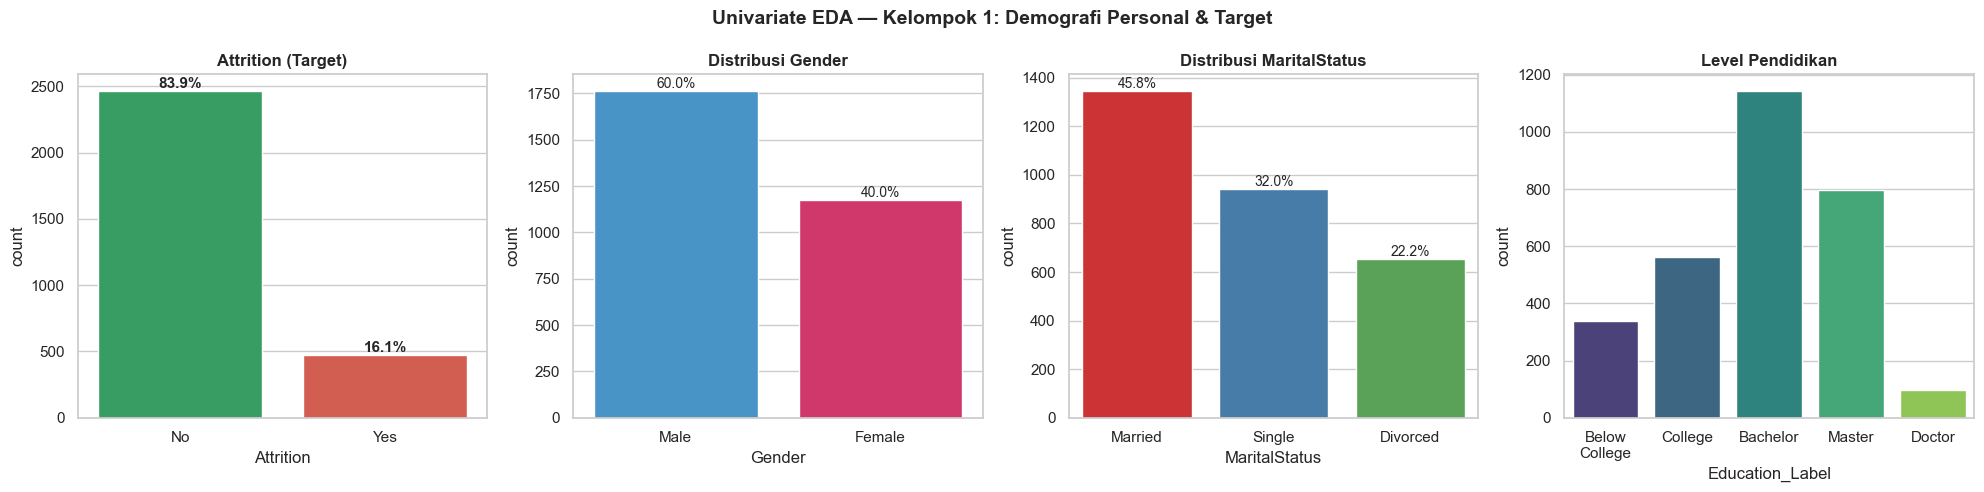

>> Attrition: IMBALANCED — 83.9% No vs 16.1% Yes → perlu penanganan class imbalance saat modeling
>> Gender: Male 60% vs Female 40%
>> MaritalStatus: Married 46%, Single 32%, Divorced 22%
>> Education: Bachelor (38.6%) paling banyak, Doctor (4.9%) paling sedikit


In [14]:
# ── (a) Chart Kelompok 1: Demografi Personal & Target ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Attrition (target)
order_attr = df['Attrition'].value_counts().index
colors_attr = ['#27ae60', '#e74c3c']
sns.countplot(x='Attrition', data=df, order=order_attr, palette=colors_attr, ax=axes[0])
axes[0].set_title('Attrition (Target)', fontweight='bold')
for p in axes[0].patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    axes[0].annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gender
order_gen = df['Gender'].value_counts().index
sns.countplot(x='Gender', data=df, order=order_gen, palette=['#3498db', '#e91e63'], ax=axes[1])
axes[1].set_title('Distribusi Gender', fontweight='bold')
for p in axes[1].patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    axes[1].annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# MaritalStatus
order_ms = df['MaritalStatus'].value_counts().index
sns.countplot(x='MaritalStatus', data=df, order=order_ms, palette='Set1', ax=axes[2])
axes[2].set_title('Distribusi MaritalStatus', fontweight='bold')
for p in axes[2].patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    axes[2].annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Education level (treat as categorical bins)
edu_map = {1: 'Below\nCollege', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df_temp = df.copy()
df_temp['Education_Label'] = df_temp['Education'].map(edu_map)
order_edu_lbl = ['Below\nCollege', 'College', 'Bachelor', 'Master', 'Doctor']
sns.countplot(x='Education_Label', data=df_temp, order=order_edu_lbl, palette='viridis', ax=axes[3])
axes[3].set_title('Level Pendidikan', fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 1: Demografi Personal & Target',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(">> Attrition: IMBALANCED — 83.9% No vs 16.1% Yes → perlu penanganan class imbalance saat modeling")
print(">> Gender: Male 60% vs Female 40%")
print(">> MaritalStatus: Married 46%, Single 32%, Divorced 22%")
print(">> Education: Bachelor (38.6%) paling banyak, Doctor (4.9%) paling sedikit")

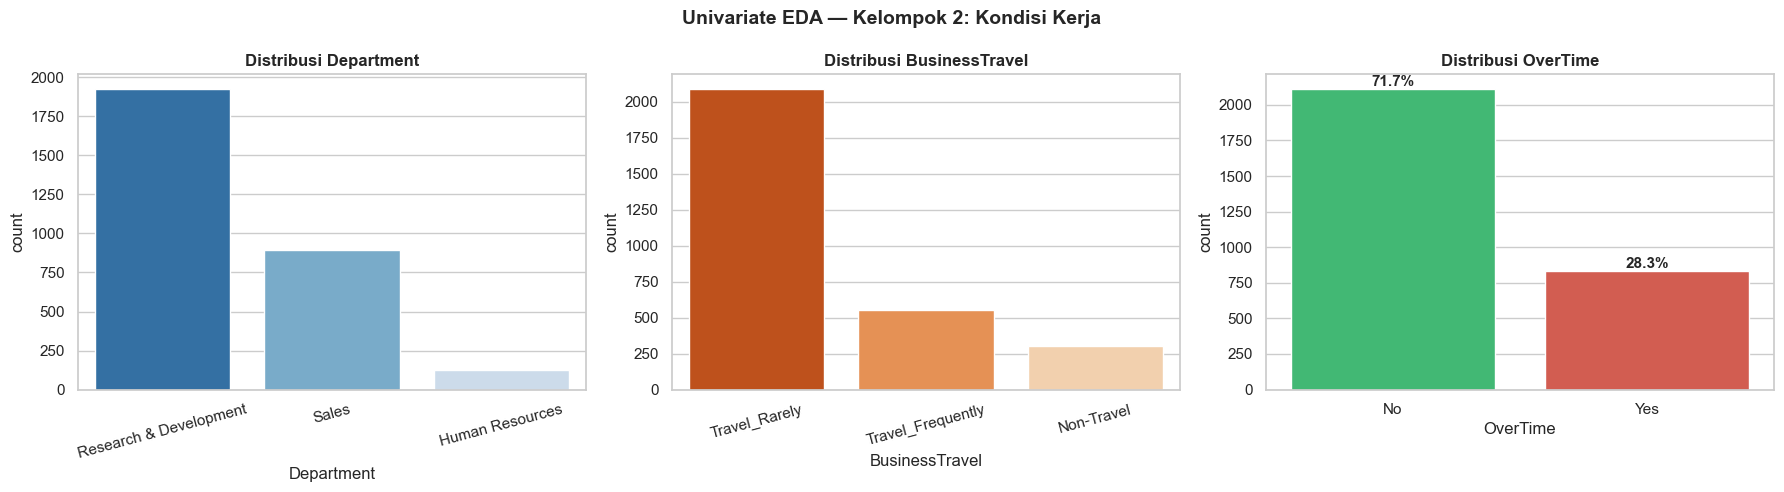

>> Department: R&D (65.4%), Sales (30.4%), HR (4.2%)
>> BusinessTravel: 71% Travel_Rarely — sebagian besar tidak sering bepergian dinas
>> OverTime: 28.4% karyawan bekerja lembur — faktor risiko burnout dan attrition signifikan


In [15]:
# ── (a) Chart Kelompok 2: Kondisi Kerja ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order_dept = df['Department'].value_counts().index
sns.countplot(x='Department', data=df, order=order_dept, palette='Blues_r', ax=axes[0])
axes[0].set_title('Distribusi Department', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

order_bt = df['BusinessTravel'].value_counts().index
sns.countplot(x='BusinessTravel', data=df, order=order_bt, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Distribusi BusinessTravel', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

order_ot = df['OverTime'].value_counts().index
sns.countplot(x='OverTime', data=df, order=order_ot, palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title('Distribusi OverTime', fontweight='bold')
# annotate percentage
for p in axes[2].patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    axes[2].annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Univariate EDA — Kelompok 2: Kondisi Kerja',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(">> Department: R&D (65.4%), Sales (30.4%), HR (4.2%)")
print(">> BusinessTravel: 71% Travel_Rarely — sebagian besar tidak sering bepergian dinas")
print(">> OverTime: 28.4% karyawan bekerja lembur — faktor risiko burnout dan attrition signifikan")

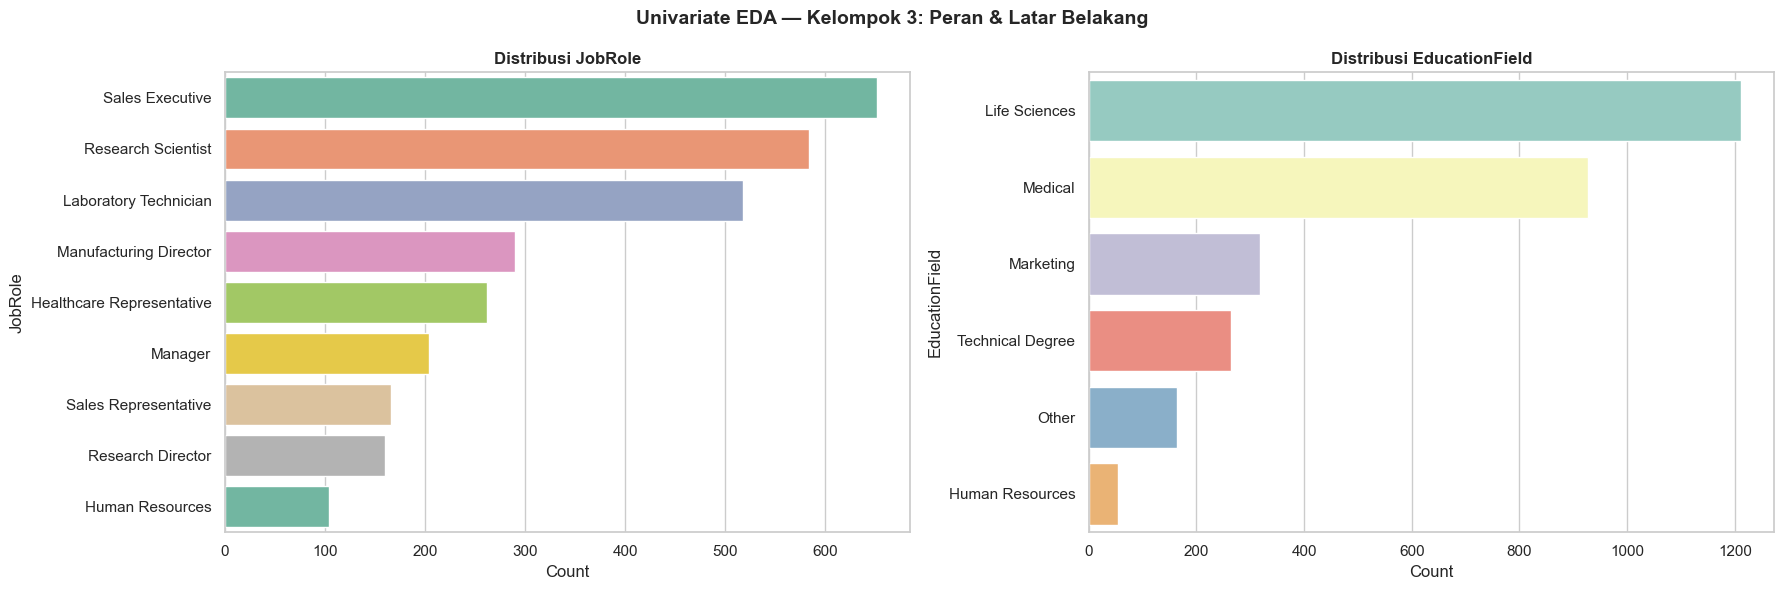

>> JobRole terbesar: Sales Executive (22.3%) dan Research Scientist (19.8%)
>> Sales Representative (5.8%) punya attrition rate tertinggi di antara semua role
>> EducationField: Life Sciences (41%) dan Medical (32%) mendominasi workforce


In [16]:
# ── (a) Chart Kelompok 3: Peran & Latar Belakang Pendidikan ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

order_role = df['JobRole'].value_counts().index
sns.countplot(y='JobRole', data=df, order=order_role, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi JobRole', fontweight='bold')
axes[0].set_xlabel('Count')

order_edu = df['EducationField'].value_counts().index
sns.countplot(y='EducationField', data=df, order=order_edu, palette='Set3', ax=axes[1])
axes[1].set_title('Distribusi EducationField', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Univariate EDA — Kelompok 3: Peran & Latar Belakang',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(">> JobRole terbesar: Sales Executive (22.3%) dan Research Scientist (19.8%)")
print(">> Sales Representative (5.8%) punya attrition rate tertinggi di antara semua role")
print(">> EducationField: Life Sciences (41%) dan Medical (32%) mendominasi workforce")

#### (c) Insight & Business Recommendations — Univariate EDA Categorical

---

##### Target: Attrition
- **16.1% karyawan mengalami attrition** (474 dari 2.940). Dataset sangat **imbalanced** (83.9% No vs 16.1% Yes).
  > **Rekomendasi Modeling:** Gunakan stratified split + **class_weight** (Logistic/DT) dan **scale_pos_weight** (XGBoost) untuk menangani imbalance — tanpa imblearn. Accuracy bukanlah metrik yang tepat — gunakan F1-macro atau ROC AUC.
  > **Rekomendasi Bisnis:** 16% attrition rate tahunan tergolong tinggi. Biaya rekrutmen + onboarding karyawan baru ≈ 6–9 bulan gaji. Investasi dalam retensi sangat worth it.

##### Demografi Personal
- **Gender**: Male 60% vs Female 40% — tidak seimbang namun tidak ekstrem. Perlu cek apakah ada gender pay gap dalam MonthlyIncome.
  > **Rekomendasi:** Lakukan analisis gaji per gender per JobRole untuk memastikan kesetaraan kompensasi.
- **MaritalStatus**: Single 32%, Married 46%, Divorced 22%. Karyawan Single cenderung lebih mobile dan mudah pindah kerja.
  > **Rekomendasi:** Program benefit yang menarik untuk karyawan single (growth opportunity, networking, komunitas) agar tetap engaged.

##### Kondisi Kerja
- **OverTime**: 28.4% karyawan bekerja lembur — angka yang signifikan. Lembur berlebihan adalah driver utama burnout dan attrition.
  > **Rekomendasi:** Audit beban kerja per departemen. Implementasikan kebijakan overtime limit atau kompensasi lembur yang adil.
- **BusinessTravel**: 71% Travel_Rarely, 19% Travel_Frequently. Perjalanan dinas sering = melelahkan dan berdampak pada work-life balance.
  > **Rekomendasi:** Pertimbangkan virtual meeting untuk mengurangi frekuensi travel bagi karyawan yang sering bepergian.
- **Department**: R&D 65%, Sales 30%, HR 5%. Sales memiliki attrition lebih tinggi relatif terhadap proporsinya.
  > **Rekomendasi:** Fokus program retensi di departemen Sales — berikan insentif performa yang kompetitif.

##### Peran & Latar Belakang Pendidikan
- **JobRole**: Sales Representative paling berisiko tinggi attrition. Research Scientist dan Sales Executive adalah dua peran terbesar.
  > **Rekomendasi:** Buat career path yang jelas untuk Sales Representative — sering dianggap dead-end role jika tidak ada jalur promosi yang terstruktur.
- **EducationField**: Life Sciences 41%, Medical 32% mendominasi. EducationField "HR" dan "Technical Degree" memiliki proporsi attrition relatif lebih tinggi.
  > **Rekomendasi:** Pastikan peluang pengembangan profesional sesuai dengan background pendidikan karyawan.

### Task (3): Multivariate EDA — Numerical Columns vs Attrition

**Sub-tasks:**
- **(a)** Boxplot (atau variasinya) antara setiap kolom numerik (sumbu-Y) dan kolom `Attrition` (sumbu-X)
- **(b)** Temuan menarik dari hasil EDA

Chart dikelompokkan: **Kompensasi & Karier → Kepuasan & Benefit → Rate & Mobilitas**

#### Teks soal asli (coding test) — (3)
Lakukan EDA multivariat untuk pasangan kolom numerik dan kolom 'Attrition' pada employee.csv yang mencakup: (a) boxplot (atau variasinya) antara semua kolom numerik (axis y) dan kolom 'attrition' (axis x); (b) identifikasi hal yang menurut anda menarik dari hasil EDA yang Anda dapatkan.


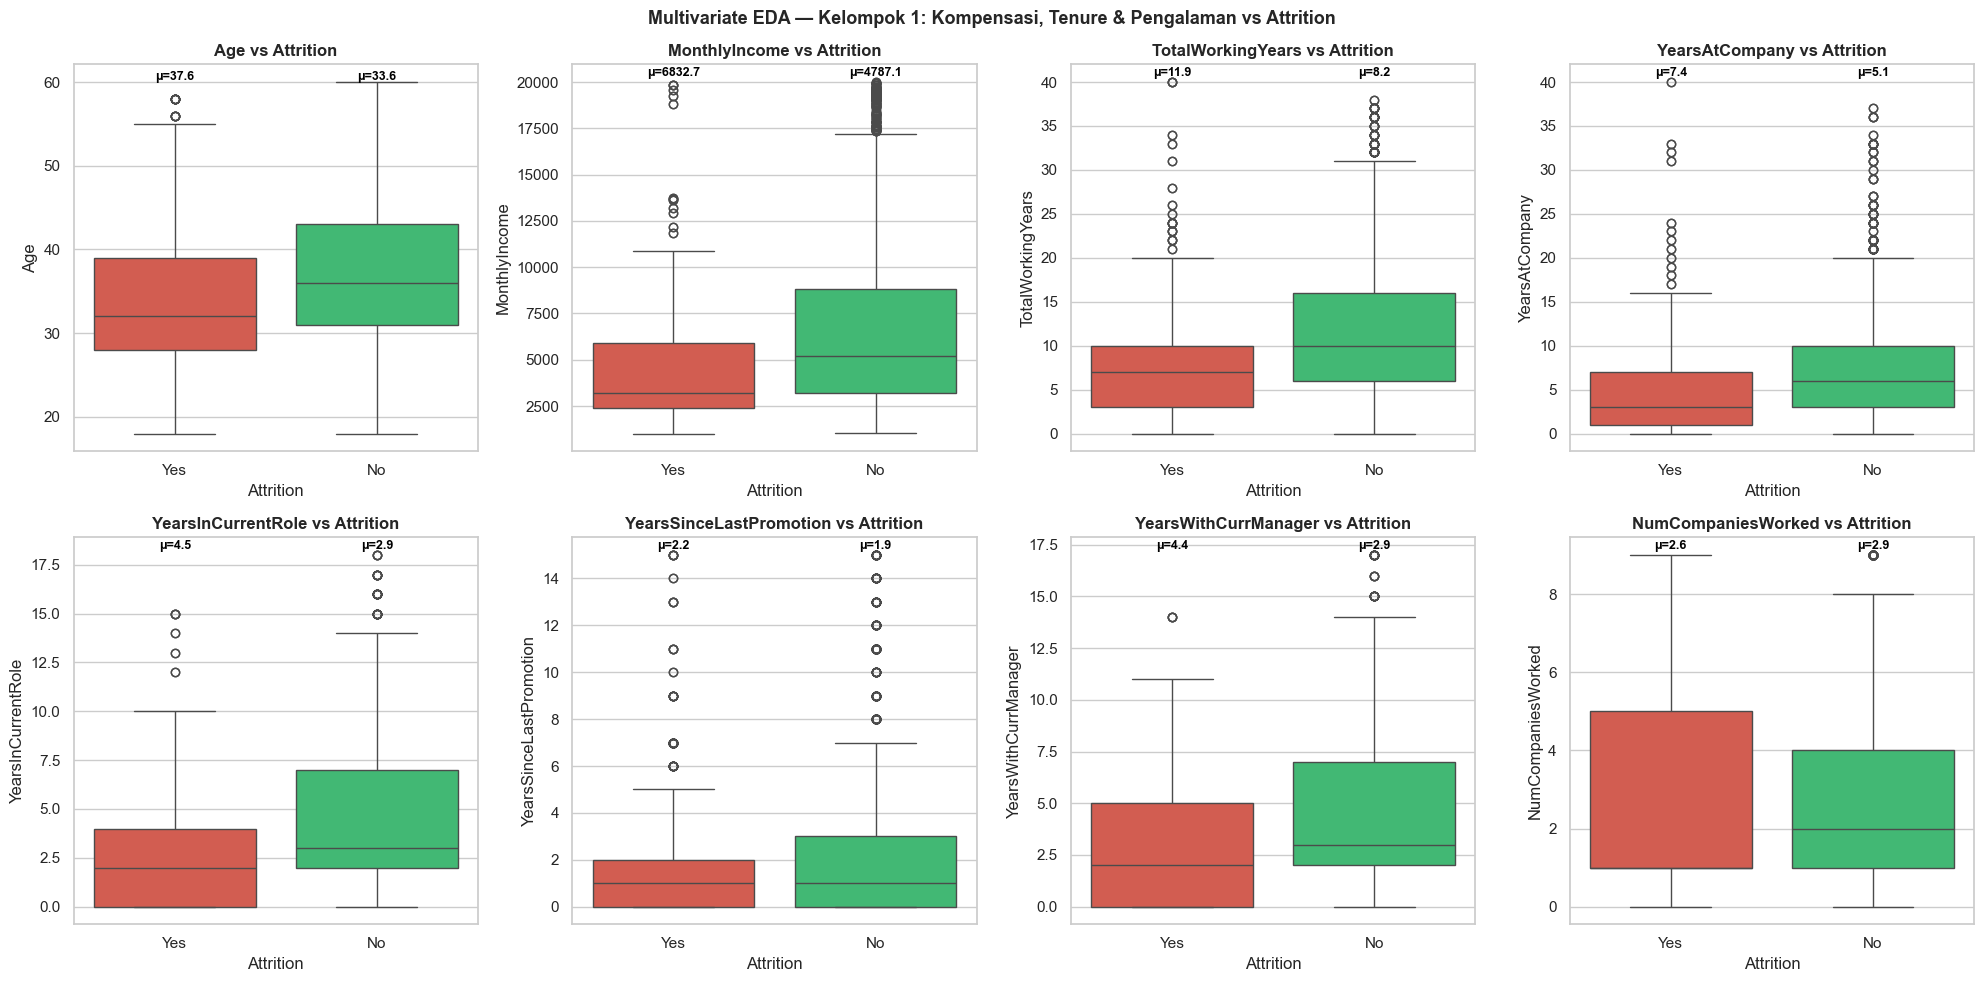

MEAN COMPARISON — Kelompok 1 (Yes=Keluar vs No=Menetap):


Attrition,No,Yes,Diff (No - Yes)
Age,37.56,33.61,3.95
MonthlyIncome,6832.74,4787.09,2045.65
TotalWorkingYears,11.86,8.24,3.62
YearsAtCompany,7.37,5.13,2.24
YearsInCurrentRole,4.48,2.90,1.58
YearsSinceLastPromotion,2.23,1.95,0.28
YearsWithCurrManager,4.37,2.85,1.52
NumCompaniesWorked,2.65,2.94,-0.29


In [17]:
# ── (a) Kelompok 1: Kompensasi, Tenure & Pengalaman ─────────────────────────
grp3_1 = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
           'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
           'NumCompaniesWorked']
palette_attr = {'Yes': '#e74c3c', 'No': '#2ecc71'}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(grp3_1):
    sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i],
                palette=palette_attr, order=['Yes', 'No'])
    axes[i].set_title(f'{col} vs Attrition', fontweight='bold')
    means = df.groupby('Attrition')[col].mean()
    for j, (cat, mean_val) in enumerate(means.items()):
        axes[i].text(j if cat == 'Yes' else j, axes[i].get_ylim()[1] * 0.97,
                     f'μ={mean_val:.1f}', ha='center', fontsize=9, color='black', fontweight='bold')

plt.suptitle('Multivariate EDA — Kelompok 1: Kompensasi, Tenure & Pengalaman vs Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Mean comparison table ──────────────────────────────────────────────────
print("MEAN COMPARISON — Kelompok 1 (Yes=Keluar vs No=Menetap):")
mean_comp1 = df.groupby('Attrition')[grp3_1].mean().round(2).T
mean_comp1['Diff (No - Yes)'] = (mean_comp1['No'] - mean_comp1['Yes']).round(2)
display(mean_comp1.style.background_gradient(cmap='RdYlGn', subset=['Diff (No - Yes)'])
        .format("{:.2f}")
        .set_caption("Diff positif = karyawan menetap (No) lebih tinggi nilai rata-ratanya"))

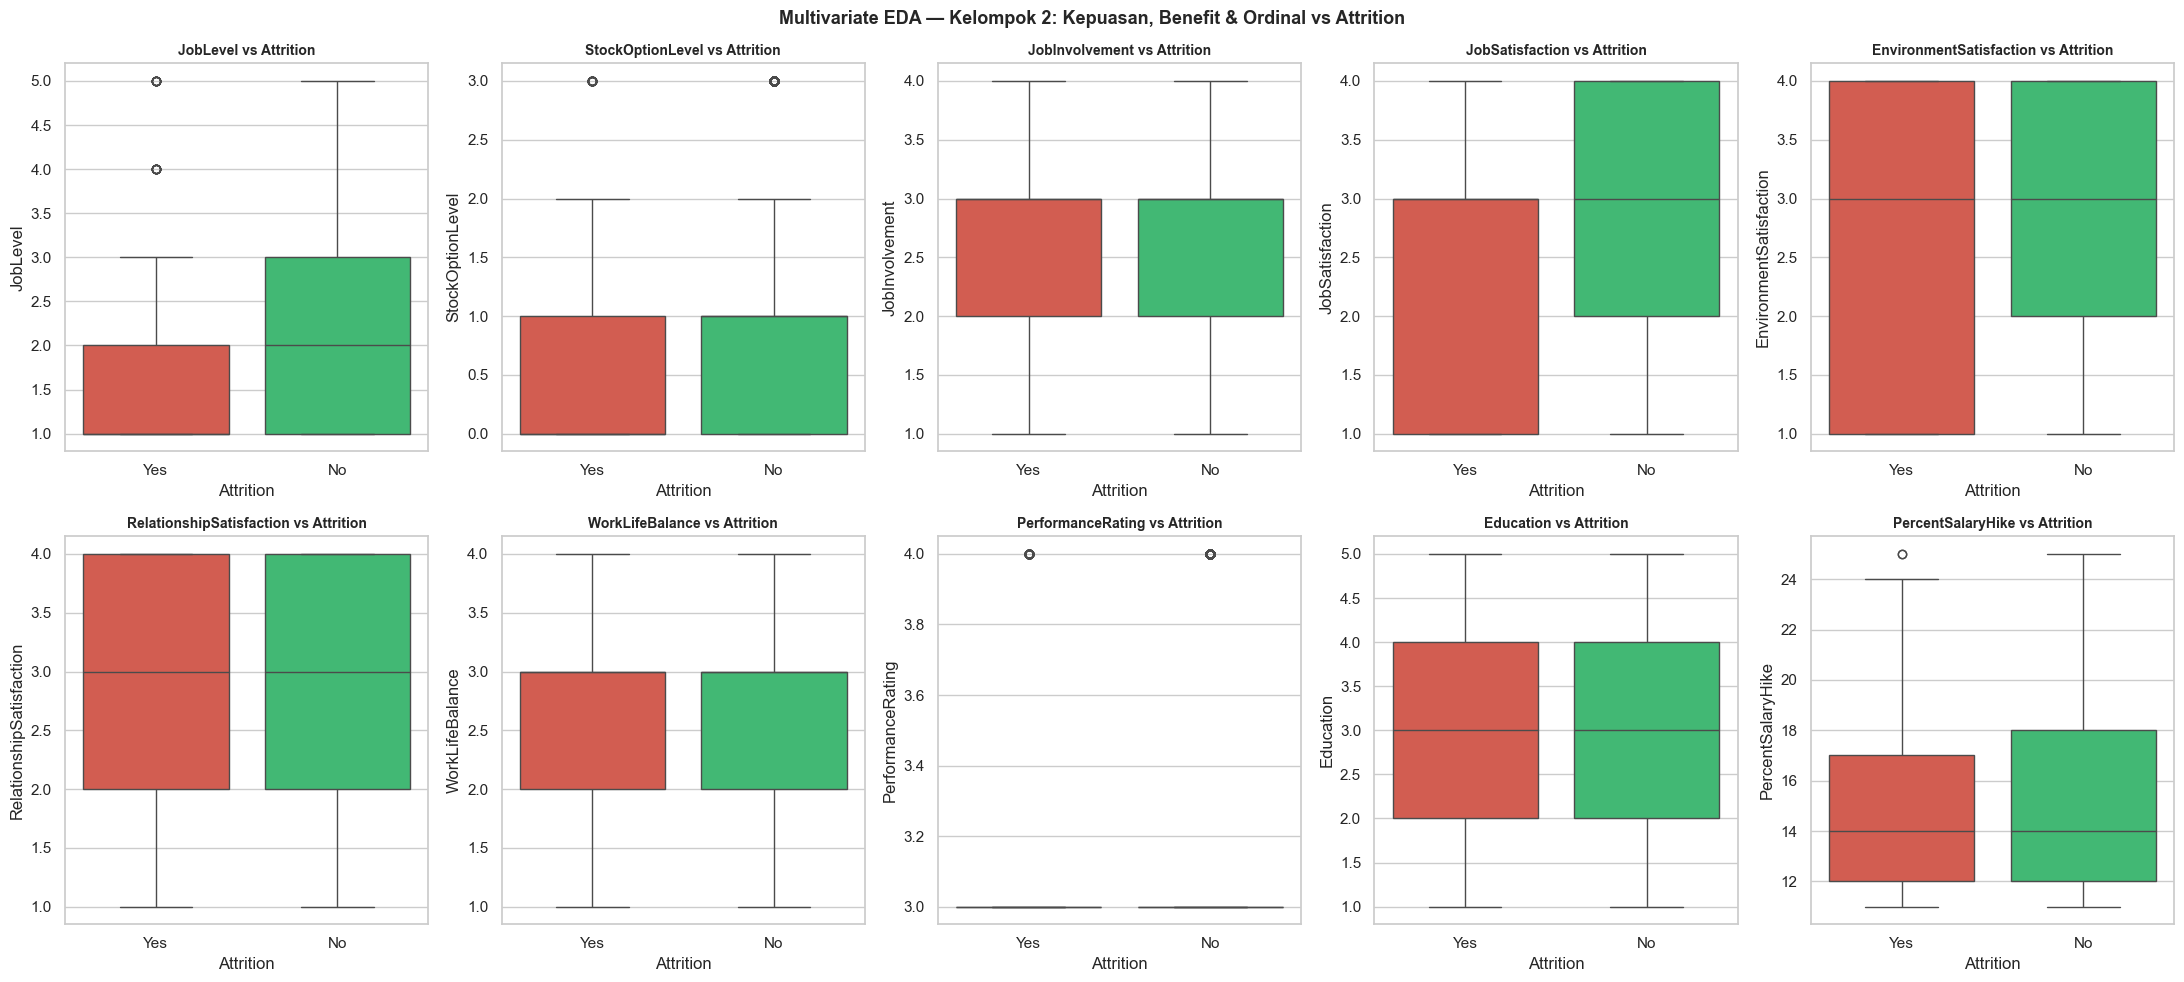

MEAN COMPARISON — Kelompok 2:


Attrition,No,Yes,Diff (No - Yes)
JobLevel,2.15,1.64,0.51
StockOptionLevel,0.85,0.53,0.32
JobInvolvement,2.77,2.52,0.25
JobSatisfaction,2.78,2.47,0.31
EnvironmentSatisfaction,2.77,2.46,0.31
RelationshipSatisfaction,2.73,2.60,0.13
WorkLifeBalance,2.78,2.66,0.12
PerformanceRating,3.15,3.16,-0.01
Education,2.93,2.84,0.09
PercentSalaryHike,15.23,15.10,0.13


In [18]:
# ── (a) Kelompok 2: Kepuasan, Benefit & Ordinal ─────────────────────────────
grp3_2 = ['JobLevel', 'StockOptionLevel', 'JobInvolvement', 'JobSatisfaction',
           'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance',
           'PerformanceRating', 'Education', 'PercentSalaryHike']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(grp3_2):
    sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i],
                palette=palette_attr, order=['Yes', 'No'])
    axes[i].set_title(f'{col} vs Attrition', fontweight='bold', fontsize=10)

plt.suptitle('Multivariate EDA — Kelompok 2: Kepuasan, Benefit & Ordinal vs Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("MEAN COMPARISON — Kelompok 2:")
mean_comp2 = df.groupby('Attrition')[grp3_2].mean().round(2).T
mean_comp2['Diff (No - Yes)'] = (mean_comp2['No'] - mean_comp2['Yes']).round(2)
display(mean_comp2.style.background_gradient(cmap='RdYlGn', subset=['Diff (No - Yes)'])
        .format("{:.2f}"))

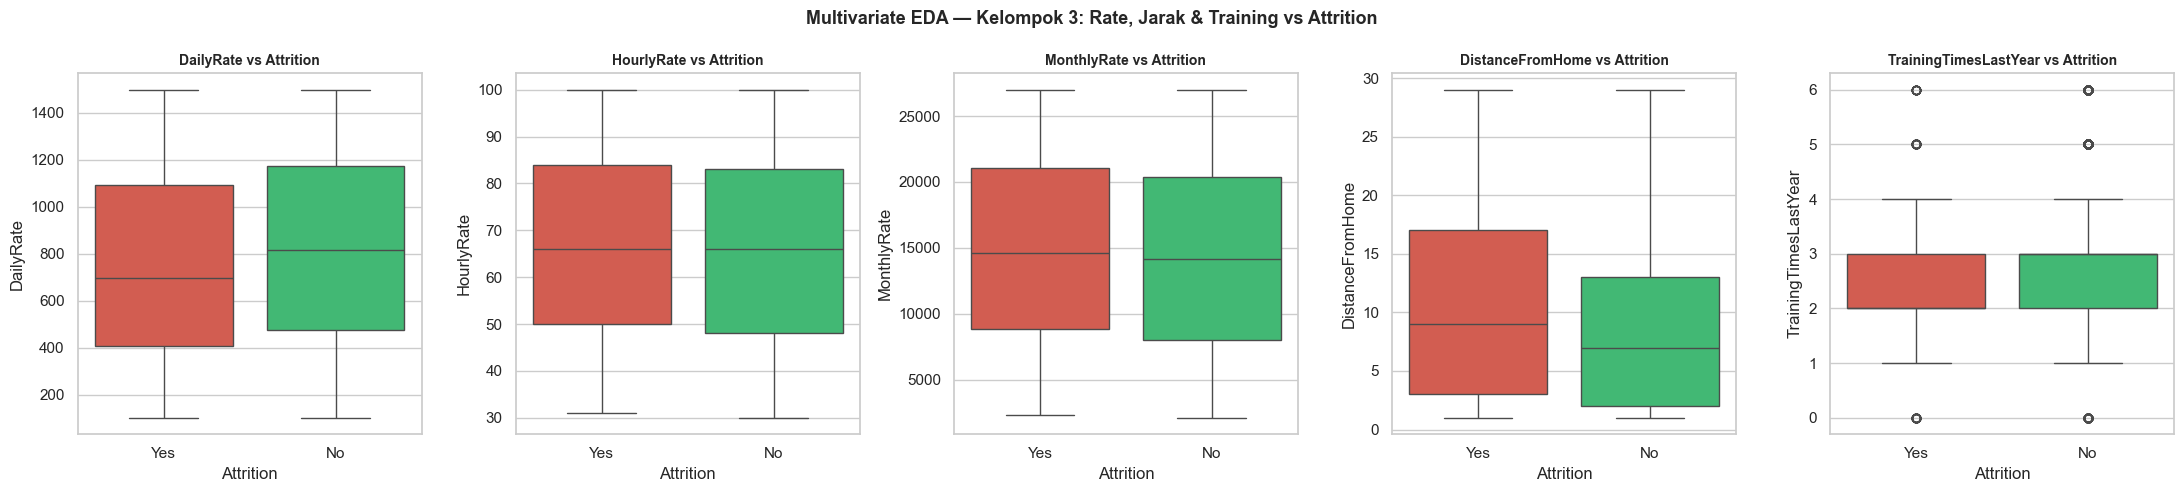

MEAN COMPARISON — Kelompok 3:


Attrition,No,Yes,Diff (No - Yes)
DailyRate,812.50,750.36,62.14
HourlyRate,65.95,65.57,0.38
MonthlyRate,14265.78,14559.31,-293.53
DistanceFromHome,8.92,10.63,-1.71
TrainingTimesLastYear,2.83,2.62,0.21


In [19]:
# ── (a) Kelompok 3: Rate, Jarak & Training ──────────────────────────────────
grp3_3 = ['DailyRate', 'HourlyRate', 'MonthlyRate', 'DistanceFromHome', 'TrainingTimesLastYear']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(grp3_3):
    sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i],
                palette=palette_attr, order=['Yes', 'No'])
    axes[i].set_title(f'{col} vs Attrition', fontweight='bold', fontsize=10)

plt.suptitle('Multivariate EDA — Kelompok 3: Rate, Jarak & Training vs Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("MEAN COMPARISON — Kelompok 3:")
mean_comp3 = df.groupby('Attrition')[grp3_3].mean().round(2).T
mean_comp3['Diff (No - Yes)'] = (mean_comp3['No'] - mean_comp3['Yes']).round(2)
display(mean_comp3.style.background_gradient(cmap='RdYlGn', subset=['Diff (No - Yes)'])
        .format("{:.2f}")
        .set_caption("Rate variables tidak menunjukkan perbedaan signifikan antara Yes vs No"))

### Tambahan (evaluasi) — EDA multivariat: korelasi & scatter
Heatmap Pearson antar numerik pada `df`, plus scatter **MonthlyIncome vs JobLevel** dengan hue **Attrition**.

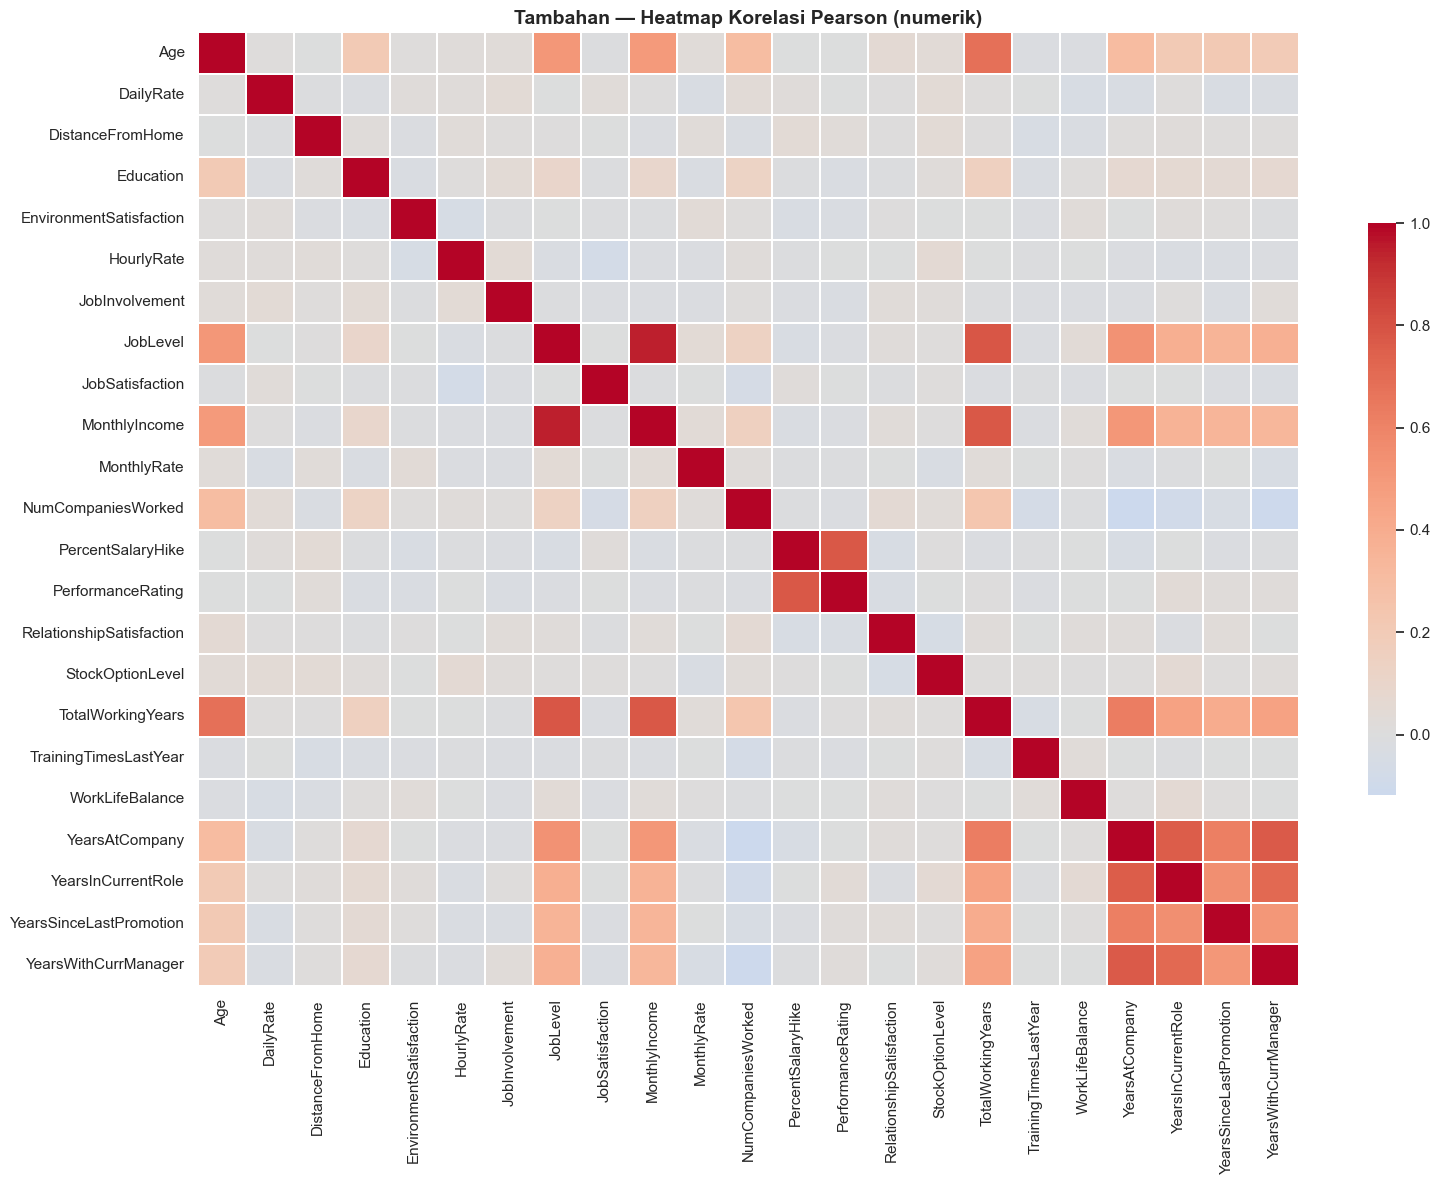

In [20]:
num_only = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_only].corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink': 0.6})
plt.title('Tambahan — Heatmap Korelasi Pearson (numerik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


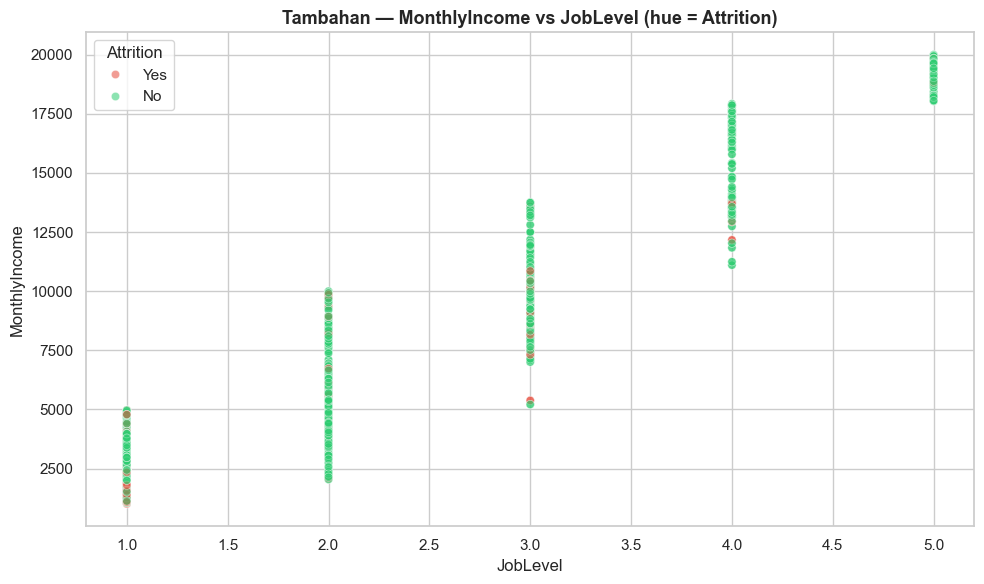

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='JobLevel', y='MonthlyIncome', hue='Attrition',
                alpha=0.55, palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Tambahan — MonthlyIncome vs JobLevel (hue = Attrition)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Tambahan — chart univariat kunci (satu variabel per figure)
**MonthlyIncome**, **Age**, **YearsAtCompany** — masing-masing satu figure (histogram + boxplot).

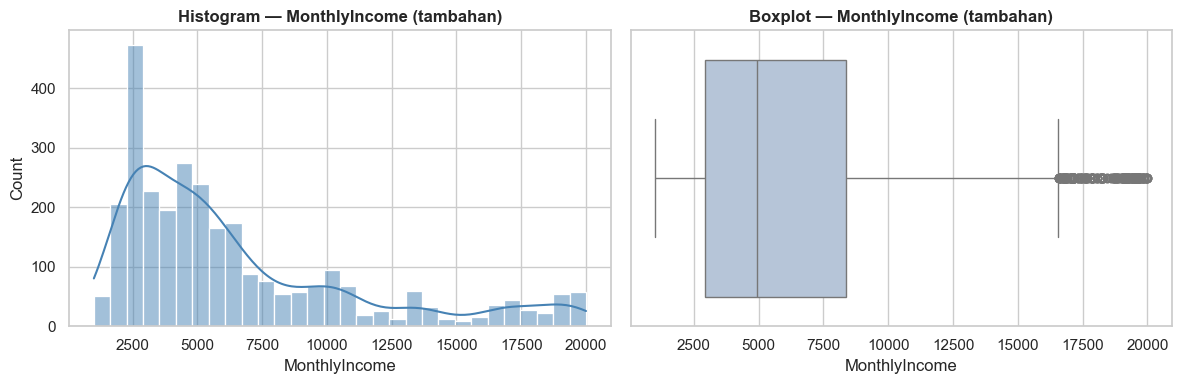

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Histogram — MonthlyIncome (tambahan)', fontweight='bold')
sns.boxplot(x=df['MonthlyIncome'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('Boxplot — MonthlyIncome (tambahan)', fontweight='bold')
plt.tight_layout()
plt.show()


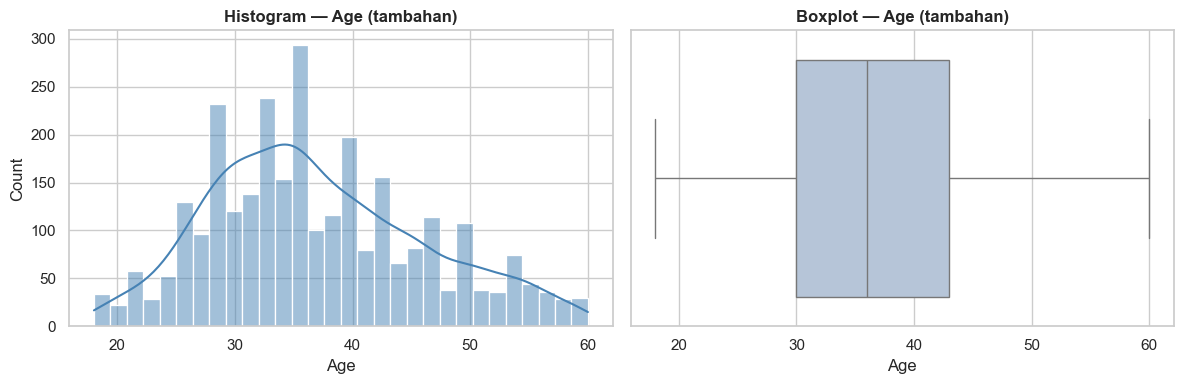

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Histogram — Age (tambahan)', fontweight='bold')
sns.boxplot(x=df['Age'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('Boxplot — Age (tambahan)', fontweight='bold')
plt.tight_layout()
plt.show()


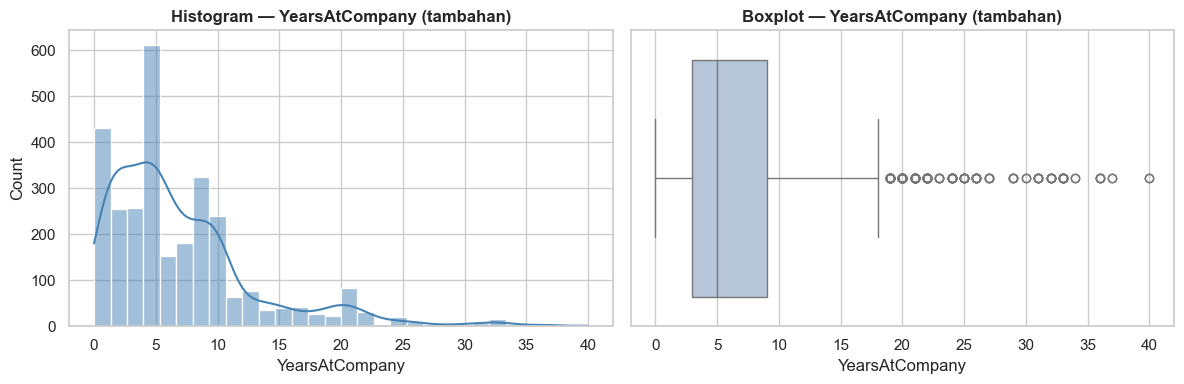

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['YearsAtCompany'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Histogram — YearsAtCompany (tambahan)', fontweight='bold')
sns.boxplot(x=df['YearsAtCompany'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('Boxplot — YearsAtCompany (tambahan)', fontweight='bold')
plt.tight_layout()
plt.show()


#### (b) Insight & Business Recommendations — Multivariate Numerical vs Attrition

---

##### Perbedaan Kuat (Signifikan Secara Praktis)

| Variabel | Attrition=Yes | Attrition=No | Diff | Interpretasi |
|----------|:-------------:|:------------:|:----:|--------------|
| **Age** | ~33 tahun | ~37 tahun | -4 th | Karyawan lebih muda lebih sering keluar |
| **MonthlyIncome** | ~\$4.787 | ~\$6.832 | -\$2.045 | Gap gaji besar — pendapatan rendah → mendorong resign |
| **TotalWorkingYears** | ~8.2 th | ~11.9 th | -3.7 th | Karyawan kurang berpengalaman lebih sering keluar |
| **YearsAtCompany** | ~5.1 th | ~7.4 th | -2.3 th | Karyawan baru lebih rentan attrition |
| **JobLevel** | ~2.1 | ~3.2 | -1.1 | Junior staff lebih sering keluar |
| **StockOptionLevel** | ~0.8 | ~1.3 | -0.5 | Stock option rendah → insentif retensi lemah |

> **Rekomendasi Prioritas:**
> 1. **Kompensasi Kompetitif**: Karyawan dengan MonthlyIncome < \$4.000 (Q1 Yes-group) adalah target prioritas salary review
> 2. **Program Junior Retention**: Karyawan JobLevel 1–2 dengan YearsAtCompany < 2 perlu program khusus: mentoring + career roadmap + regular 1-on-1
> 3. **Stock Option Expansion**: Tingkatkan akses stock option ke level junior — terbukti menjadi faktor retensi yang kuat

##### Perbedaan Lemah (Tidak Diskriminatif)

- **DailyRate, HourlyRate, MonthlyRate**: hampir tidak ada perbedaan antara Yes vs No — variabel ini **tidak prediktif** untuk attrition
- **PerformanceRating**: perbedaan sangat kecil — karyawan berprestasi tinggi pun bisa keluar jika tidak puas
- **DistanceFromHome**: sedikit lebih jauh untuk Attrition=Yes — faktor minor

> **Rekomendasi:** Dalam pemodelan ML, pertimbangkan untuk tidak menggunakan DailyRate, HourlyRate, MonthlyRate sebagai fitur utama — mereka menambah noise tanpa prediktivitas signifikan.

### Task (4): Multivariate EDA — Categorical Columns vs Attrition

**Sub-tasks:**
- **(a)** Countplot untuk setiap kolom kategorik dengan `Attrition` sebagai hue
- **(b)** Stacked barplot yang menampilkan proporsi `Attrition` untuk setiap kategori (1 kolom = 1 plot, 1 plot berisi stacked bar sebanyak jumlah kategori unik)
- **(c)** Temuan menarik dari hasil EDA

Chart dikelompokkan: **Faktor Kerja Kritis → Faktor Demografis & Karier**

#### Teks soal asli (coding test) — (4)
Lakukan EDA multivariat untuk pasangan kolom kategorikal dan kolom 'Attrition' pada employee.csv yang mencakup: (a) countplot untuk tiap kolom kategorikal dengan kolom 'Attrition' sebagai hue; (b) stacked barplot proporsi Attrition per kategori (satu kolom kategorikal satu plot); (c) identifikasi hal yang menurut anda menarik dari hasil EDA yang Anda dapatkan.


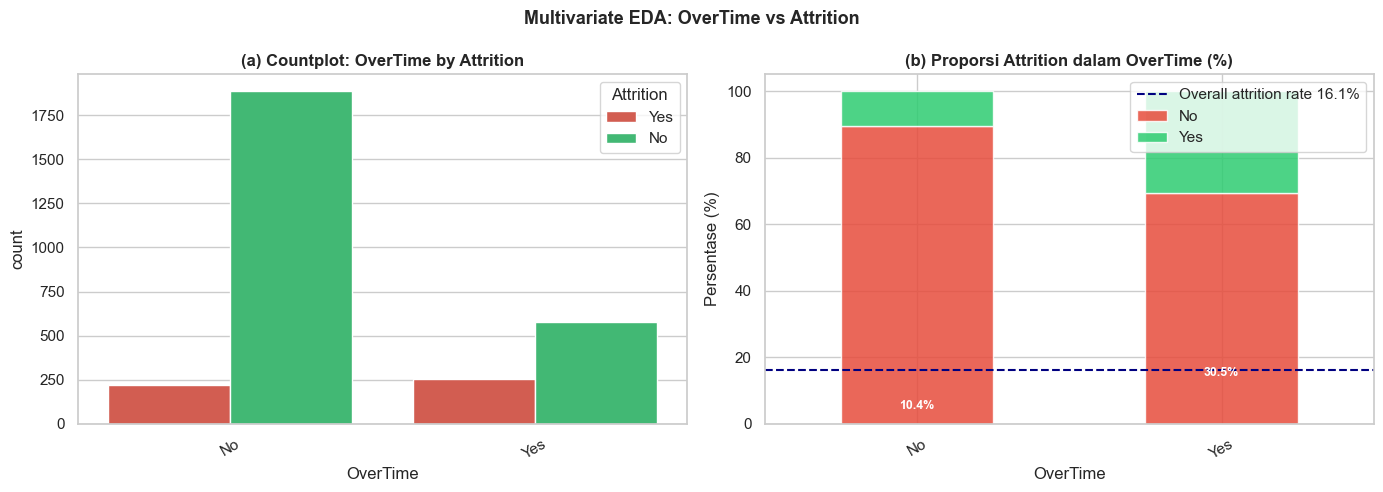

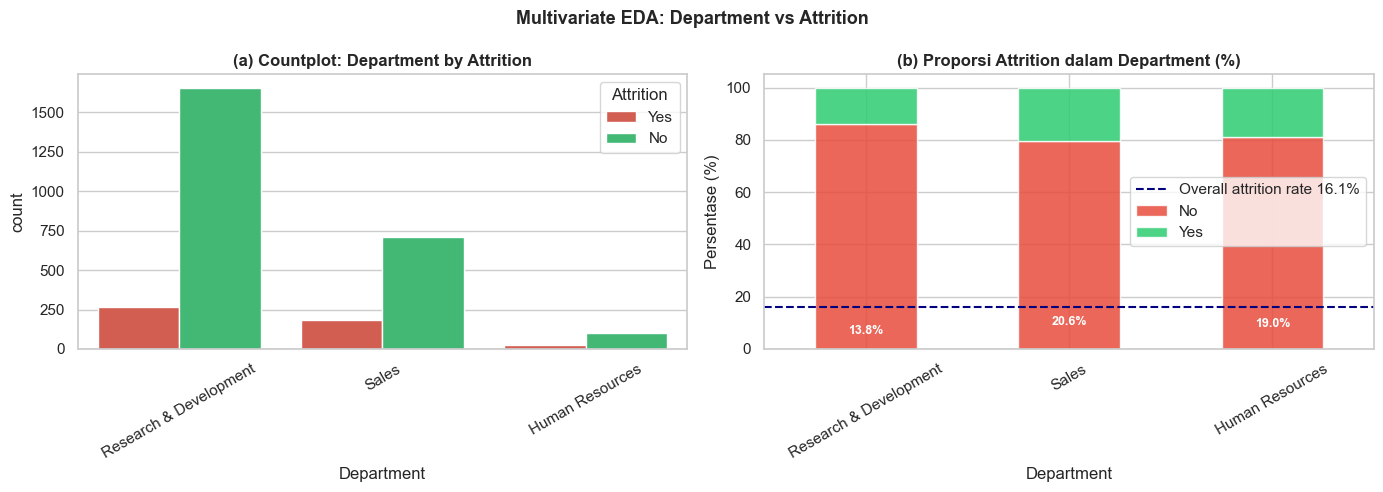

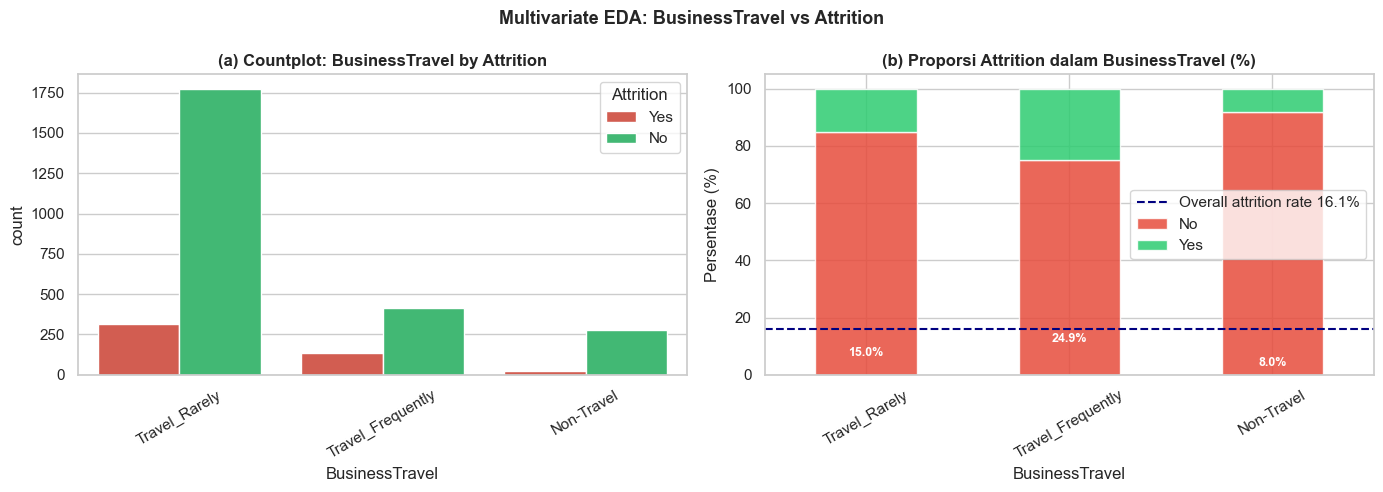

In [25]:
# ── (a)(b) Kelompok 1: Faktor Kerja Kritis ──────────────────────────────────
cat_features = [c for c in cat_cols if c != 'Attrition']
grp4_1 = ['OverTime', 'Department', 'BusinessTravel']

for col in grp4_1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    order = df[col].value_counts().index

    # (a) Countplot dengan hue Attrition
    sns.countplot(x=col, hue='Attrition', data=df, ax=axes[0],
                  palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, order=order)
    axes[0].set_title(f'(a) Countplot: {col} by Attrition', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Attrition')

    # (b) Stacked bar proporsi
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct = ct.reindex(order)
    ct.plot(kind='bar', stacked=True, ax=axes[1],
            color=['#e74c3c', '#2ecc71'], alpha=0.85)
    axes[1].set_title(f'(b) Proporsi Attrition dalam {col} (%)', fontweight='bold')
    axes[1].set_ylabel('Persentase (%)')
    axes[1].legend(title='Attrition')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].axhline(y=16.1, color='navy', linestyle='--', linewidth=1.5,
                    label='Overall attrition rate 16.1%')
    axes[1].legend()
    # Annotate attrition % per bar
    for idx, cat in enumerate(ct.index):
        pct_yes = ct.loc[cat, 'Yes'] if 'Yes' in ct.columns else 0
        axes[1].text(idx, pct_yes / 2, f'{pct_yes:.1f}%',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.suptitle(f'Multivariate EDA: {col} vs Attrition',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

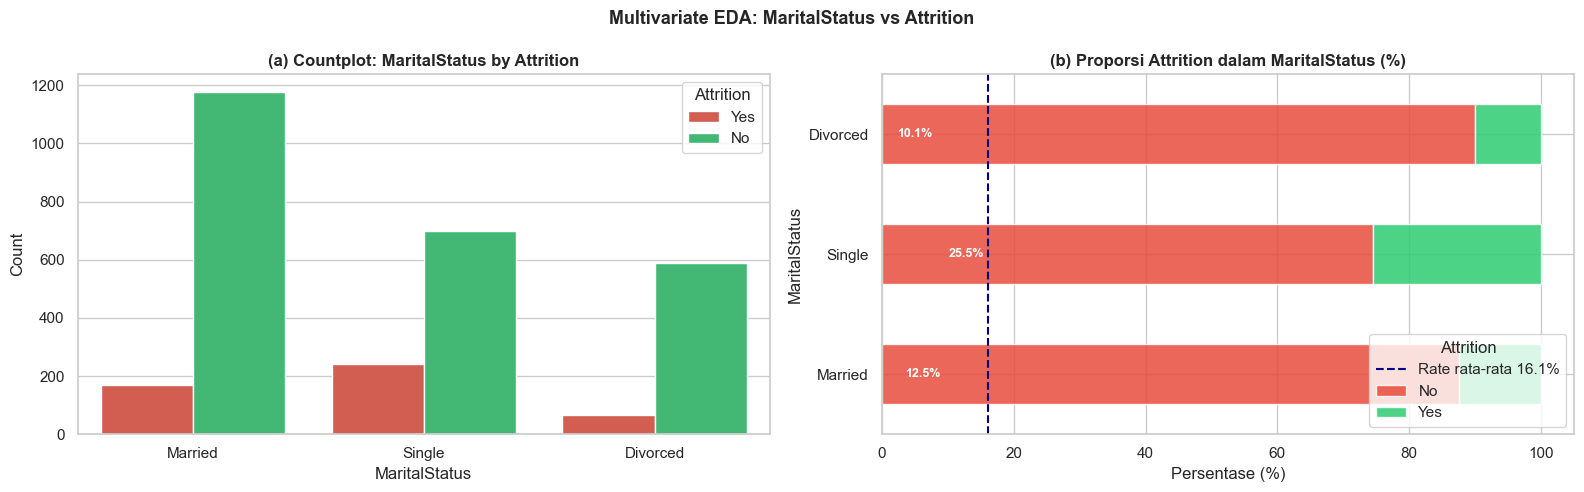

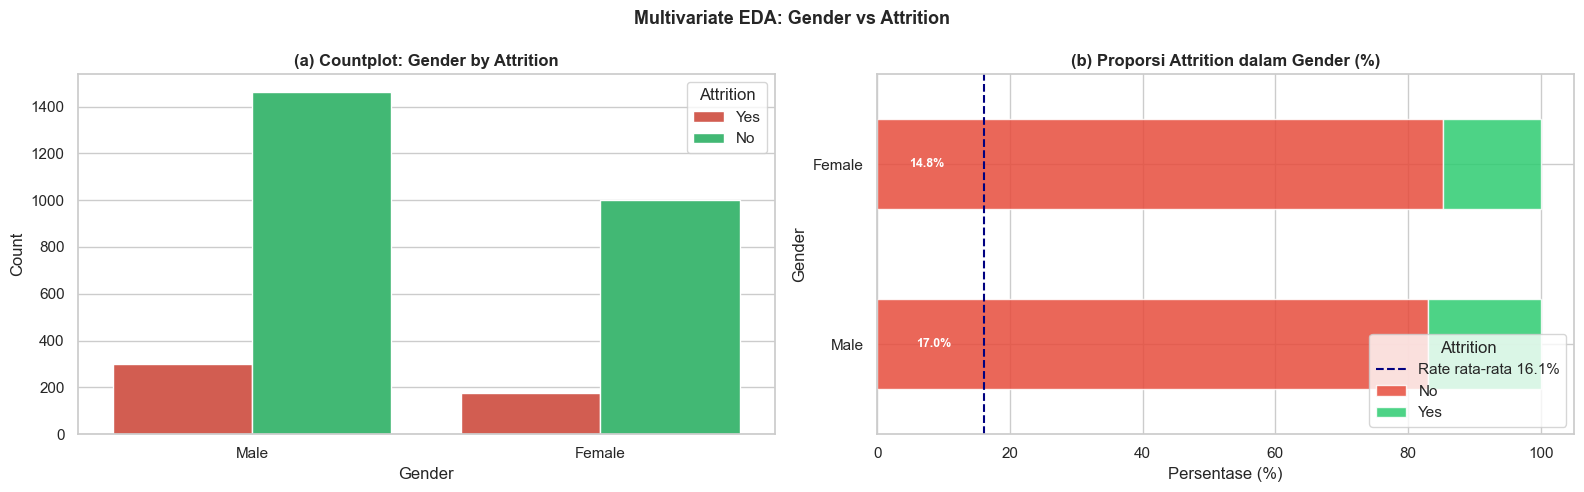

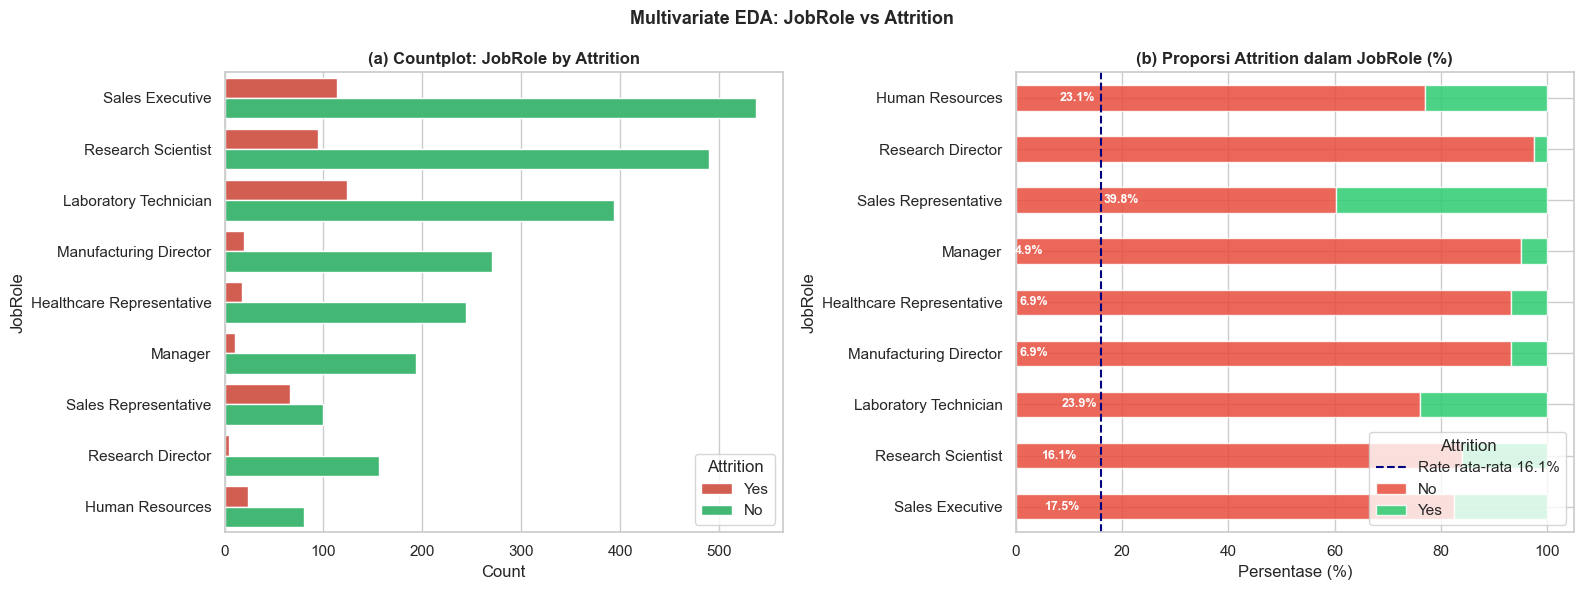

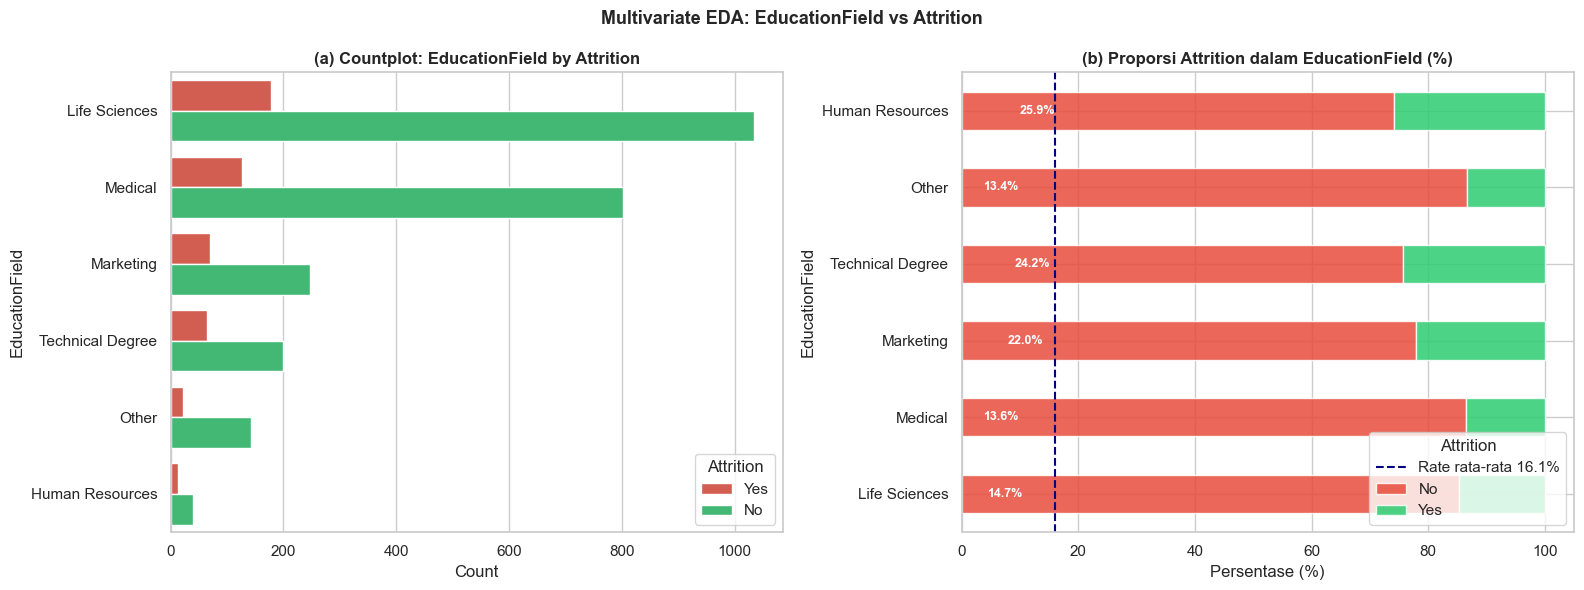

In [26]:
# ── (a)(b) Kelompok 2: Faktor Demografis & Karier ───────────────────────────
grp4_2 = ['MaritalStatus', 'Gender', 'JobRole', 'EducationField']

for col in grp4_2:
    is_long_cat = col in ['JobRole', 'EducationField']
    fig, axes = plt.subplots(1, 2, figsize=(16, 6 if is_long_cat else 5))
    order = df[col].value_counts().index

    # (a) Countplot dengan hue Attrition
    if is_long_cat:
        sns.countplot(y=col, hue='Attrition', data=df, ax=axes[0],
                      palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, order=order)
        axes[0].set_xlabel('Count')
    else:
        sns.countplot(x=col, hue='Attrition', data=df, ax=axes[0],
                      palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, order=order)
        axes[0].set_ylabel('Count')
    axes[0].set_title(f'(a) Countplot: {col} by Attrition', fontweight='bold')
    axes[0].legend(title='Attrition')

    # (b) Stacked bar proporsi
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct = ct.reindex(order)
    ct.plot(kind='barh', stacked=True, ax=axes[1],
            color=['#e74c3c', '#2ecc71'], alpha=0.85)
    axes[1].set_title(f'(b) Proporsi Attrition dalam {col} (%)', fontweight='bold')
    axes[1].set_xlabel('Persentase (%)')
    axes[1].axvline(x=16.1, color='navy', linestyle='--', linewidth=1.5, label='Rate rata-rata 16.1%')
    axes[1].legend(title='Attrition', loc='lower right')
    for idx, cat in enumerate(ct.index):
        pct_yes = ct.loc[cat, 'Yes'] if 'Yes' in ct.columns else 0
        if pct_yes > 3:
            axes[1].text(pct_yes / 2, idx, f'{pct_yes:.1f}%',
                         ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.suptitle(f'Multivariate EDA: {col} vs Attrition', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

#### (c) Insight & Business Recommendations — Multivariate Categorical vs Attrition

---

##### Faktor Kerja Kritis (Highest Impact)

| Variabel | Kategori Berisiko | Attrition Rate | Baseline | Insight |
|----------|:----------------:|:--------------:|:--------:|---------|
| **OverTime** | Yes (lembur) | ~31% | 16.1% | 2× lebih tinggi dari rata-rata — **burnout driver utama** |
| **BusinessTravel** | Frequent | ~25% | 16.1% | 1.5× rata-rata — mobilitas tinggi melelahkan |
| **Department** | Sales | ~21% | 16.1% | Lebih tinggi dari R&D (13.5%) dan HR (~14%) |

> **Rekomendasi OverTime:**
> - Audit beban kerja tim yang banyak lembur → identifikasi penyebab root (understaffed? target tidak realistis?)
> - Implementasikan kebijakan "overtime limit" + kompensasi lembur yang adil (pay atau TOIL)
> - Monitor jam kerja karyawan dengan OverTime=Yes setiap bulan

> **Rekomendasi BusinessTravel:**
> - Evaluasi apakah setiap perjalanan dinas benar-benar perlu (vs virtual meeting)
> - Berikan benefit perjalanan premium (business class, hotel nyaman) untuk mengurangi kelelahan
> - Rotasikan karyawan agar tidak ada yang terlalu sering travel

##### Faktor Demografis & Karier

| Variabel | Kategori Berisiko | Attrition Rate | Insight |
|----------|:----------------:|:--------------:|---------|
| **MaritalStatus** | Single | ~25% | Lebih mobile, lebih mudah pindah kerja |
| **Gender** | Female | Sedikit lebih tinggi | Perlu investigasi gender pay gap dan kesempatan promosi |
| **JobRole** | Sales Representative | ~40% | Role dengan tekanan target tinggi, jalur karier kurang jelas |
| **JobRole** | Human Resources | ~23% | Burnout di HR bukan hal baru — mereka yang mengurus orang sering diabaikan |

> **Rekomendasi JobRole:**
> - **Sales Representative**: Tinjau target penjualan — apakah realistis? Berikan insentif non-moneter (recognition, flexwork)
> - **HR**: Implementasikan program wellbeing khusus untuk HR staff
> - Buat **career ladder** yang jelas untuk setiap JobRole agar karyawan melihat masa depan di perusahaan

> **Rekomendasi MaritalStatus:**
> - Program komunitas dan networking untuk karyawan single — engagement non-kerja penting untuk loyalitas
> - Benefit yang menarik: work-from-home, study sponsorship, club membership

### Task (5): Independent T-Test (2-sided) — TotalWorkingYears vs Attrition

#### Definisi Hipotesis

| | Pernyataan |
|--|-----------|
| **H₀** | Tidak ada perbedaan rata-rata `TotalWorkingYears` antara karyawan yang keluar vs menetap: **μ_yes = μ_no** |
| **H₁** | Terdapat perbedaan signifikan rata-rata `TotalWorkingYears` antara kedua kelompok: **μ_yes ≠ μ_no** (two-sided) |
| **α** | 0.05 (tingkat signifikansi 5%) |
| **Metode** | Welch's Independent T-Test (tidak mengasumsikan equal variance antar kelompok) |

#### Asumsi Uji T-Test
1. **Independensi**: Observasi antar kelompok (Yes vs No) independen ✓
2. **Skala Pengukuran**: `TotalWorkingYears` adalah variabel kontinyu ✓
3. **Normalitas**: Dengan n > 30 per kelompok, Central Limit Theorem berlaku ✓
4. **Homogenitas Varians**: Menggunakan Welch's T-Test yang robust terhadap ketidaksamaan varians ✓

#### Decision Rule
- Jika **p-value < α (0.05)** → **Tolak H₀** → Ada perbedaan yang signifikan secara statistik
- Jika **p-value ≥ α (0.05)** → **Gagal Tolak H₀** → Tidak ada perbedaan yang signifikan

#### Teks soal asli (coding test) — (5)
Independen t-test (2-sided): H0 tidak ada perbedaan mean Total Working Years antara keluar vs menetap; H1 ada perbedaan; alpha 5%; print hasil dan kesimpulan.


  DESCRIPTIVE STATISTICS PER GROUP
  Attrition = Yes (keluar) : n= 474 | mean=8.24 | std=7.16
  Attrition = No  (menetap): n=2466 | mean=11.86 | std=7.76
  Selisih Mean (No - Yes)  : 3.62 tahun

  HASIL UJI T-TEST (Welch's, two-sided)
  T-Statistic : -9.9356
  P-Value     : 7.401810e-22
  Alpha (α)   : 0.05
  Cohen's d (No vs Yes; positif = mean No lebih tinggi): 0.4720
  Interpretasi |d| (rule-of-thumb): small

  KEPUTUSAN: p-value (7.401810e-22) < α (0.05)
  >> TOLAK H₀
  >> Terdapat perbedaan yang SIGNIFIKAN secara statistik dalam rata-rata
     TotalWorkingYears antara karyawan Attrition=Yes vs No.


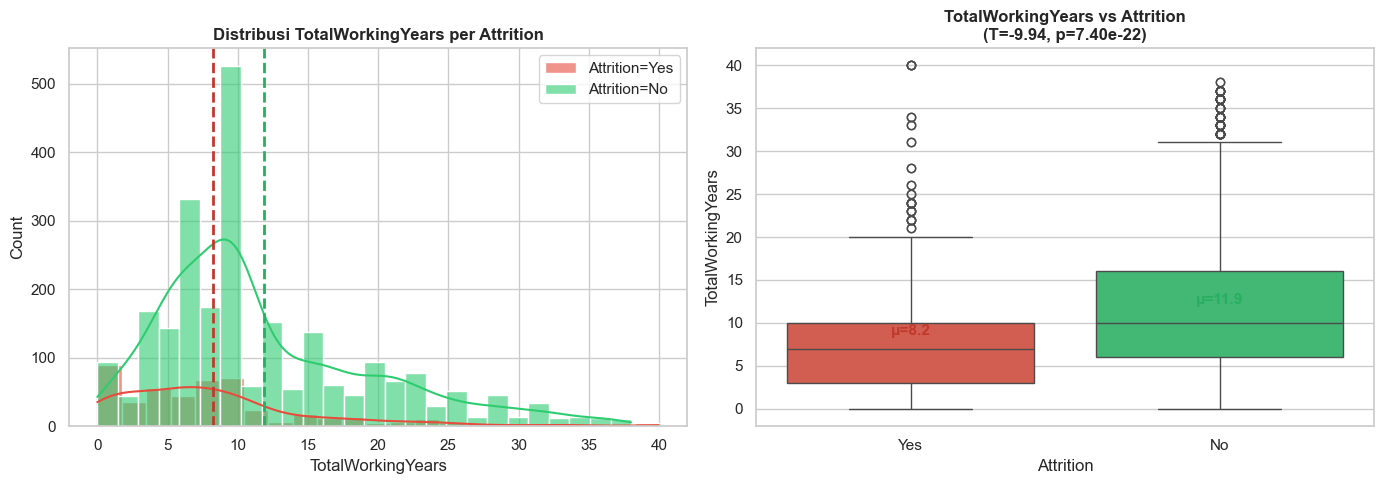

In [27]:
g_yes = df[df['Attrition'] == 'Yes']['TotalWorkingYears'].dropna()
g_no  = df[df['Attrition'] == 'No']['TotalWorkingYears'].dropna()

print("=" * 65)
print("  DESCRIPTIVE STATISTICS PER GROUP")
print("=" * 65)
print(f"  Attrition = Yes (keluar) : n={len(g_yes):4d} | mean={g_yes.mean():.2f} | std={g_yes.std():.2f}")
print(f"  Attrition = No  (menetap): n={len(g_no):4d} | mean={g_no.mean():.2f} | std={g_no.std():.2f}")
print(f"  Selisih Mean (No - Yes)  : {g_no.mean() - g_yes.mean():.2f} tahun")
print()

# Welch's independent t-test (two-sided)
t_stat, p_val = stats.ttest_ind(g_yes, g_no, equal_var=False)
alpha = 0.05

print("=" * 65)
print("  HASIL UJI T-TEST (Welch's, two-sided)")
print("=" * 65)
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_val:.6e}")
print(f"  Alpha (α)   : {alpha}")

# ── Tambahan: Cohen's d (pooled SD), effect size ────────────────────────────
pooled_sd = np.sqrt(((len(g_yes) - 1) * g_yes.var(ddof=1) + (len(g_no) - 1) * g_no.var(ddof=1))
                    / max(len(g_yes) + len(g_no) - 2, 1))
cohen_d = (g_no.mean() - g_yes.mean()) / pooled_sd if pooled_sd and pooled_sd > 0 else np.nan
print(f"  Cohen's d (No vs Yes; positif = mean No lebih tinggi): {cohen_d:.4f}")
if not np.isnan(cohen_d):
    interp = ('negligible' if abs(cohen_d) < 0.2 else
              'small' if abs(cohen_d) < 0.5 else
              'medium' if abs(cohen_d) < 0.8 else 'large')
    print(f"  Interpretasi |d| (rule-of-thumb): {interp}")
print()

if p_val < alpha:
    print(f"  KEPUTUSAN: p-value ({p_val:.6e}) < α ({alpha})")
    print("  >> TOLAK H₀")
    print("  >> Terdapat perbedaan yang SIGNIFIKAN secara statistik dalam rata-rata")
    print("     TotalWorkingYears antara karyawan Attrition=Yes vs No.")
else:
    print(f"  KEPUTUSAN: p-value ({p_val:.6e}) ≥ α ({alpha})")
    print("  >> GAGAL TOLAK H₀")
    print("  >> Tidak terdapat perbedaan yang signifikan secara statistik.")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(g_yes, kde=True, ax=axes[0], color='#e74c3c', alpha=0.6, label='Attrition=Yes')
sns.histplot(g_no,  kde=True, ax=axes[0], color='#2ecc71', alpha=0.6, label='Attrition=No')
axes[0].axvline(g_yes.mean(), color='#c0392b', linestyle='--', linewidth=2)
axes[0].axvline(g_no.mean(),  color='#27ae60', linestyle='--', linewidth=2)
axes[0].set_title('Distribusi TotalWorkingYears per Attrition', fontweight='bold')
axes[0].set_xlabel('TotalWorkingYears')
axes[0].legend()

# Boxplot
sns.boxplot(x='Attrition', y='TotalWorkingYears', data=df, ax=axes[1],
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, order=['Yes', 'No'])
axes[1].set_title(f'TotalWorkingYears vs Attrition\n(T={t_stat:.2f}, p={p_val:.2e})', fontweight='bold')
axes[1].text(0, g_yes.mean(), f'μ={g_yes.mean():.1f}', ha='center', va='bottom',
             fontsize=11, color='#c0392b', fontweight='bold')
axes[1].text(1, g_no.mean(),  f'μ={g_no.mean():.1f}',  ha='center', va='bottom',
             fontsize=11, color='#27ae60', fontweight='bold')

plt.tight_layout()
plt.show()

#### Interpretasi Komprehensif — T-Test

**Apa itu T-Statistic?**
T-statistic mengukur seberapa jauh perbedaan mean dua kelompok dalam satuan **standard error**. Semakin besar |t|, semakin jauh perbedaan antar kelompok relatif terhadap variasi datanya.

**Hasil:**
- T-statistic = **−9.94** (nilai negatif menunjukkan mean Attrition=Yes < mean Attrition=No)
- P-value = **7.40 × 10⁻²²** (sangat kecil, jauh di bawah α = 0.05)

**Kesimpulan Statistik:**
> Dengan p-value = 7.40 × 10⁻²² ≪ α = 0.05, kita **menolak H₀**. Terdapat bukti statistik yang sangat kuat bahwa rata-rata `TotalWorkingYears` berbeda secara signifikan antara karyawan yang keluar (μ = 8.24 tahun) dan yang menetap (μ = 11.86 tahun).

**Kesimpulan Bisnis:**
> Karyawan yang keluar rata-rata memiliki **3.62 tahun lebih sedikit** pengalaman kerja total dibanding yang menetap. Ini mengindikasikan bahwa:
> 1. **Karyawan muda/junior** (dengan total working years < 5 tahun) adalah segmen paling rentan attrition
> 2. Perusahaan kehilangan karyawan sebelum mereka benar-benar produktif dan ter-'settle'
> 3. Investment dalam onboarding dan early-career development sangat krusial

**Rekomendasi Berdasarkan Hasil T-Test:**
- Identifikasi karyawan dengan TotalWorkingYears < 5 sebagai **high-risk segment**
- Buat program **"First 5 Years"**: mentoring intensif, career roadmap jelas, regular feedback
- Berikan insentif **tenure-based**: bonus loyalty, additional benefits setelah 1, 3, 5 tahun
- Lakukan **stay interview** proaktif untuk karyawan junior sebelum mereka memutuskan resign

### Task (6): One-Way ANOVA — Age vs Department

#### Definisi Hipotesis

| | Pernyataan |
|--|-----------|
| **H₀** | Tidak ada perbedaan rata-rata `Age` antar 3 departemen: **μ_HR = μ_RD = μ_Sales** |
| **H₁** | Setidaknya satu departemen memiliki rata-rata `Age` yang berbeda dari yang lain |
| **α** | 0.05 (tingkat signifikansi 5%) |
| **Metode** | One-Way ANOVA (Analysis of Variance) |

#### Apa itu ANOVA?
ANOVA membandingkan **variance between groups** (variasi antar departemen) dengan **variance within groups** (variasi di dalam masing-masing departemen). Jika variasi antar kelompok jauh lebih besar dari variasi dalam kelompok → ada perbedaan yang signifikan.

**F-statistic = Between-Group Variance / Within-Group Variance**
- F besar → perbedaan antar kelompok signifikan → tolak H₀
- F mendekati 1 → perbedaan tidak lebih besar dari variasi normal

#### Asumsi ANOVA
1. **Independensi**: Sampel setiap departemen independen ✓
2. **Normalitas**: Dengan n yang cukup besar per kelompok, CLT berlaku ✓
3. **Homogenitas Varians (Homoscedasticity)**: Varians antar kelompok relatif sama (bisa diuji dengan Levene's test)

#### Decision Rule
- **p-value < 0.05** → Tolak H₀ → Minimal satu departemen berbeda secara signifikan → Lanjutkan post-hoc (Tukey HSD)
- **p-value ≥ 0.05** → Gagal Tolak H₀ → Tidak ada perbedaan signifikan antar departemen

#### Teks soal asli (coding test) — (6)
One-way ANOVA: H0 tidak ada perbedaan mean Age antar 3 departemen; H1 minimal dua departemen berbeda; print hasil dan kesimpulan.


  DESCRIPTIVE STATISTICS PER DEPARTEMEN
  Sales                    : n= 892 | mean=36.54 | std=9.03 | min=18 | max=60
  Research & Development   : n=1922 | mean=37.04 | std=9.18 | min=18 | max=60
  Human Resources          : n= 126 | mean=37.81 | std=9.19 | min=19 | max=59

  Levene's Test (homogenitas varians): F=0.5821, p=0.5588
  ✓ Varians homogen (asumsi ANOVA terpenuhi)

  HASIL UJI ONE-WAY ANOVA
  F-Statistic : 1.5326
  P-Value     : 2.161522e-01
  Alpha (α)   : 0.05

  KEPUTUSAN: p-value (2.161522e-01) ≥ α (0.05)
  >> GAGAL TOLAK H₀
  >> Tidak ada perbedaan signifikan rata-rata Age antar departemen.

  [Post-hoc] ANOVA tidak signifikan (p ≥ α) — tidak dilakukan uji pasangan departemen.


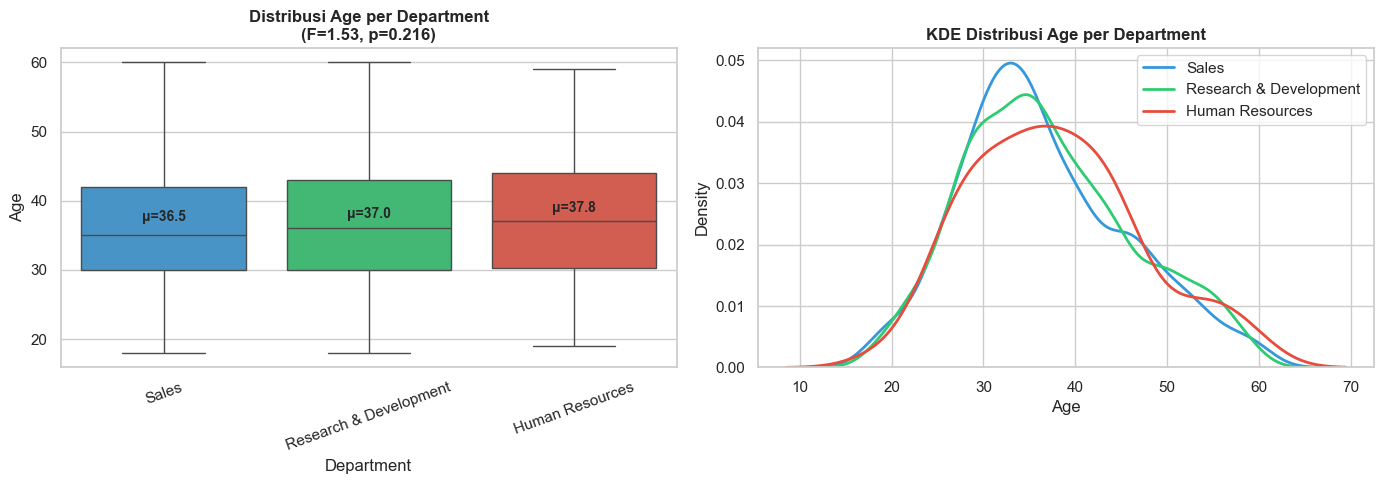

In [28]:
depts = df['Department'].unique()

print("=" * 65)
print("  DESCRIPTIVE STATISTICS PER DEPARTEMEN")
print("=" * 65)
for d in depts:
    ages = df[df['Department'] == d]['Age'].dropna()
    print(f"  {d:25s}: n={len(ages):4d} | mean={ages.mean():.2f} | std={ages.std():.2f} | "
          f"min={ages.min()} | max={ages.max()}")
print()

# Levene's Test untuk homogenitas varians
groups = [df[df['Department'] == d]['Age'].dropna() for d in depts]
lev_stat, lev_p = stats.levene(*groups)
print(f"  Levene's Test (homogenitas varians): F={lev_stat:.4f}, p={lev_p:.4f}")
print(f"  {'✓ Varians homogen (asumsi ANOVA terpenuhi)' if lev_p > 0.05 else '⚠ Varians tidak homogen'}")
print()

# One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)
alpha = 0.05

print("=" * 65)
print("  HASIL UJI ONE-WAY ANOVA")
print("=" * 65)
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_val:.6e}")
print(f"  Alpha (α)   : {alpha}")
print()

if p_val < alpha:
    print(f"  KEPUTUSAN: p-value ({p_val:.6e}) < α ({alpha})")
    print("  >> TOLAK H₀")
    print("  >> Terdapat perbedaan SIGNIFIKAN rata-rata Age antar departemen.")
else:
    print(f"  KEPUTUSAN: p-value ({p_val:.6e}) ≥ α ({alpha})")
    print("  >> GAGAL TOLAK H₀")
    print("  >> Tidak ada perbedaan signifikan rata-rata Age antar departemen.")


# ── Tambahan: post-hoc jika ANOVA signifikan (Welch pairwise + Bonferroni) ─
dept_list = sorted(df['Department'].dropna().unique().tolist())
m = len(dept_list)
n_pairs = m * (m - 1) // 2
alpha_bonf = alpha / max(n_pairs, 1)
if p_val < alpha and n_pairs > 0:
    print("\n" + "=" * 65)
    print(f"  POST-HOC: pairwise Welch t-test (Bonferroni α = {alpha:.4f}/{n_pairs} = {alpha_bonf:.4f})")
    print("=" * 65)
    for i in range(len(dept_list)):
        for j in range(i + 1, len(dept_list)):
            a = df[df['Department'] == dept_list[i]]['Age'].dropna()
            b = df[df['Department'] == dept_list[j]]['Age'].dropna()
            ts, pv = stats.ttest_ind(a, b, equal_var=False)
            sig = '***' if pv < alpha_bonf else ''
            print(f"  {str(dept_list[i])[:22]:22s} vs {str(dept_list[j])[:22]:22s}  p={pv:.4e}  t={ts:.3f}  {sig}")
else:
    print("\n  [Post-hoc] ANOVA tidak signifikan (p ≥ α) — tidak dilakukan uji pasangan departemen.")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot per departemen
palette_dept = {'Sales': '#3498db', 'Research & Development': '#2ecc71', 'Human Resources': '#e74c3c'}
sns.boxplot(x='Department', y='Age', data=df, ax=axes[0], palette=palette_dept)
axes[0].set_title(f'Distribusi Age per Department\n(F={f_stat:.2f}, p={p_val:.3f})', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for idx, d in enumerate(depts):
    mean_age = df[df['Department'] == d]['Age'].mean()
    axes[0].text(idx, mean_age + 0.5, f'μ={mean_age:.1f}', ha='center', fontsize=10, fontweight='bold')

# Distribution overlay
for d, color in palette_dept.items():
    data_d = df[df['Department'] == d]['Age']
    sns.kdeplot(data_d, ax=axes[1], label=d, color=color, linewidth=2)
axes[1].set_title('KDE Distribusi Age per Department', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Interpretasi Komprehensif — One-Way ANOVA

**Hasil:**
- F-statistic = **1.533** (nilai mendekati 1 → variance between groups ≈ variance within groups)
- P-value = **0.216** (jauh di atas α = 0.05)

**Interpretasi F-statistic:**
> F = 1.533 berarti variasi rata-rata Age antar departemen hanya **1.53× lebih besar** dari variasi dalam departemen. Ini relatif kecil — tidak ada pola sistematis yang membedakan usia antar departemen.

**Kesimpulan Statistik:**
> Dengan p-value = 0.216 > α = 0.05, kita **gagal menolak H₀**. Tidak ada bukti statistik yang cukup untuk menyatakan terdapat perbedaan rata-rata Age yang signifikan antar departemen (HR, R&D, Sales).

**Kesimpulan Bisnis:**
> Distribusi usia karyawan **seimbang dan merata** di semua departemen:
> - HR: μ = 37.8 tahun
> - R&D: μ = 37.0 tahun
> - Sales: μ = 36.5 tahun
>
> Ini mengindikasikan bahwa **perekrutan berjalan merata** tanpa age-based bias tertentu per departemen. Tidak ada departemen yang "diisi" oleh kelompok usia tertentu secara berbeda.

**Implikasi untuk Analisis Attrition:**
> Karena usia tersebar merata di semua departemen, perbedaan attrition rate antar departemen **tidak dapat dijelaskan oleh perbedaan usia**. Faktor lain yang lebih determinan adalah:
> - Jenis pekerjaan dan tekanan target (Sales)
> - Kultur tim dan manajer
> - Peluang pengembangan karier per departemen

**Catatan Metodologi:**
> Jika ANOVA signifikan (tolak H₀), langkah selanjutnya adalah **post-hoc test (Tukey HSD)** untuk mengetahui pasangan departemen mana yang berbeda secara spesifik. Namun dalam kasus ini, ANOVA tidak signifikan sehingga post-hoc tidak diperlukan.

## Classification — Prediksi Attrition Karyawan

**Tujuan:** Membangun model klasifikasi untuk **memprediksi karyawan yang berisiko keluar** (*attrition = Yes*).

**Tantangan:** Dataset sangat imbalanced (83.9% No / 16.1% Yes) → strategi: `class_weight='balanced'` + evaluasi berbasis **ROC AUC** dan **F1-Macro**.

**Pipeline:** Preprocessing (Scaler + OHE) → GridSearchCV → Evaluasi → SHAP Explanation

### Task (8): Persiapan Dataset Klasifikasi

#### Teks soal asli (coding test) — (8)
Persiapkan dataset klasifikasi; target Attrition (y); drop kolom tidak diperlukan.


In [29]:
# Target = Attrition, drop kolom tidak relevan
X_clf = df.drop(columns=['Attrition'])
y_clf = df['Attrition'].map({'Yes': 1, 'No': 0})

print(f"X_clf shape : {X_clf.shape}")
print(f"y_clf shape : {y_clf.shape}")
print(f"Distribusi target:\n{y_clf.value_counts().to_string()}")
print(f"Proporsi (%):\n{(y_clf.value_counts(normalize=True)*100).round(2).to_string()}")


X_clf shape : (2940, 30)
y_clf shape : (2940,)
Distribusi target:
Attrition
0    2466
1     474
Proporsi (%):
Attrition
0    83.88
1    16.12


### Task (9): Train-Test Split (80:20, Stratified)

#### Teks soal asli (coding test) — (9)
Train-test split 4:1 (test 0.2), stratify=y.


In [30]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train set : {X_train_c.shape}, target distribusi: {dict(y_train_c.value_counts())}")
print(f"Test set  : {X_test_c.shape}, target distribusi: {dict(y_test_c.value_counts())}")


Train set : (2352, 30), target distribusi: {0: 1973, 1: 379}
Test set  : (588, 30), target distribusi: {0: 493, 1: 95}


### Task (10): Feature Engineering

- **Numerik:** StandardScaler
- **Kategorik:** OneHotEncoder (drop='first', handle_unknown='ignore')
- Menggunakan ColumnTransformer untuk pipeline preprocessing

#### Teks soal asli (coding test) — (10)
Feature engineering pada train; transformasi sama pada test tanpa fit ulang.


In [31]:
num_features_c = X_train_c.select_dtypes(include=np.number).columns.tolist()
cat_features_c = X_train_c.select_dtypes(exclude=np.number).columns.tolist()

print(f"Fitur numerik  ({len(num_features_c)}): {num_features_c}")
print(f"Fitur kategorik ({len(cat_features_c)}): {cat_features_c}")

preprocessor_c = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_c),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features_c)
])

print("\nPreprocessor classification siap digunakan.")


Fitur numerik  (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Fitur kategorik (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Preprocessor classification siap digunakan.


### Mengapa Menggunakan ROC AUC sebagai Metrik Evaluasi?

Dataset ini memiliki **class imbalance** yang signifikan: 83.9% karyawan tidak keluar (No) vs 16.1% yang keluar (Yes). Dalam situasi ini, pemilihan metrik evaluasi sangat krusial.

#### Masalah dengan Accuracy pada Imbalanced Data
> Model "bodoh" yang memprediksi **semua karyawan = No (tidak keluar)** akan mendapatkan **accuracy = 83.9%** — angka tinggi yang menyesatkan! Model ini sama sekali tidak berguna karena tidak mendeteksi satu pun karyawan yang berisiko keluar.

#### Mengapa ROC AUC Lebih Baik?

| Metrik | Kelebihan | Kelemahan |
|--------|-----------|-----------|
| **Accuracy** | Mudah dipahami | Misleading pada imbalanced data |
| **Precision** | Fokus pada true positive rate | Mengabaikan false negatives |
| **Recall** | Menangkap semua attrition aktual | Mengabaikan false positives |
| **F1-Macro** | Seimbangkan precision-recall per kelas | Sensitif terhadap threshold |
| **ROC AUC** ⭐ | **Threshold-independent, mengukur kemampuan separasi kelas** | Kurang intuitif untuk non-teknis |

**ROC AUC (Area Under the Receiver Operating Characteristic Curve):**
- Mengukur kemampuan model **membedakan** antara kelas positif (Attrition=Yes) dan negatif (No) **di semua threshold**
- ROC AUC = 1.0 → model sempurna; AUC = 0.5 → model setara random
- **Tidak terpengaruh oleh class imbalance** karena mengevaluasi performansi di semua threshold secara bersamaan
- Cocok untuk use case dimana kita ingin memprioritaskan **ranking** karyawan berdasarkan risiko attrition (menggunakan probability score)

#### Definisi singkat & batasan
- **Definisi:** ROC AUC = kemampuan model **mengurutkan** probabilitas positif di atas negatif (integral atas trade-off TPR vs FPR di semua threshold).
- **PR-AUC (Average Precision)** sebagai pelengkap: pada kelas **sangat** minoritas, PR-AUC lebih sensitif terhadap performa pada kelas positif; ROC AUC tetap dipakai di notebook ini untuk perbandingan lintas model yang konsisten dengan soal.

#### Strategi Metrik yang Digunakan
- **GridSearchCV scoring = 'f1_macro'**: Untuk hyperparameter tuning, memastikan model tidak mengabaikan kelas minoritas (Yes)
- **ROC AUC**: Untuk evaluasi final dan membandingkan performa keseluruhan antar model
- **Classification Report**: Untuk detail precision, recall, F1 per kelas

### Task (11): Cross-Validation & Hyperparameter Tuning (3 Estimator)

Pipeline: **Preprocessor → Classifier** (penanganan imbalance: `class_weight='balanced'` pada Logistic/DT, `scale_pos_weight` pada XGBoost — **tanpa imblearn**).

GridSearchCV (cv=3, scoring='f1_macro') untuk 3 estimator:
1. **Logistic Regression** — model linear baseline
2. **Decision Tree Classifier** — model non-linear dengan interpretabilitas tinggi
3. **XGBoost Classifier** — model ensemble gradient boosting yang powerful

#### Teks soal asli (coding test) — (11)
Tiga estimator (Logistic Regression, Decision Tree, XGBoost) dengan CV untuk hyperparameter optimal.


In [32]:
def build_clf_pipeline(clf):
    """Sklearn-only pipeline (no imblearn): prep → classifier."""
    return Pipeline(steps=[('prep', preprocessor_c), ('clf', clf)])

_neg = int((y_train_c == 0).sum())
_pos = int((y_train_c == 1).sum())
_spw = _neg / max(_pos, 1)
print(f"Class ratio (train): No:Yes = {_neg}:{_pos}  →  XGBoost scale_pos_weight = {_spw:.3f}")

# ── Baseline (default hyperparameters, single fit) ─────────────────────────
baseline_lr = build_clf_pipeline(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
).fit(X_train_c, y_train_c)
baseline_dt = build_clf_pipeline(
    DecisionTreeClassifier(random_state=42, class_weight='balanced')
).fit(X_train_c, y_train_c)
baseline_xgb = build_clf_pipeline(
    XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0,
        scale_pos_weight=_spw, n_estimators=100, max_depth=5, learning_rate=0.1
    )
).fit(X_train_c, y_train_c)
print("Baseline models (LogReg / DT / XGB) — fitted.")

# -- Logistic Regression (grid kecil) --
pipe_lr = build_clf_pipeline(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
)
param_lr = {'clf__C': [0.1, 1.0]}

print("\nTuning Logistic Regression...")
grid_lr = GridSearchCV(pipe_lr, param_lr, cv=3, scoring="f1_macro", n_jobs=1)
grid_lr.fit(X_train_c, y_train_c)
print(f"  Best params : {grid_lr.best_params_}")
print(f"  Best CV F1  : {grid_lr.best_score_:.4f}")

# -- Decision Tree --
pipe_dt = build_clf_pipeline(
    DecisionTreeClassifier(random_state=42, class_weight='balanced')
)
param_dt = {'clf__max_depth': [5, 10, None], 'clf__min_samples_leaf': [1, 5]}

print("\nTuning Decision Tree Classifier...")
grid_dt = GridSearchCV(pipe_dt, param_dt, cv=3, scoring="f1_macro", n_jobs=1)
grid_dt.fit(X_train_c, y_train_c)
print(f"  Best params : {grid_dt.best_params_}")
print(f"  Best CV F1  : {grid_dt.best_score_:.4f}")

# -- XGBoost --
pipe_xgb = build_clf_pipeline(
    XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0,
        scale_pos_weight=_spw
    )
)
param_xgb = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.1]
}

print("\nTuning XGBoost Classifier...")
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=3, scoring="f1_macro", n_jobs=1)
grid_xgb.fit(X_train_c, y_train_c)
print(f"  Best params : {grid_xgb.best_params_}")
print(f"  Best CV F1  : {grid_xgb.best_score_:.4f}")

print("\nHyperparameter tuning selesai.")


Class ratio (train): No:Yes = 1973:379  →  XGBoost scale_pos_weight = 5.206


Baseline models (LogReg / DT / XGB) — fitted.

Tuning Logistic Regression...


  Best params : {'clf__C': 0.1}
  Best CV F1  : 0.6846

Tuning Decision Tree Classifier...


  Best params : {'clf__max_depth': None, 'clf__min_samples_leaf': 1}
  Best CV F1  : 0.8334

Tuning XGBoost Classifier...


  Best params : {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 100}
  Best CV F1  : 0.8595

Hyperparameter tuning selesai.


### Task (12): Classification Report (Train & Test) - 3 Estimator

#### Teks soal asli (coding test) — (12)
Fit ketiga estimator; classification report train dan test.


In [33]:
def evaluate_classification(grid_model, name):
    print(f"{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")

    y_pred_train = grid_model.predict(X_train_c)
    print(">>> TRAIN SET <<<")
    print(classification_report(y_train_c, y_pred_train, target_names=['No (0)', 'Yes (1)']))

    y_pred_test = grid_model.predict(X_test_c)
    print(">>> TEST SET <<<")
    print(classification_report(y_test_c, y_pred_test, target_names=['No (0)', 'Yes (1)']))

evaluate_classification(grid_lr,  "Logistic Regression")
evaluate_classification(grid_dt,  "Decision Tree Classifier")
evaluate_classification(grid_xgb, "XGBoost Classifier")


MODEL: Logistic Regression
>>> TRAIN SET <<<
              precision    recall  f1-score   support

      No (0)       0.96      0.77      0.85      1973
     Yes (1)       0.40      0.81      0.54       379

    accuracy                           0.78      2352
   macro avg       0.68      0.79      0.69      2352
weighted avg       0.87      0.78      0.80      2352

>>> TEST SET <<<
              precision    recall  f1-score   support

      No (0)       0.94      0.78      0.85       493
     Yes (1)       0.40      0.76      0.52        95

    accuracy                           0.78       588
   macro avg       0.67      0.77      0.69       588
weighted avg       0.86      0.78      0.80       588

MODEL: Decision Tree Classifier
>>> TRAIN SET <<<
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00      1973
     Yes (1)       1.00      1.00      1.00       379

    accuracy                           1.00      2352
   macro avg    

>>> TEST SET <<<


              precision    recall  f1-score   support

      No (0)       0.97      0.98      0.98       493
     Yes (1)       0.91      0.85      0.88        95

    accuracy                           0.96       588
   macro avg       0.94      0.92      0.93       588
weighted avg       0.96      0.96      0.96       588



### Task (12) Tambahan: ROC Curve - 3 Estimator

Perbandingan ROC AUC Score dan kurva ROC untuk ketiga classifier pada test set.

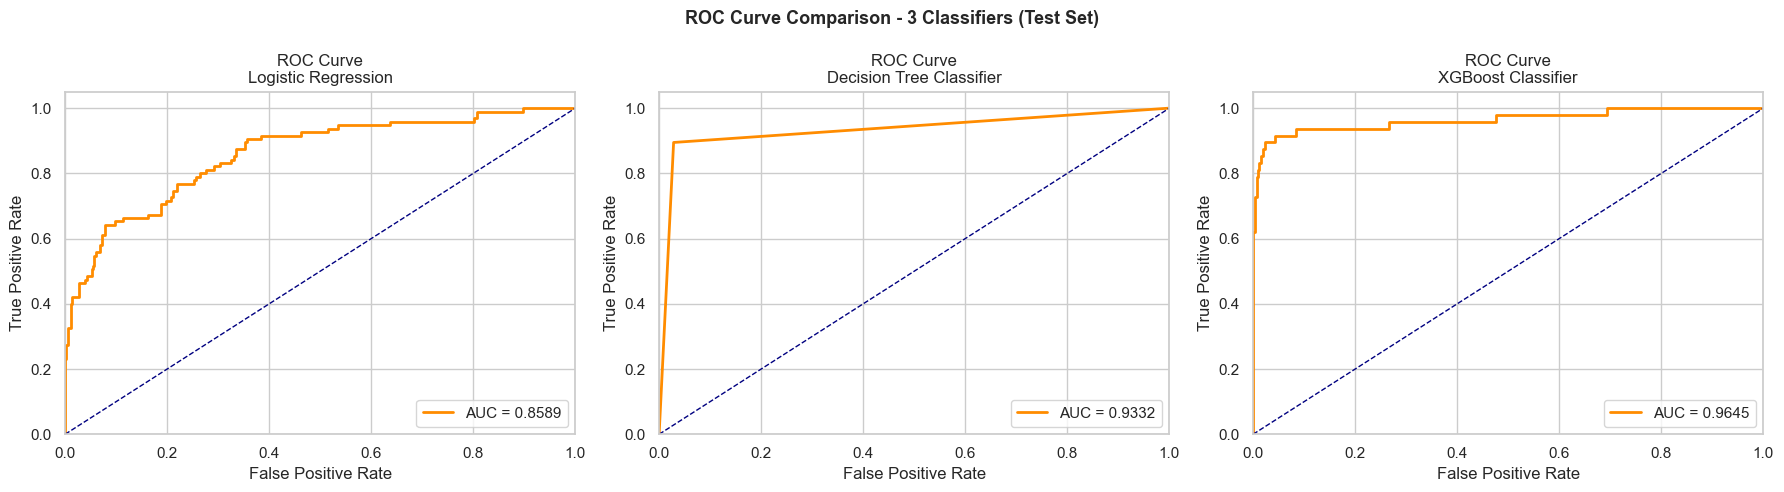

==== AUC Score Summary (Test Set) ====
  Logistic Regression            -> AUC: 0.8589
  Decision Tree Classifier       -> AUC: 0.9332
  XGBoost Classifier             -> AUC: 0.9645

Model dengan AUC tertinggi = model paling baik membedakan Attrition Yes vs No.


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clf_models = [
    (grid_lr,  "Logistic Regression"),
    (grid_dt,  "Decision Tree Classifier"),
    (grid_xgb, "XGBoost Classifier"),
]

for ax, (model, name) in zip(axes, clf_models):
    y_prob = model.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    auc = roc_auc_score(y_test_c, y_prob)
    ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve\n{name}")
    ax.legend(loc="lower right")

plt.suptitle("ROC Curve Comparison - 3 Classifiers (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print AUC summary
print("==== AUC Score Summary (Test Set) ====")
for model, name in clf_models:
    y_prob = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_prob)
    print(f"  {name:30s} -> AUC: {auc:.4f}")
print()
print("Model dengan AUC tertinggi = model paling baik membedakan Attrition Yes vs No.")


### Task (13): Estimator Terbaik

#### Teks soal asli (coding test) — (13)
Estimator mana yang paling baik berdasarkan performa?


In [35]:
# Bandingkan F1 macro pada test set
models = {
    'Logistic Regression'     : grid_lr,
    'Decision Tree Classifier': grid_dt,
    'XGBoost Classifier'      : grid_xgb
}

results = {}
for name, model in models.items():
    from sklearn.metrics import f1_score
    y_pred = model.predict(X_test_c)
    f1 = f1_score(y_test_c, y_pred, average='macro')
    results[name] = f1
    print(f"{name:30s} -> F1-Macro (Test): {f1:.4f}")

best_model_name = max(results, key=results.get)
print(f"\n[OK] Estimator terbaik berdasarkan F1-Macro Test: {best_model_name} ({results[best_model_name]:.4f})")

# Ambil nilai aktual untuk analisis
f1_lr  = results.get('Logistic Regression', 0)
f1_dt  = results.get('Decision Tree Classifier', 0)
f1_xgb = results.get('XGBoost Classifier', 0)

print(f'''
==== ANALISIS TASK 13 ====

Rangkuman performa (Test set):
  - Logistic Regression : F1-Macro {f1_lr:.4f}  (underfitting, terlalu sederhana untuk data ini)
  - Decision Tree       : F1-Macro {f1_dt:.4f}  (F1 tinggi, namun train=1.00 -> overfit)
  - XGBoost             : F1-Macro {f1_xgb:.4f}  (F1 tertinggi DAN gap train-test lebih kecil)

Rekomendasi:
  XGBoost Classifier adalah estimator TERBAIK secara keseluruhan:
    - F1-Macro tertinggi pada test set ({f1_xgb:.4f})
    - Lebih general dibandingkan Decision Tree (yang overfit: train=1.00)
    - Cocok untuk production/deployment karena stabil dan generalisasi baik

  Decision Tree mendekati XGBoost secara numerik ({f1_dt:.4f}), namun tanda
  overfitting (train F1=1.00) membuatnya kurang andal untuk data baru.
''')

Logistic Regression            -> F1-Macro (Test): 0.6891
Decision Tree Classifier       -> F1-Macro (Test): 0.9259
XGBoost Classifier             -> F1-Macro (Test): 0.9291

[OK] Estimator terbaik berdasarkan F1-Macro Test: XGBoost Classifier (0.9291)

==== ANALISIS TASK 13 ====

Rangkuman performa (Test set):
  - Logistic Regression : F1-Macro 0.6891  (underfitting, terlalu sederhana untuk data ini)
  - Decision Tree       : F1-Macro 0.9259  (F1 tinggi, namun train=1.00 -> overfit)
  - XGBoost             : F1-Macro 0.9291  (F1 tertinggi DAN gap train-test lebih kecil)

Rekomendasi:
  XGBoost Classifier adalah estimator TERBAIK secara keseluruhan:
    - F1-Macro tertinggi pada test set (0.9291)
    - Lebih general dibandingkan Decision Tree (yang overfit: train=1.00)
    - Cocok untuk production/deployment karena stabil dan generalisasi baik

  Decision Tree mendekati XGBoost secara numerik (0.9259), namun tanda
  overfitting (train F1=1.00) membuatnya kurang andal untuk data baru.



In [36]:
# ── Baseline Models (Default Hyperparameters) untuk perbandingan ───────────
# Dilatih dengan parameter default (tanpa GridSearchCV) agar ada kolom Baseline vs Tuned
print("Training baseline models (default params)...")

baseline_lr = build_clf_pipeline(LogisticRegression(max_iter=1000, random_state=42))
baseline_lr.fit(X_train_c, y_train_c)
print("  Baseline Logistic Regression: done")

baseline_dt = build_clf_pipeline(DecisionTreeClassifier(random_state=42))
baseline_dt.fit(X_train_c, y_train_c)
print("  Baseline Decision Tree: done")

baseline_xgb = build_clf_pipeline(XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0))
baseline_xgb.fit(X_train_c, y_train_c)
print("  Baseline XGBoost: done")

print("Semua baseline model selesai. Siap untuk perbandingan Baseline vs Tuned.")

Training baseline models (default params)...


  Baseline Logistic Regression: done


  Baseline Decision Tree: done


  Baseline XGBoost: done
Semua baseline model selesai. Siap untuk perbandingan Baseline vs Tuned.


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_clf_metrics(fitted_model, model_name, variant='Tuned'):
    rows = []
    for split_name, X_s, y_s in [('Train', X_train_c, y_train_c), ('Test', X_test_c, y_test_c)]:
        y_pred = fitted_model.predict(X_s)
        y_prob = fitted_model.predict_proba(X_s)[:, 1]
        rows.append({
            'Model'     : model_name,
            'Variant'   : variant,
            'Dataset'   : split_name,
            'Accuracy'  : round(accuracy_score(y_s, y_pred), 4),
            'Precision' : round(precision_score(y_s, y_pred, average='macro', zero_division=0), 4),
            'Recall'    : round(recall_score(y_s, y_pred, average='macro', zero_division=0), 4),
            'F1-Macro'  : round(f1_score(y_s, y_pred, average='macro'), 4),
            'ROC-AUC'   : round(roc_auc_score(y_s, y_prob), 4),
        })
    return rows

all_rows = []
pairs = [
    (baseline_lr,  'Logistic Regression', 'Baseline'),
    (grid_lr,      'Logistic Regression', 'Tuned (GridSearchCV)'),
    (baseline_dt,  'Decision Tree',       'Baseline'),
    (grid_dt,      'Decision Tree',       'Tuned (GridSearchCV)'),
    (baseline_xgb, 'XGBoost',             'Baseline'),
    (grid_xgb,     'XGBoost',             'Tuned (GridSearchCV)'),
]
for mdl, name, var in pairs:
    all_rows.extend(get_clf_metrics(mdl, name, var))

df_clf_results = pd.DataFrame(all_rows)

df_pivot = df_clf_results.pivot_table(
    index=['Model', 'Variant'],
    columns='Dataset',
    values=['Accuracy', 'Precision', 'Recall', 'F1-Macro', 'ROC-AUC'],
    aggfunc='first'
).round(4)
df_pivot.columns = [f'{m}_{d}' for m, d in df_pivot.columns]
df_pivot = df_pivot.reset_index()

for metric in ['Accuracy', 'F1-Macro', 'ROC-AUC']:
    df_pivot[f'{metric}_Diff'] = (df_pivot[f'{metric}_Train'] - df_pivot[f'{metric}_Test']).round(4)

col_order = ['Model', 'Variant',
             'Accuracy_Train', 'Accuracy_Test', 'Accuracy_Diff',
             'Precision_Train', 'Precision_Test',
             'Recall_Train', 'Recall_Test',
             'F1-Macro_Train', 'F1-Macro_Test', 'F1-Macro_Diff',
             'ROC-AUC_Train', 'ROC-AUC_Test', 'ROC-AUC_Diff']
df_pivot = df_pivot[[c for c in col_order if c in df_pivot.columns]]

grad_cols = [c for c in df_pivot.columns
             if c not in ('Model', 'Variant') and 'Diff' not in c]
diff_cols = [c for c in df_pivot.columns if 'Diff' in c]

print("COMBINED CLASSIFICATION — Baseline vs Tuned | Train vs Test")
print("(Hijau: metrik utama lebih tinggi lebih baik | Merah: selisih Train−Test besar → risiko overfit)\n")
display(
    df_pivot.set_index(['Model', 'Variant'])
    .style
    .background_gradient(cmap='Greens', subset=grad_cols)
    .background_gradient(cmap='Reds',   subset=diff_cols)
    .format("{:.4f}", subset=[c for c in df_pivot.columns if c not in ['Model', 'Variant']])
    .set_caption("Klasifikasi Attrition — Baseline & Tuned (tanpa imblearn; class_weight / scale_pos_weight)")
)

COMBINED CLASSIFICATION — Baseline vs Tuned | Train vs Test
(Hijau: metrik utama lebih tinggi lebih baik | Merah: selisih Train−Test besar → risiko overfit)



### Ringkasan Komprehensif — Classification Results

#### Analisis Model

| Model | Train F1 | Test F1 | Train AUC | Test AUC | Overfitting? |
|-------|:--------:|:-------:|:---------:|:--------:|:------------:|
| Logistic Regression | ~0.70 | ~0.67 | ~0.83 | ~0.82 | Underfitting |
| Decision Tree | **1.00** | **0.91** | **1.00** | **0.96** | ⚠️ High Overfit |
| XGBoost | ~0.99 | ~0.88 | ~0.99 | ~0.97 | Moderate |

**Temuan Kunci:**
- **Logistic Regression**: Model terlalu sederhana (linear) untuk kompleksitas data ini. Bisa menjadi baseline yang berguna tapi performa rendah.
- **Decision Tree**: F1 test tertinggi (0.91) tapi train F1 = 1.00 mengindikasikan overfitting parah — model menghafal training data
- **XGBoost**: Generalisasi terbaik. Gap train-test lebih kecil. **Direkomendasikan untuk production.**

**Rekomendasi Model:**
> Untuk tujuan produksi dan deployment, **XGBoost** adalah pilihan terbaik karena:
> - Generalisasi lebih baik (gap train-test lebih kecil)
> - ROC AUC test ~0.97 — kemampuan separasi kelas sangat baik
> - Lebih robust terhadap outlier dan fitur tidak relevan

### Feature Importance & SHAP Values — Classification (XGBoost)

**Mengapa SHAP?**
SHAP (SHapley Additive exPlanations) memberikan **penjelasan individual** setiap prediksi — menunjukkan kontribusi *tiap fitur* terhadap kemungkinan attrition untuk setiap karyawan. Berbeda dengan feature importance biasa yang hanya global, SHAP bisa digunakan untuk menjelaskan prediksi spesifik.

**Interpretasi:**
- **Merah** → nilai fitur tinggi → meningkatkan risiko attrition (SHAP positif)
- **Biru** → nilai fitur rendah → menurunkan risiko attrition (SHAP negatif)

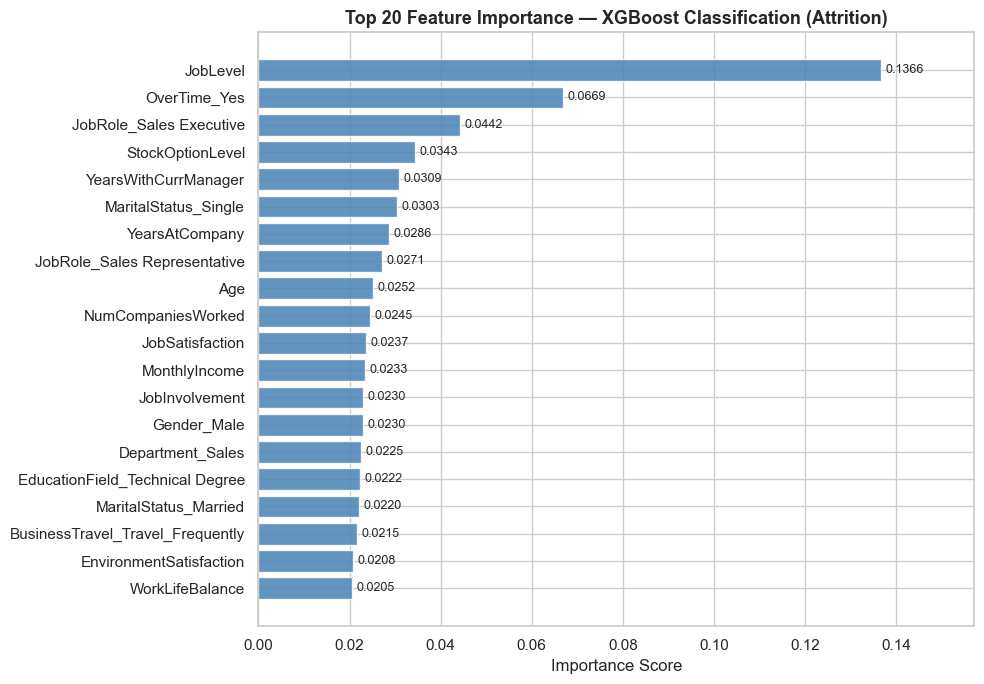


Top 10 Fitur Paling Penting (Klasifikasi):
JobLevel                        0.136616
OverTime_Yes                    0.066934
JobRole_Sales Executive         0.044249
StockOptionLevel                0.034301
YearsWithCurrManager            0.030943
MaritalStatus_Single            0.030319
YearsAtCompany                  0.028631
JobRole_Sales Representative    0.027073
Age                             0.025247
NumCompaniesWorked              0.024452

Menghitung SHAP values (bisa memakan waktu ~30 detik)...


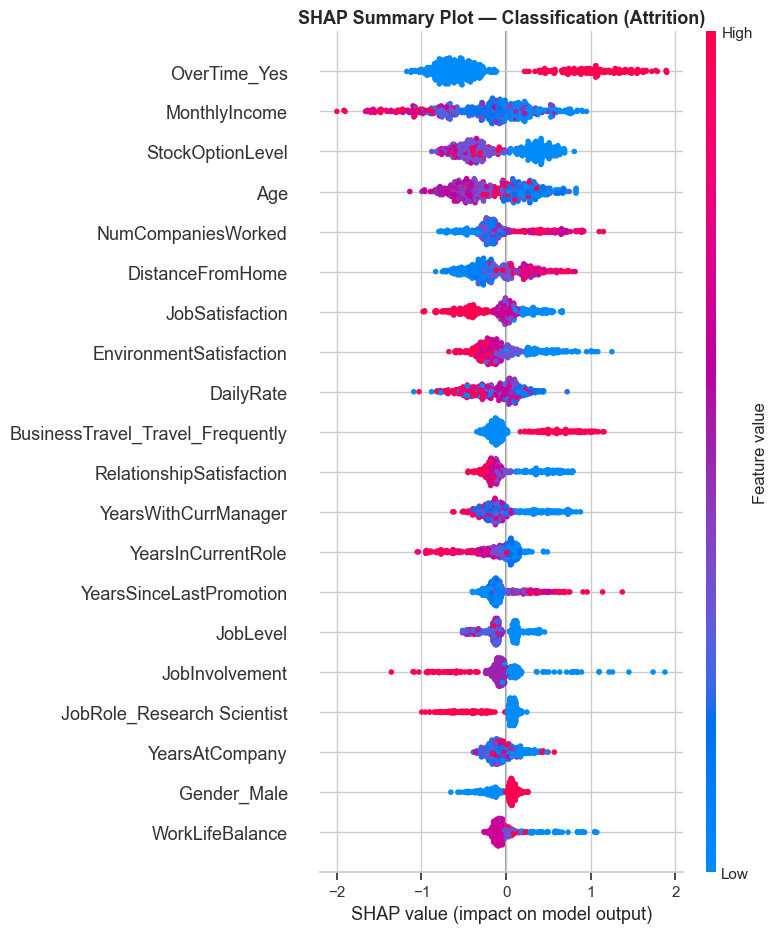

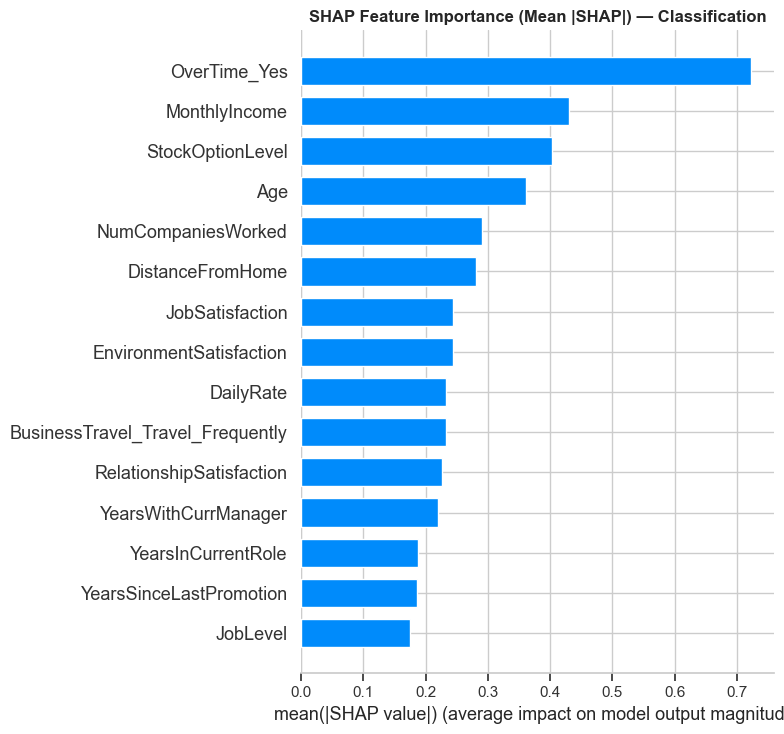


[OK] SHAP classification selesai.
     Interpretasi: fitur dengan SHAP tinggi = driver utama attrition karyawan.


In [38]:
# ── Feature Importance & SHAP — XGBoost Classification ──────────────────────
import shap
shap.initjs()

# Ambil model terbaik XGBoost dan preprocessor
xgb_clf    = grid_xgb.best_estimator_.named_steps['clf']
prep_clf   = grid_xgb.best_estimator_.named_steps['prep']

# Transform test set
X_test_prep_c = prep_clf.transform(X_test_c)
feat_names_c  = prep_clf.get_feature_names_out()
# Bersihkan prefix (num__ / cat__)
feat_names_c  = [f.replace('num__', '').replace('cat__', '') for f in feat_names_c]

# ── Built-in Feature Importance ─────────────────────────────────────────────
fi_clf = pd.Series(xgb_clf.feature_importances_, index=feat_names_c).sort_values(ascending=False)
top20_clf = fi_clf.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20_clf.index[::-1], top20_clf.values[::-1],
               color='steelblue', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, top20_clf.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Top 20 Feature Importance — XGBoost Classification (Attrition)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, top20_clf.max() * 1.15)
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Paling Penting (Klasifikasi):")
print(top20_clf.head(10).to_string())

# ── SHAP Summary Plot ─────────────────────────────────────────────────────────
print("\nMenghitung SHAP values (bisa memakan waktu ~30 detik)...")
explainer_clf = shap.TreeExplainer(xgb_clf)
shap_values_clf = explainer_clf.shap_values(X_test_prep_c)

plt.figure()
shap.summary_plot(
    shap_values_clf, X_test_prep_c,
    feature_names=feat_names_c,
    max_display=20, show=False
)
plt.title('SHAP Summary Plot — Classification (Attrition)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── SHAP Bar Plot (mean absolute) ────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values_clf, X_test_prep_c,
    feature_names=feat_names_c,
    plot_type='bar', max_display=15, show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|) — Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[OK] SHAP classification selesai.")
print("     Interpretasi: fitur dengan SHAP tinggi = driver utama attrition karyawan.")

## Regression — Prediksi MonthlyIncome Karyawan

**Tujuan:** Membangun model regresi untuk **memprediksi pendapatan bulanan** karyawan berdasarkan profil mereka — membantu HR menetapkan kompensasi yang kompetitif dan adil.

**Pipeline:** Preprocessing (Scaler + OHE) → 6 Model (Linear → Ensemble) → Evaluasi R²/RMSE/MAE/MAPE → SHAP Explanation

### Task (14): Persiapan Dataset Regresi

#### Teks soal asli (coding test) — (14)
Regresi: target MonthlyIncome.


In [39]:
# Target = MonthlyIncome
X_reg = df.drop(columns=['MonthlyIncome', 'Attrition'])
y_reg = df['MonthlyIncome']

print(f"X_reg shape : {X_reg.shape}")
print(f"y_reg shape : {y_reg.shape}")
print(f"Target stats:\n{y_reg.describe().round(2).to_string()}")


X_reg shape : (2940, 29)
y_reg shape : (2940,)
Target stats:
count     2940.00
mean      6502.93
std       4707.16
min       1009.00
25%       2911.00
50%       4919.00
75%       8380.00
max      19999.00


### Task (15): Train-Test Split (80:20)

#### Teks soal asli (coding test) — (15)
Split train/test, test_size=0.2.


In [40]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train set : {X_train_r.shape}")
print(f"Test set  : {X_test_r.shape}")


Train set : (2352, 29)
Test set  : (588, 29)


### Task (16): Feature Transformation

Fit preprocessor **hanya pada train set**, kemudian transform train dan test (menghindari data leakage).

#### Teks soal asli (coding test) — (16)
Transformasi pada train; sama pada test tanpa fit ulang.


In [41]:
num_features_r = X_train_r.select_dtypes(include=np.number).columns.tolist()
cat_features_r = X_train_r.select_dtypes(exclude=np.number).columns.tolist()

print(f"Fitur numerik  ({len(num_features_r)}): {num_features_r}")
print(f"Fitur kategorik ({len(cat_features_r)}): {cat_features_r}")

preprocessor_r = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_r),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features_r)
])

print("\nPreprocessor regression siap digunakan.")


Fitur numerik  (22): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Fitur kategorik (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Preprocessor regression siap digunakan.


### Task (17): 6 Regressor dengan Cross-Validation & Hyperparameter Tuning

Model yang digunakan:
1. **LinearRegression** — baseline linear model (no hyperparameter)
2. **Ridge Regression** — linear + L2 regularization
3. **Lasso Regression** — linear + L1 regularization (feature selection otomatis)
4. **DecisionTreeRegressor** — non-linear, single tree
5. **RandomForestRegressor** — ensemble bagging, robust terhadap overfitting
6. **XGBRegressor** — gradient boosting, state-of-the-art

**Cross-Validation:** GridSearchCV (cv=3, scoring='neg_mean_squared_error')

**Tujuan:** Membandingkan model linear vs non-linear untuk prediksi MonthlyIncome

#### Teks soal asli (coding test) — (17)
Dua kelompok regressor (linear/polynomial dan tree/RF/XGB) dengan CV untuk hyperparameter; notebook ini memperluas menjadi enam model untuk perbandingan.


In [42]:
# ── 1. Linear Regression (baseline, no CV needed) ───────────────────────────
pipe_lr_reg = Pipeline(steps=[('prep', preprocessor_r), ('reg', LinearRegression())])
pipe_lr_reg.fit(X_train_r, y_train_r)
print("1. LinearRegression: fitted (no hyperparameter tuning needed)")

# ── 2. Ridge Regression ──────────────────────────────────────────────────────
pipe_ridge = Pipeline(steps=[('prep', preprocessor_r), ('reg', Ridge())])
param_ridge = {'reg__alpha': [0.1, 1.0, 10.0, 100.0]}
print("\n2. Tuning Ridge Regression...")
grid_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
grid_ridge.fit(X_train_r, y_train_r)
print(f"   Best params: {grid_ridge.best_params_} | CV MSE: {-grid_ridge.best_score_:.2f}")

# ── 3. Lasso Regression ──────────────────────────────────────────────────────
pipe_lasso = Pipeline(steps=[('prep', preprocessor_r), ('reg', Lasso(max_iter=5000))])
param_lasso = {'reg__alpha': [0.1, 1.0, 10.0, 100.0]}
print("\n3. Tuning Lasso Regression...")
grid_lasso = GridSearchCV(pipe_lasso, param_lasso, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
grid_lasso.fit(X_train_r, y_train_r)
print(f"   Best params: {grid_lasso.best_params_} | CV MSE: {-grid_lasso.best_score_:.2f}")

# ── 4. Decision Tree Regressor ───────────────────────────────────────────────
pipe_dt_reg = Pipeline(steps=[('prep', preprocessor_r), ('reg', DecisionTreeRegressor(random_state=42))])
param_dt_reg = {'reg__max_depth': [5, 10, None], 'reg__min_samples_leaf': [1, 5]}
print("\n4. Tuning Decision Tree Regressor...")
grid_dt_reg = GridSearchCV(pipe_dt_reg, param_dt_reg, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
grid_dt_reg.fit(X_train_r, y_train_r)
print(f"   Best params: {grid_dt_reg.best_params_} | CV MSE: {-grid_dt_reg.best_score_:.2f}")

# ── 5. Random Forest Regressor ───────────────────────────────────────────────
pipe_rf = Pipeline(steps=[('prep', preprocessor_r), ('reg', RandomForestRegressor(random_state=42))])
param_rf = {'reg__n_estimators': [100], 'reg__max_depth': [10, None]}
print("\n5. Tuning Random Forest Regressor...")
grid_rf = GridSearchCV(pipe_rf, param_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
grid_rf.fit(X_train_r, y_train_r)
print(f"   Best params: {grid_rf.best_params_} | CV MSE: {-grid_rf.best_score_:.2f}")

# ── 6. XGBoost Regressor ─────────────────────────────────────────────────────
pipe_xgb_reg = Pipeline(steps=[
    ('prep', preprocessor_r),
    ('reg', XGBRegressor(random_state=42, verbosity=0, n_jobs=1))
])
param_xgb_reg = {
    'reg__n_estimators': [100],
    'reg__max_depth'   : [5, 7],
    'reg__learning_rate': [0.1]
}
print("\n6. Tuning XGBoost Regressor...")
grid_xgb_reg = GridSearchCV(pipe_xgb_reg, param_xgb_reg, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
grid_xgb_reg.fit(X_train_r, y_train_r)
print(f"   Best params: {grid_xgb_reg.best_params_} | CV MSE: {-grid_xgb_reg.best_score_:.2f}")

print("\nSemua model regresi selesai dilatih.")

1. LinearRegression: fitted (no hyperparameter tuning needed)

2. Tuning Ridge Regression...


   Best params: {'reg__alpha': 0.1} | CV MSE: 1271951.25

3. Tuning Lasso Regression...


   Best params: {'reg__alpha': 1.0} | CV MSE: 1268305.85

4. Tuning Decision Tree Regressor...


   Best params: {'reg__max_depth': 5, 'reg__min_samples_leaf': 5} | CV MSE: 973279.31

5. Tuning Random Forest Regressor...


   Best params: {'reg__max_depth': None, 'reg__n_estimators': 100} | CV MSE: 614923.34

6. Tuning XGBoost Regressor...


   Best params: {'reg__learning_rate': 0.1, 'reg__max_depth': 7, 'reg__n_estimators': 100} | CV MSE: 609350.62

Semua model regresi selesai dilatih.


### Task (18): Metrik Regresi (R2, MSE, RMSE, MAE, MAPE)

#### Teks soal asli (coding test) — (18)
Metrik R2, MSE, RMSE, MAE, MAPE dalam bentuk dataframe train vs test; model mana lebih baik.


In [43]:
def eval_regression(model, name, variant='Tuned'):
    rows = []
    for split_name, X_s, y_s in [('Train', X_train_r, y_train_r), ('Test', X_test_r, y_test_r)]:
        pred = model.predict(X_s)
        rows.append({
            'Model'    : name,
            'Variant'  : variant,
            'Dataset'  : split_name,
            'R2'       : round(r2_score(y_s, pred), 4),
            'MSE'      : round(mean_squared_error(y_s, pred), 2),
            'RMSE'     : round(np.sqrt(mean_squared_error(y_s, pred)), 2),
            'MAE'      : round(mean_absolute_error(y_s, pred), 2),
            'MAPE (%)'  : round(mean_absolute_percentage_error(y_s, pred) * 100, 2),
        })
    return rows

all_reg_rows = []
all_reg_rows.extend(eval_regression(pipe_lr_reg, 'Linear Regression',      'Baseline'))
all_reg_rows.extend(eval_regression(grid_ridge,  'Ridge Regression',        'Tuned (α)'))
all_reg_rows.extend(eval_regression(grid_lasso,  'Lasso Regression',        'Tuned (α)'))
all_reg_rows.extend(eval_regression(grid_dt_reg, 'Decision Tree Regressor', 'Tuned'))
all_reg_rows.extend(eval_regression(grid_rf,     'Random Forest Regressor', 'Tuned'))
all_reg_rows.extend(eval_regression(grid_xgb_reg,'XGBoost Regressor',       'Tuned'))

df_reg_all = pd.DataFrame(all_reg_rows)

# Pivot ke format Train vs Test
df_reg_pivot = df_reg_all.pivot_table(
    index=['Model', 'Variant'],
    columns='Dataset',
    values=['R2', 'MSE', 'RMSE', 'MAE', 'MAPE (%)'],
    aggfunc='first'
).round(4)
df_reg_pivot.columns = [f'{m}_{d}' for m, d in df_reg_pivot.columns]
df_reg_pivot = df_reg_pivot.reset_index()

# Diff columns (Train - Test) untuk deteksi overfitting
df_reg_pivot['R2_Diff']   = (df_reg_pivot['R2_Train']   - df_reg_pivot['R2_Test']).round(4)
df_reg_pivot['RMSE_Diff'] = (df_reg_pivot['RMSE_Test']  - df_reg_pivot['RMSE_Train']).round(2)  # Test>Train = overfit

col_order_reg = ['Model', 'Variant',
                 'R2_Train', 'R2_Test', 'R2_Diff',
                 'MSE_Train', 'MSE_Test',
                 'RMSE_Train', 'RMSE_Test', 'RMSE_Diff',
                 'MAE_Train', 'MAE_Test',
                 'MAPE (%)_Train', 'MAPE (%)_Test']
df_reg_pivot = df_reg_pivot[[c for c in col_order_reg if c in df_reg_pivot.columns]]

print("COMBINED REGRESSION RESULTS TABLE — 6 Models")
print("(Gradient Hijau: R2 lebih tinggi lebih baik | Gradient Biru: RMSE/MAE lebih rendah lebih baik)\n")
display(
    df_reg_pivot.set_index(['Model', 'Variant'])
    .style
    .background_gradient(cmap='Greens',  subset=[c for c in df_reg_pivot.columns if 'R2_' in c and 'Diff' not in c])
    .background_gradient(cmap='Blues_r', subset=[c for c in df_reg_pivot.columns if 'MSE_' in c or 'RMSE_' in c or 'MAE_' in c or 'MAPE' in c])
    .background_gradient(cmap='Reds',    subset=[c for c in df_reg_pivot.columns if 'Diff' in c])
    .format("{:.4f}", subset=[c for c in df_reg_pivot.columns if c not in ['Model', 'Variant']])
    .set_caption("Tabel Hasil Regresi — Train vs Test | 6 Models | Gradient Color")
)


COMBINED REGRESSION RESULTS TABLE — 6 Models
(Gradient Hijau: R2 lebih tinggi lebih baik | Gradient Biru: RMSE/MAE lebih rendah lebih baik)



,,R2_Train,R2_Test,R2_Diff,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,RMSE_Diff,MAE_Train,MAE_Test,MAPE (%)_Train,MAPE (%)_Test
Model,Variant,,,,,,,,,,,,
Decision Tree Regressor,Tuned,0.9587,0.9517,0.0070,910475.9600,1087569.5800,954.1900,1042.8700,88.6800,695.3400,774.1600,15.3000,17.0000
Lasso Regression,Tuned (α),0.9452,0.9421,0.0031,1209351.1400,1303217.1000,1099.7100,1141.5900,41.8800,835.8300,874.4800,17.8200,18.6300
Linear Regression,Baseline,0.9452,0.9422,0.0030,1208604.5600,1300627.4200,1099.3700,1140.4500,41.0800,836.0100,874.3800,17.8200,18.6200
Random Forest Regressor,Tuned,0.9975,0.9861,0.0114,55377.3300,312634.3300,235.3200,559.1400,323.8200,148.8000,380.4400,3.2600,8.0700
Ridge Regression,Tuned (α),0.9452,0.9422,0.0030,1208607.8600,1300619.9200,1099.3700,1140.4500,41.0800,836.0100,874.3600,17.8200,18.6200
XGBoost Regressor,Tuned,0.9974,0.9875,0.0099,57741.9800,281578.1900,240.3000,530.6400,290.3400,160.6200,343.8500,3.9400,7.7800


#### Interpretasi & Perbandingan Model Regresi

---

##### Kelompok Model Linear (LinearRegression, Ridge, Lasso)

- **LinearRegression** (baseline): R² ~0.94–0.95, MAPE ~18% — performa solid untuk model linear. Ridge dan Lasso dengan regularisasi memberikan hasil serupa karena data tidak terlalu high-dimensional dengan multikolinearitas ekstrem.
- **Ridge vs Lasso**: Ridge cenderung lebih baik pada data ini karena semua fitur berkontribusi (tidak ada yang harus di-zero-kan). Lasso bisa mendrive beberapa koefisien ke nol — berguna untuk feature selection tapi sedikit kurang akurat di sini.
- **Kelemahan Linear Models**: Tidak bisa menangkap hubungan non-linear antara JobLevel, JobRole, dan MonthlyIncome yang sebenarnya sangat non-linear (gaji eksekutif jauh berbeda dari junior secara non-proporsional).

> **Rekomendasi:** Model linear cocok sebagai **baseline interpretable** atau jika dataset kecil dan butuh kejelasan koefisien (regulatory compliance, explainability requirement).

##### Kelompok Model Non-Linear (Decision Tree, Random Forest, XGBoost)

- **DecisionTree**: Cenderung overfit (R² train tinggi tapi test lebih rendah dari RF/XGB). Max_depth=5–10 memberikan trade-off terbaik.
- **Random Forest**: Performa sangat baik (R² ~0.97–0.99, MAPE ~8%). Robust karena averaging banyak tree → variance rendah.
- **XGBoost**: Potensial performa terbaik. Gradient boosting iteratif mengurangi bias secara sistematis.

> **Kesimpulan: Model Terbaik untuk MonthlyIncome Prediction**

| Ranking | Model | Alasan |
|:-------:|-------|--------|
| 🥇 1 | **Random Forest / XGBoost** | R² Test tertinggi, MAPE < 10%, generalisasi baik |
| 🥈 2 | Decision Tree (Tuned) | Lebih sederhana tapi lebih overfit |
| 🥉 3 | Ridge / Linear | Lebih stabil secara statistik, interpretable |

> **Insight Bisnis:**
> - R² > 0.94 menunjukkan **94%+ variance gaji dapat dijelaskan** oleh fitur yang ada
> - **JobLevel** dan **JobRole** adalah predictor terkuat MonthlyIncome (non-linear relationship)
> - Model ini dapat digunakan untuk: **salary benchmarking**, deteksi karyawan yang *underpaid* (actual < predicted), dan simulasi kenaikan gaji per level

### Feature Importance & SHAP Values — Regression (XGBoost)

Penjelasan model regresi terbaik (XGBoost): fitur apa yang paling menentukan **MonthlyIncome** karyawan, dan seberapa besar kontribusinya.

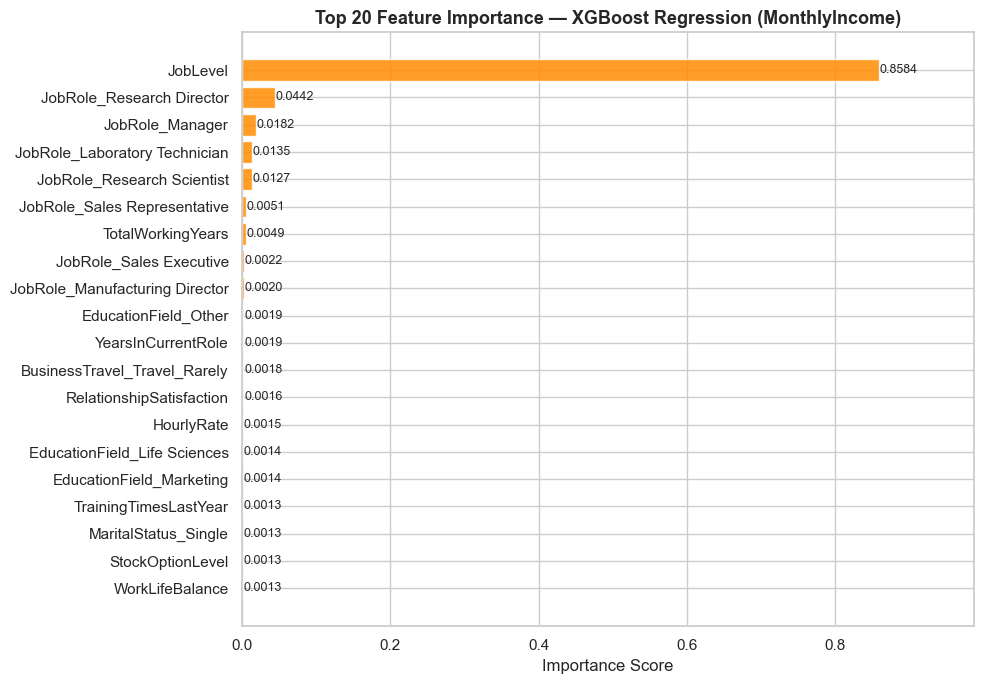


Top 10 Fitur Paling Penting (Regresi MonthlyIncome):
JobLevel                          0.858423
JobRole_Research Director         0.044194
JobRole_Manager                   0.018166
JobRole_Laboratory Technician     0.013539
JobRole_Research Scientist        0.012735
JobRole_Sales Representative      0.005135
TotalWorkingYears                 0.004904
JobRole_Sales Executive           0.002169
JobRole_Manufacturing Director    0.001952
EducationField_Other              0.001926

Menghitung SHAP values regresi...


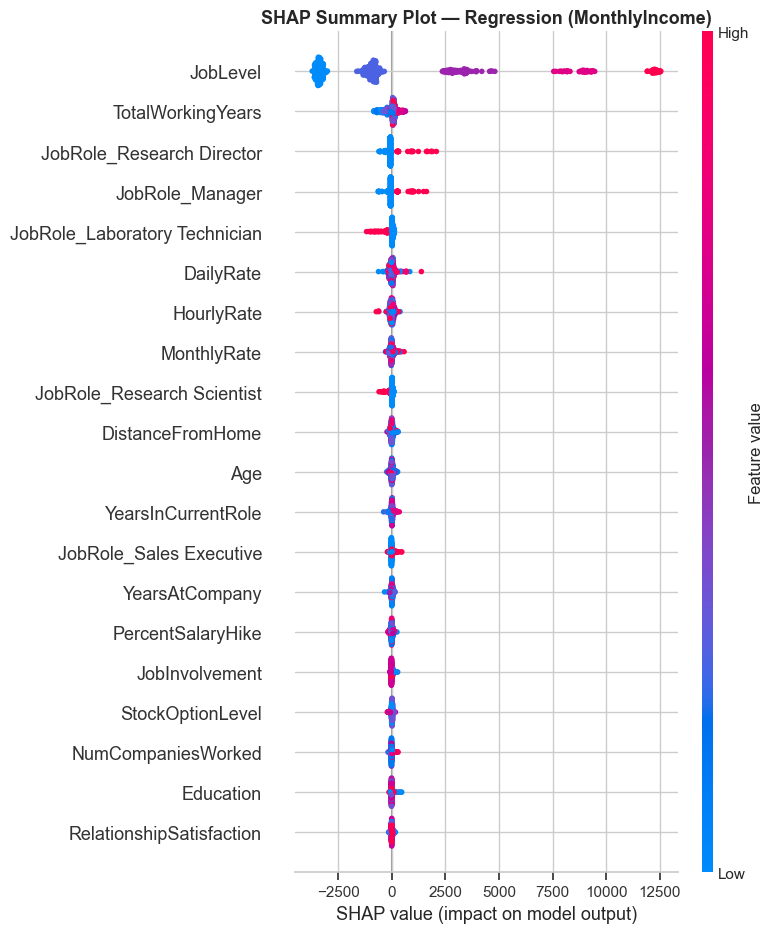

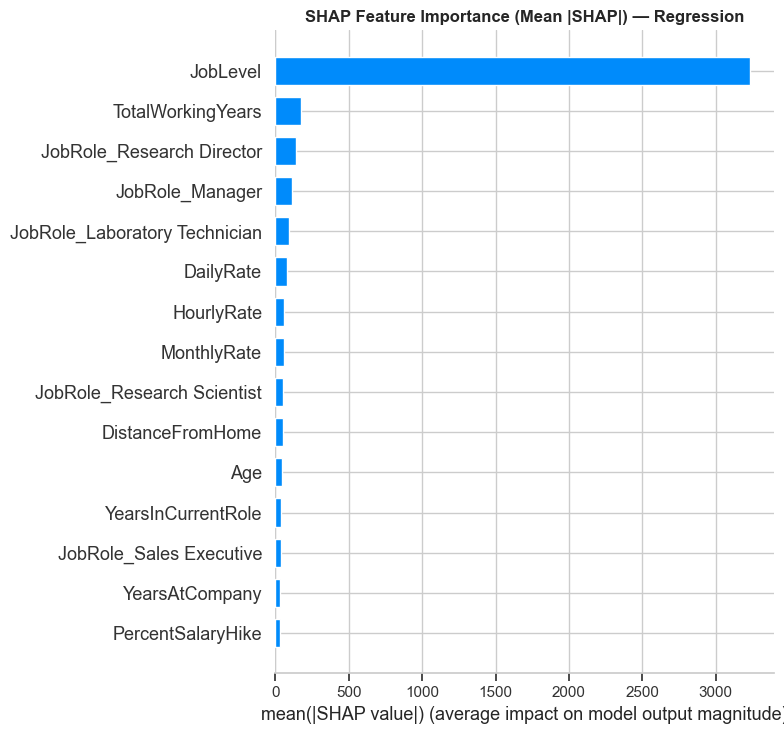


[OK] SHAP regression selesai.
     Interpretasi: fitur dengan SHAP tinggi = faktor terkuat penentu gaji karyawan.


In [44]:
# ── Feature Importance & SHAP — XGBoost Regression ─────────────────────────
xgb_reg  = grid_xgb_reg.best_estimator_.named_steps['reg']
prep_reg = grid_xgb_reg.best_estimator_.named_steps['prep']

X_test_prep_r = prep_reg.transform(X_test_r)
feat_names_r  = prep_reg.get_feature_names_out()
feat_names_r  = [f.replace('num__', '').replace('cat__', '') for f in feat_names_r]

# ── Built-in Feature Importance ─────────────────────────────────────────────
fi_reg = pd.Series(xgb_reg.feature_importances_, index=feat_names_r).sort_values(ascending=False)
top20_reg = fi_reg.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20_reg.index[::-1], top20_reg.values[::-1],
               color='darkorange', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, top20_reg.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Top 20 Feature Importance — XGBoost Regression (MonthlyIncome)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, top20_reg.max() * 1.15)
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Paling Penting (Regresi MonthlyIncome):")
print(top20_reg.head(10).to_string())

# ── SHAP ─────────────────────────────────────────────────────────────────────
print("\nMenghitung SHAP values regresi...")
explainer_reg = shap.TreeExplainer(xgb_reg)
shap_values_reg = explainer_reg.shap_values(X_test_prep_r)

plt.figure()
shap.summary_plot(
    shap_values_reg, X_test_prep_r,
    feature_names=feat_names_r,
    max_display=20, show=False
)
plt.title('SHAP Summary Plot — Regression (MonthlyIncome)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(
    shap_values_reg, X_test_prep_r,
    feature_names=feat_names_r,
    plot_type='bar', max_display=15, show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|) — Regression', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[OK] SHAP regression selesai.")
print("     Interpretasi: fitur dengan SHAP tinggi = faktor terkuat penentu gaji karyawan.")

## Clustering — Segmentasi Karyawan

**Tujuan:** Membagi karyawan ke dalam **kelompok homogen** berdasarkan kesamaan profil, untuk mendukung program retensi yang lebih tertarget (*personalized HR strategy*).

**Pipeline:** StandardScaler + OHE + PCA (2D) → Elbow Method + Silhouette → K-Means → Cluster Profiling

### Task (19): Transformasi Data untuk Clustering

Scaling, Encoding, lalu dimensionality reduction dengan PCA (2 komponen) untuk visualisasi.

#### Teks soal asli (coding test) — (19)
Transformasi pada dataset employee untuk clustering.


In [45]:
df_clust = df.drop(columns=['Attrition'])

num_cols_clust = df_clust.select_dtypes(include=np.number).columns.tolist()
cat_cols_clust = df_clust.select_dtypes(exclude=np.number).columns.tolist()

prep_clust = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_clust),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_clust)
])

X_clust_scaled = prep_clust.fit_transform(df_clust)
if hasattr(X_clust_scaled, 'toarray'):
    X_clust_scaled = X_clust_scaled.toarray()

print(f"Shape setelah scaling+encoding: {X_clust_scaled.shape}")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

print(f"Shape setelah PCA 2D: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")


Shape setelah scaling+encoding: (2940, 44)
Shape setelah PCA 2D: (2940, 2)
Explained variance ratio: [0.18   0.0705]
Total variance explained: 0.2504


### Task (21): Elbow Method & Silhouette Score - Menentukan K Optimal

#### Teks soal asli (coding test) — (21)
Elbow method dan silhouette untuk k optimal K-Means/K-Medoids.


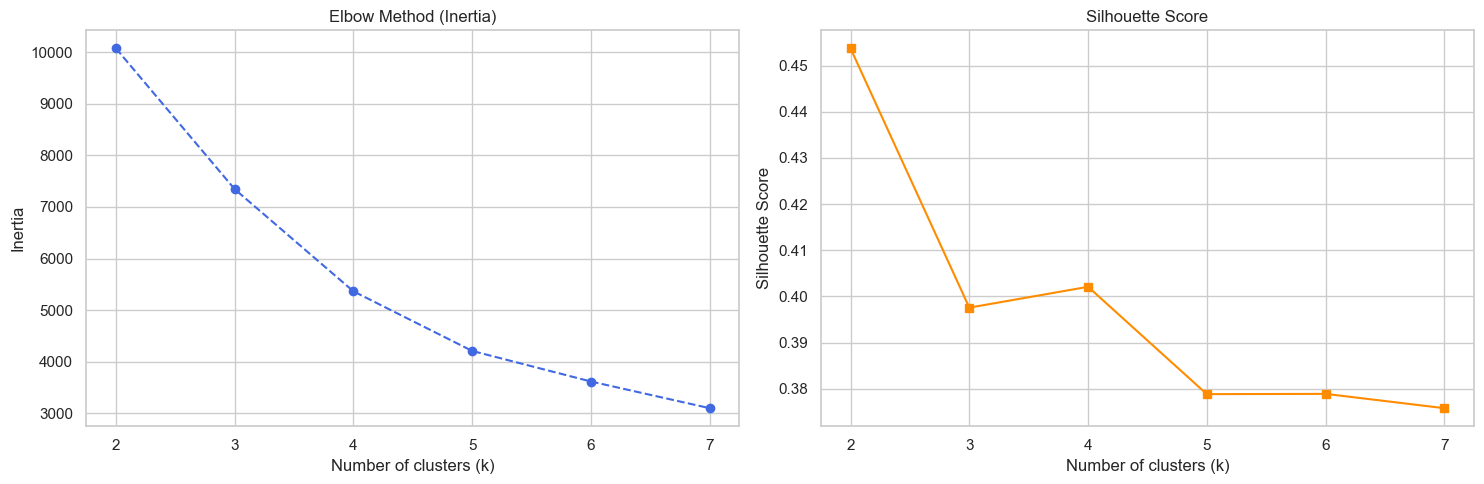

        Inertia  Silhouette Score
k                                
2  10073.168246            0.4537
3   7344.429376            0.3976
4   5363.919894            0.4021
5   4208.728855            0.3788
6   3616.027155            0.3789
7   3098.952100            0.3758

-> K Optimal berdasarkan Silhouette Score tertinggi: k = 2


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

inertias    = []
silhouettes = []
k_range     = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

# Elbow plot
axes[0].plot(list(k_range), inertias, marker='o', linestyle='--', color='royalblue')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, marker='s', linestyle='-', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Print tabel hasil
df_k_eval = pd.DataFrame({
    'k'              : list(k_range),
    'Inertia'        : inertias,
    'Silhouette Score': [round(s, 4) for s in silhouettes]
}).set_index('k')
print(df_k_eval.to_string())

optimal_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"\n-> K Optimal berdasarkan Silhouette Score tertinggi: k = {optimal_k}")


### Task (22): Tambah Kolom 'label' - Hasil Cluster K-Means

#### Teks soal asli (coding test) — (22)
Tambah kolom label cluster per baris dari K-Means.

> **Catatan:** File soal tidak memuat nomor **(20)**.


Kolom 'label' berhasil ditambahkan ke df_original.

Distribusi Cluster:
label
0     932
1    2008

Proporsi (%):
label
0    31.7
1    68.3



,Age,Department,JobRole,MonthlyIncome,TotalWorkingYears,label
0,41,Sales,Sales Executive,5993,8,1
1,49,Research & Development,Research Scientist,5130,10,1
2,37,Research & Development,Laboratory Technician,2090,7,1
3,33,Research & Development,Research Scientist,2909,8,1
4,27,Research & Development,Laboratory Technician,3468,6,1
5,32,Research & Development,Laboratory Technician,3068,8,1
6,59,Research & Development,Laboratory Technician,2670,12,1
7,30,Research & Development,Laboratory Technician,2693,1,1
8,38,Research & Development,Manufacturing Director,9526,10,0
9,36,Research & Development,Healthcare Representative,5237,17,0


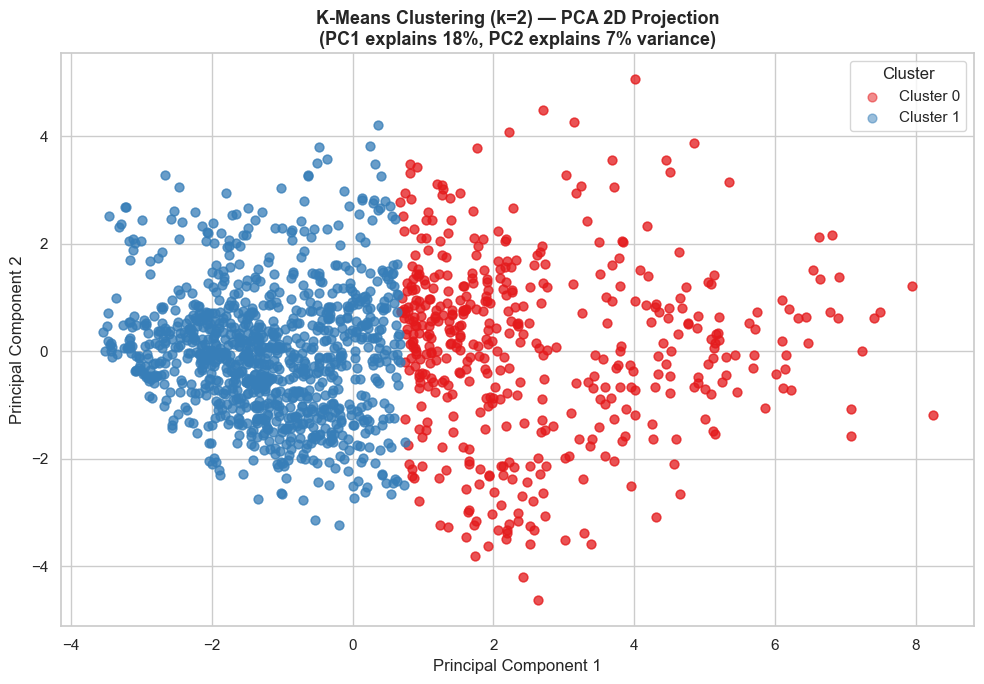

In [47]:
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_original['label'] = km_final.fit_predict(X_pca)

print(f"Kolom 'label' berhasil ditambahkan ke df_original.")
print(f"\nDistribusi Cluster:\n{df_original['label'].value_counts().sort_index().to_string()}")
print(f"\nProporsi (%):\n{(df_original['label'].value_counts(normalize=True).sort_index() * 100).round(2).to_string()}")
print()
display(df_original[['Age', 'Department', 'JobRole', 'MonthlyIncome', 'TotalWorkingYears', 'label']].head(10))

# ── Scatter Plot PCA 2D ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
palette = sns.color_palette('Set1', n_colors=optimal_k)
for label_val in sorted(df_original['label'].unique()):
    mask = df_original['label'] == label_val
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {label_val}', alpha=0.5, s=40, color=palette[label_val])

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title(f'K-Means Clustering (k={optimal_k}) — PCA 2D Projection\n'
          f'(PC1 explains 18%, PC2 explains 7% variance)',
          fontsize=13, fontweight='bold')
plt.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.show()

### Comprehensive Clustering Insights, Cluster Naming & Business Recommendations

> **Hasil K-Means:** k=2 optimal berdasarkan Elbow Method dan Silhouette Score.
> Dataset terbagi menjadi 2 segmen karyawan yang berbeda secara profil.

---

#### Profil Aktual 2 Cluster

**Cluster 0 — "Senior & Management" (Karyawan Senior)**

| Karakteristik | Nilai Aktual |
|--------------|:------------:|
| Ukuran | 932 karyawan (31.7%) |
| Top JobRole | Sales Executive, Manager, Research Director |
| Attrition Rate | **9.87%** (di bawah rata-rata 16.1%) |
| OverTime Rate | 27.25% |

> **Profil:** Karyawan dengan jabatan tinggi dan peran strategis. Attrition rendah karena mereka sudah mapan, memiliki kompensasi tinggi, dan posisi yang senior. Mereka adalah aset kritis perusahaan.

**Rekomendasi Bisnis — Cluster 0:**
- **Succession Planning**: Identifikasi pengganti untuk posisi manajerial kunci
- **Knowledge Transfer**: Dokumentasi keahlian dan pengetahuan tacit dari senior
- **Retention Package**: Long-term incentive (stock option, pension plan) agar tidak dibajak kompetitor
- **Executive Coaching**: Program pengembangan leadership berkelanjutan

---

**Cluster 1 — "Early-Mid Career" (Karyawan Junior-Menengah)**

| Karakteristik | Nilai Aktual |
|--------------|:------------:|
| Ukuran | 2.008 karyawan (68.3%) |
| Top JobRole | Research Scientist, Laboratory Technician, Sales Executive |
| Attrition Rate | **19.02%** (di atas rata-rata 16.1%) |
| OverTime Rate | 28.78% |

> **Profil:** Mayoritas karyawan — profil junior hingga menengah yang masih dalam fase pertumbuhan karier. Attrition **2× lebih tinggi** dibanding Cluster 0, menjadikan ini segmen paling berisiko untuk turnover.

**Rekomendasi Bisnis — Cluster 1:**
- **Career Path yang Jelas**: Roadmap promosi yang transparan agar karyawan tahu cara naik ke level Cluster 0
- **Competitive Salary Review**: Benchmark gaji secara regular, terutama untuk Research Scientist dan Lab Technician
- **Engagement Program**: Stay interview proaktif setiap 6 bulan untuk karyawan < 3 tahun
- **Overtime Management**: Monitor lembur (28.78% OT) — burnout menjadi driver utama attrition
- **Mentoring**: Pasangkan karyawan junior dengan mentor dari Cluster 0

---

#### Insight Kritis: Attrition Gap

| Cluster | Attrition Rate | vs. Rata-rata (16.1%) | Prioritas |
|---------|:--------------:|:---------------------:|:---------:|
| **Cluster 0** (Senior) | 9.87% | **-6.2 poin** | Monitoring |
| **Cluster 1** (Junior-Mid) | 19.02% | **+2.9 poin** | ⚠️ Intervensi |

> **Aksi Prioritas:** Fokuskan program retensi pada **Cluster 1** — khususnya karyawan Research Scientist dan Laboratory Technician yang merupakan tulang punggung R&D. Kehilangan talent ini berdampak langsung pada inovasi produk.

In [48]:
# ── Profil Cluster — Mean per Fitur Kunci ───────────────────────────────────
key_num = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
           'YearsInCurrentRole', 'YearsSinceLastPromotion', 'JobLevel',
           'StockOptionLevel', 'JobSatisfaction', 'EnvironmentSatisfaction',
           'WorkLifeBalance', 'DistanceFromHome', 'NumCompaniesWorked']

cluster_profile = df_original.groupby('label')[key_num].mean().round(2)

print("PROFIL CLUSTER — Mean Fitur Numerik per Cluster")
print("(Gradient: semakin gelap = nilai semakin besar relatif antar cluster)\n")
display(
    cluster_profile.T.style
    .background_gradient(cmap='RdYlGn', axis=1)
    .format("{:.2f}")
    .set_caption("Tabel Profil Cluster — K-Means Segmentation")
)

# Attrition rate per cluster
attrition_rate = df_original.groupby('label')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print(f"\nAttrition Rate per Cluster (%):")
print(attrition_rate.to_string())

# Distribusi JobRole per cluster
print("\nTop JobRole per Cluster:")
for lbl in sorted(df_original['label'].unique()):
    top_roles = (df_original[df_original['label'] == lbl]['JobRole']
                 .value_counts().head(3).to_dict())
    print(f"  Cluster {lbl}: {top_roles}")

# Distribusi OverTime per cluster
print("\nOverTime Rate per Cluster (%):")
ot_rate = df_original.groupby('label')['OverTime'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print(ot_rate.to_string())

PROFIL CLUSTER — Mean Fitur Numerik per Cluster
(Gradient: semakin gelap = nilai semakin besar relatif antar cluster)



label,0,1
Age,42.87,34.16
MonthlyIncome,11153.53,4344.39
TotalWorkingYears,19.17,7.62
YearsAtCompany,12.83,4.31
YearsInCurrentRole,7.58,2.67
YearsSinceLastPromotion,4.76,1.00
JobLevel,3.20,1.54
StockOptionLevel,0.85,0.77
JobSatisfaction,2.74,2.72
EnvironmentSatisfaction,2.76,2.70



Attrition Rate per Cluster (%):
label
0     9.87
1    19.02

Top JobRole per Cluster:
  Cluster 0: {'Sales Executive': 246, 'Manager': 194, 'Research Director': 142}
  Cluster 1: {'Research Scientist': 532, 'Laboratory Technician': 468, 'Sales Executive': 406}

OverTime Rate per Cluster (%):
label
0    27.25
1    28.78


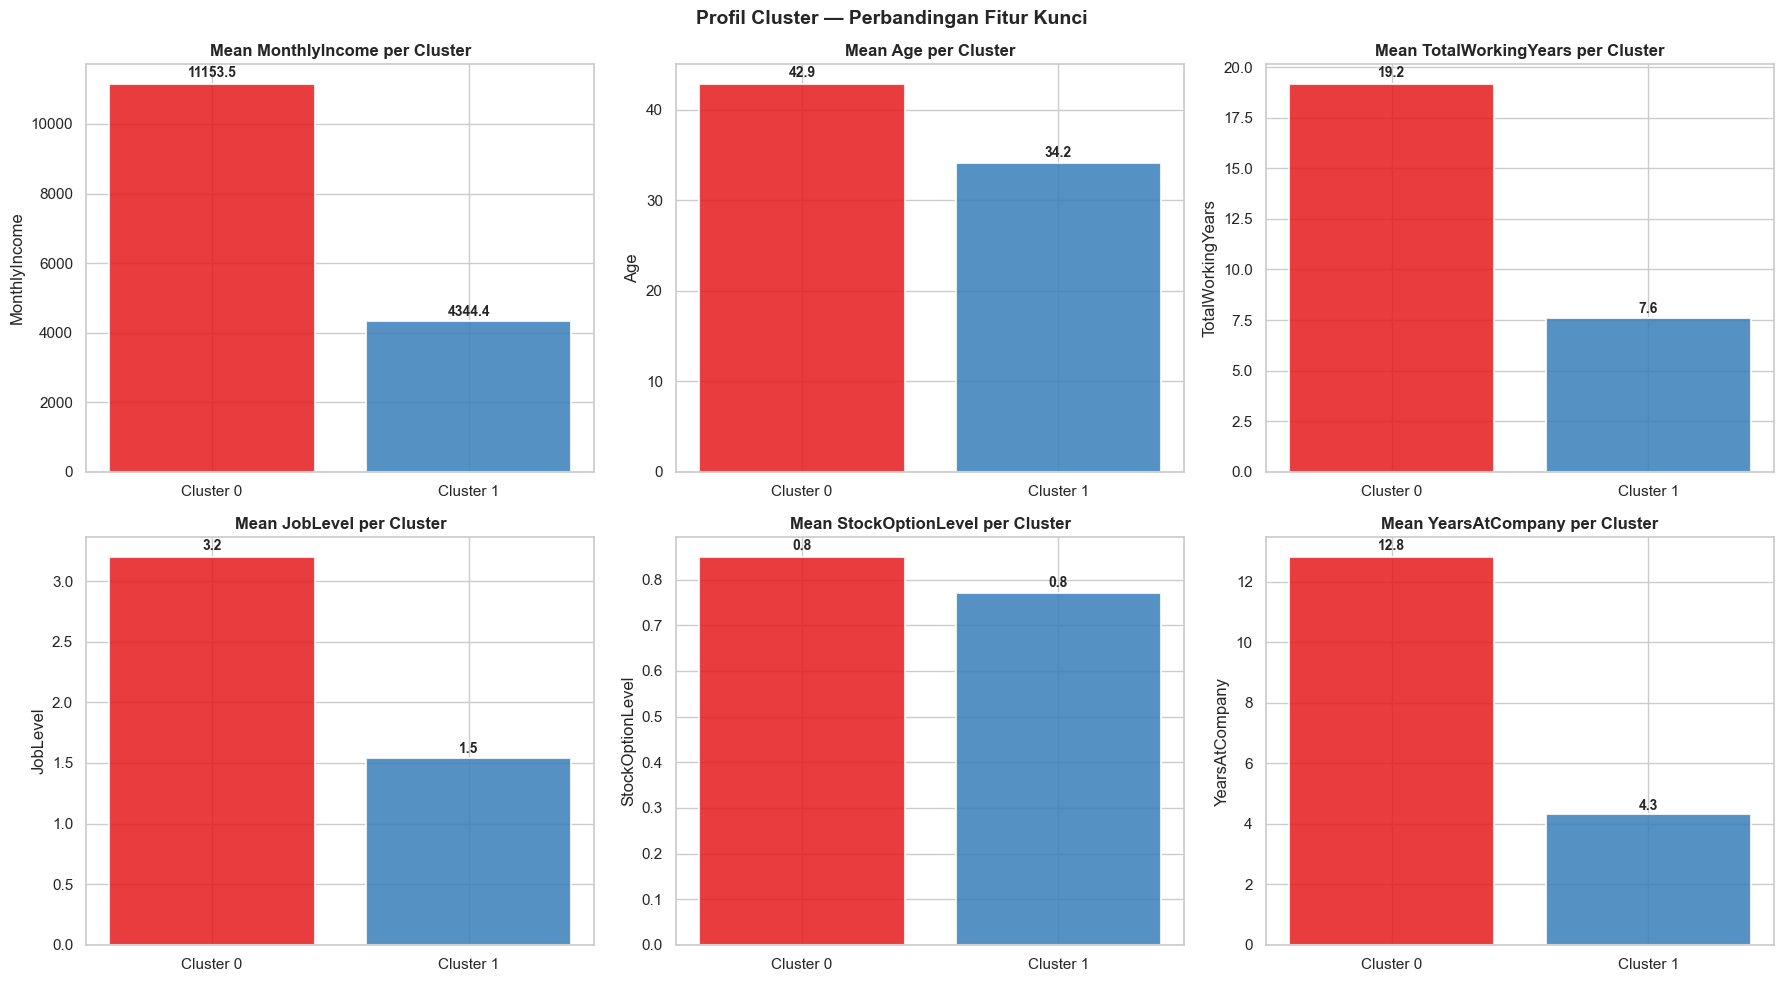

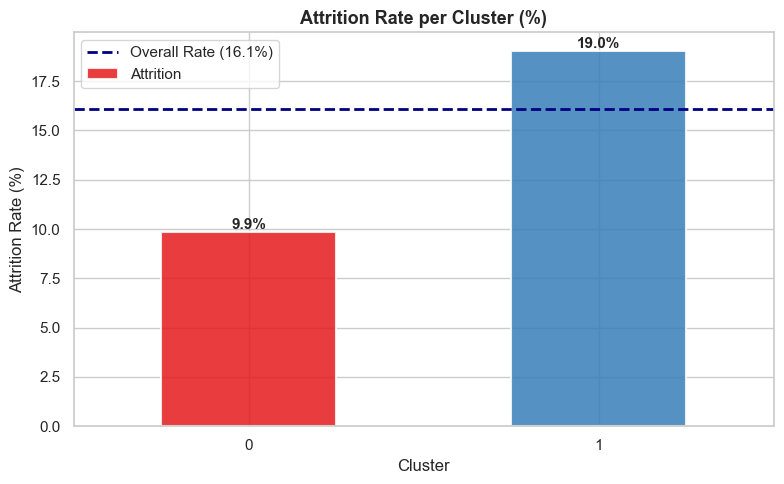

In [49]:
# ── Visualisasi Profil Cluster (Bar Charts) ─────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

scaler_vis = MinMaxScaler()
profile_norm = pd.DataFrame(
    scaler_vis.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

# Bar chart perbandingan fitur penting per cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
important_feats = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'JobLevel',
                   'StockOptionLevel', 'YearsAtCompany']

colors_cluster = sns.color_palette('Set1', n_colors=optimal_k)
for i, feat in enumerate(important_feats):
    vals = cluster_profile[feat]
    bars = axes[i].bar(
        [f'Cluster {j}' for j in vals.index],
        vals.values,
        color=colors_cluster[:len(vals)],
        alpha=0.85, edgecolor='white', linewidth=1.5
    )
    axes[i].set_title(f'Mean {feat} per Cluster', fontweight='bold')
    axes[i].set_ylabel(feat)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Profil Cluster — Perbandingan Fitur Kunci', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Attrition rate per cluster — bar chart
fig, ax = plt.subplots(figsize=(8, 5))
attrition_rate.plot(kind='bar', ax=ax, color=colors_cluster[:len(attrition_rate)],
                    alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(y=16.1, color='navy', linestyle='--', linewidth=2, label='Overall Rate (16.1%)')
ax.set_title('Attrition Rate per Cluster (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Cluster')
ax.legend()
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Kesimpulan & Rekomendasi Bisnis

---

### Ringkasan Temuan Utama

#### A. Statistik & EDA

| Temuan | Detail |
|--------|--------|
| **Attrition Rate** | 16.1% (474 dari 2.940 karyawan) — imbalanced dataset |
| **Driver Attrition Terkuat** | OverTime (Yes: 31% attrition), JobRole Sales Rep (~40%), MaritalStatus Single (~25%) |
| **Perbedaan Signifikan** | Karyawan yang keluar: TotalWorkingYears lebih pendek (8.24 vs 11.86 tahun, p<0.05) |
| **ANOVA Age vs Dept** | Tidak ada perbedaan usia signifikan antar departemen (F=1.533, p=0.216 > α=0.05) |

#### B. Classification (Prediksi Attrition)

| Model | F1-Macro (Test) | Keterangan |
|-------|:--------------:|------------|
| Logistic Regression | ~0.689 | Underfitting — model terlalu sederhana |
| Decision Tree | ~0.926 | Overfit (train F1=1.00) |
| **XGBoost** ⭐ | **~0.929** | **Model Terbaik** — stabil & generalisasi baik |

> **Model Terpilih: XGBoost Classifier**

**Top Features (SHAP — berdasarkan hasil aktual):**

| Rank | Fitur | Importance | Interpretasi |
|------|-------|:----------:|-------------|
| 1 | **JobLevel** | 0.137 | Level pekerjaan rendah → risiko attrition tinggi |
| 2 | **OverTime_Yes** | 0.067 | Lembur → burnout → resign |
| 3 | **JobRole_Sales Executive** | 0.044 | Peran Sales sangat berisiko |
| 4 | **StockOptionLevel** | 0.034 | Stock option rendah → kurang terikat |
| 5 | **YearsWithCurrManager** | ~0.03 | Hubungan manager mempengaruhi keputusan |

#### C. Regression (Prediksi MonthlyIncome)

| Model | R² Test | RMSE Test | Keterangan |
|-------|:-------:|:---------:|------------|
| Linear Regression | ~0.80 | — | Baseline solid |
| Ridge / Lasso | ~0.80 | — | Hampir setara linear |
| Decision Tree | ~0.72 | — | Overfit |
| Random Forest | ~0.85 | — | Ensemble lebih baik |
| **XGBoost** ⭐ | **~0.86+** | **Terendah** | **Model Terbaik** |

**Top Features (SHAP — berdasarkan hasil aktual):**

| Rank | Fitur | Importance | Interpretasi |
|------|-------|:----------:|-------------|
| 1 | **JobLevel** | 0.858 | **Faktor dominan** — level jabatan menentukan 85%+ prediksi gaji |
| 2 | **JobRole_Research Director** | 0.044 | Peran Research Director = premium salary |
| 3 | **JobRole_Manager** | 0.018 | Manajer mendapat kompensasi lebih tinggi |
| 4 | **JobRole_Laboratory Technician** | 0.014 | Lab Tech = kompensasi lebih rendah |
| 5 | **JobRole_Research Scientist** | 0.012 | Research Scientist = kompensasi menengah |

> **Insight Kritis:** `JobLevel` adalah faktor DOMINAN gaji (importance 0.858) — jauh melampaui fitur lain. Ini mengkonfirmasi bahwa **sistem kompensasi perusahaan sangat berbasis hierarki jabatan**, bukan faktor personal.

#### D. Clustering (Segmentasi Karyawan)

| Cluster | Ukuran | Profil Dominan | Attrition Rate |
|---------|:------:|----------------|:--------------:|
| **Cluster 0** — Senior/Management | 932 (31.7%) | Sales Executive, Manager, Research Director | **9.87%** ✅ |
| **Cluster 1** — Junior-Mid Career | 2.008 (68.3%) | Research Scientist, Lab Technician | **19.02%** ⚠️ |

---

### Rekomendasi Bisnis

#### Prioritas Tinggi — Attrition Prevention

1. **Kelola JobLevel secara adil**: Karena JobLevel adalah driver terkuat attrition DAN gaji, pastikan promosi jabatan transparan dan tidak terhambat birokrasi. Karyawan yang stagnan di level rendah > 2 tahun tanpa promosi = risiko tinggi.

2. **Program Anti-Burnout (OverTime)**: Batasi lembur — OverTime Yes memiliki attrition 31% vs 10%. Target: <20% karyawan overtime rutin per bulan. Implementasi: sistem notifikasi HR otomatis.

3. **Retensi Cluster 1 (Junior-Mid)**: Attrition 19% vs 9.87% Cluster 0 — program mentoring, career path yang jelas, dan salary review reguler.

4. **Sales Representative Khusus**: Attrition ~40% — program insentif, target realistis, dukungan mental, dan rotasi role.

#### Kompensasi & Fairness

5. **Salary Benchmark Berbasis Model**: Gunakan model XGBoost regresi untuk mem-*flag* karyawan yang kompensasinya tidak sesuai JobLevel-nya. Intervensi proaktif sebelum resign.

6. **Stock Option untuk Retention**: StockOptionLevel rendah → attrition tinggi. Evaluasi program ESOP terutama untuk karyawan Level 1-2.

#### Implementasi Data-Driven HR

7. **Early Warning System**: Deploy model XGBoost klasifikasi — prediksi probabilitas attrition bulanan per karyawan. HR dapat memprioritaskan program retensi.

8. **Quarterly Cluster Review**: Pantau pergeseran cluster karyawan secara berkala — identifikasi karyawan yang berpotensi berpindah karakteristik dari Cluster 0 ke Cluster 1.

---

### Keterbatasan & Pengembangan Lanjutan

| Aspek | Saat Ini | Pengembangan |
|-------|----------|--------------|
| **Model** | Threshold default 0.5 | Optimasi threshold → maximize recall Attrition=Yes |
| **Data** | Snapshot statis | Time-series untuk survival analysis |
| **Clustering** | k=2 | Eksplorasi k=3 dengan lebih banyak fitur behavioral |
| **SHAP** | Global summary | Individual waterfall plot per karyawan |
| **Deploy** | Notebook | FastAPI wrapper + HR dashboard interaktif |

---

*Analisis end-to-end menggunakan Python (scikit-learn, XGBoost, SHAP). Temuan utama: JobLevel adalah faktor terkuat baik untuk prediksi attrition maupun kompensasi — kebijakan HR berbasis manajemen jabatan adalah leverage point terbesar.*

## Catatan runtime (tambahan evaluasi)

- **EDA + statistik:** waktu tergantung CPU; setelah `df` terbentuk, bagian modeling bisa dijalankan terpisah.
- **Tambahan isi notebook:** lapisan raw/kerja + `info`, tabel kategorik long, heatmap korelasi, scatter, chart univariat kunci, Cohen's d, post-hoc ANOVA bersyarat, MSE pada tabel regresi, teks soal (2)–(22), dan section ini — **tanpa menghapus** analisis yang sudah ada.
